In [52]:
# Notwendige Bibliotheken importieren

# aus sci kit
from sklearn.metrics import confusion_matrix
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from collections import defaultdict
import json
import time
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import math

import seaborn as sns

In [53]:
# notwendige methode definieren

# diese methode erstellt eine Heatmap
def drawHeatMap(predictions, right_answers):
    conf_mat = confusion_matrix(predictions, right_answers)

    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(conf_mat, cmap=plt.cm.YlGnBu)
    plt.title("Genauigkeit der jeweiligen Zahl")
    fig.colorbar(cax)
    plt.xlabel("Vorhersage")
    plt.ylabel("SollWert")
    plt.show()


def group_models_by_name_key(models):
    grouped = defaultdict(list)

    for obj in models:
        key = obj.name[:3]  # first 3 letters
        grouped[key].append(obj)

    # Convert to normal dict if needed
    grouped = dict(grouped)
    return grouped

# diese methode erstellt ein Liniendiagramm, um die Genauigkeit über die Iterationen hinweg zu visualisieren
def plot_iteration_loss(x, y):
    f, mplot = plt.subplots(1, 1)
    mplot.plot(x, y)
    mplot.set_xlabel("Iteration")
    mplot.set_ylabel("Genauigkeit")
    plt.show()


# diese methode erstellt mehrere Liniendiagramme, um die Genauigkeit über die Iterationen hinweg für verschiedene Modelle oder Konfigurationen zu vergleichen
def plot_iteration_loss_history(data_list):
    count = len(data_list)
    if count == 0:
        return

    cols = 3
    rows = math.ceil(count / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i, data in enumerate(data_list):
        axes[i].plot(data[1])
        axes[i].set_xlabel("Iteration")
        axes[i].set_ylabel("Genauigkeit")
        axes[i].set_title(data[0])

    for j in range(count, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

def plot_training_for_all(models):

    plot_configs = {
        "loss": [
            {
                "title": "Verlustskurve",
                "y_key": "loss",
                "y_label": "Fehler",
                "label": "train loss",
            },
            {
                "title": "Verlustskurve",
                "y_key": "val_loss",
                "y_label": "Fehler",
                "label": "val loss",
            },
        ],
        "mae": [
            {
                "title": "MAE Kurve",
                "y_key": "mae",
                "y_label": "MAE",
                "label": "train MAE",
            },
            {
                "title": "MAE Kurve",
                "y_key": "val_mae",
                "y_label": "MAE",
                "label": "val MAE",
            },
        ],
        "mse": [
            {
                "title": "MSE Kurve",
                "y_key": "mse",
                "y_label": "MSE",
                "label": "train MSE",
            },
            {
                "title": "MSE Kurve",
                "y_key": "val_mse",
                "y_label": "MSE",
                "label": "val MSE",
            },
        ],
        "rmse": [
            {
                "title": "RMSE Kurve",
                "y_key": "rmse",
                "y_label": "RMSE",
                "label": "train RMSE",
            },
            {
                "title": "RMSE Kurve",
                "y_key": "val_rmse",
                "y_label": "RMSE",
                "label": "val RMSE",
            },
        ],
    }

    model = models[0]
    fig, axes = plt.subplots(1, len(model.plot_items), figsize=(12, 5))
    epochs = range(1, len(model.history.history["loss"]) + 1)

    for i, item in enumerate(model.plot_items):
        configs = plot_configs.get(item, [])
        for config in configs:
            for model in models:
                ax = axes[i]
                ax.plot(
                    epochs,
                    model.history.history[config["y_key"]],
                    label=f"{model.name} {config['label']}",
                )
                ax.set_title(config["title"])
                ax.set_xlabel("Epoch")
                ax.set_ylabel(config["y_label"])
                ax.legend()

    plt.tight_layout()
    plt.show()

In [54]:
# diese Klasse definiert einen benutzerdefinierten Callback für das Training eines neuronalen Netzes, um die Genauigkeit, den Verlust und die Trainingszeit pro Epoche zu verfolgen und zu speichern
class NNCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.epoch_logs = {}
        self.epoch_accuracy = {}
        self.epoch_loss = {}
        self.epoch_times = []

    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def total_time(self):
        return sum(self.epoch_times)

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.epoch_start_time)
        self.epoch_logs[epoch + 1] = logs
        self.epoch_accuracy[epoch + 1] = logs.get("accuracy")
        self.epoch_loss[epoch + 1] = logs.get("loss")

In [55]:
# diese Klasse definiert ein Keras-Modell, das die Erstellung, das Training, die Evaluierung und die Visualisierung von mehreren neuronalen Netzen erleichtert
class KerasModel:
    def __init__(
        self,
        name,
        optimizer,
        loss_function,
        epochs=30,
        batch_size=None,
        layers=None,
        save_checkpoint=False,
        number_of_features=4,
        metrics=None,
        plot_items=None,
    ):
        # Initialisierung der Klasse mit den übergebenen Parametern, wie Name, Optimizer, Verlustfunktion, Anzahl der Epochen, Batch-Größe, Schichten, ob Checkpoints gespeichert werden sollen, Anzahl der Merkmale, Metriken und Plot-Items
        self.name = name
        self.optimizer = optimizer
        self.loss_function = loss_function
        self.history = None
        self.evaluation = None
        self.callback = NNCallback()
        self.layers = layers
        self.epochs = epochs
        self.batch_size = batch_size
        self.save_checkpoint = save_checkpoint
        self.number_of_features = number_of_features
        self.model_checkpoint_path = f"models/{name}_model.keras"
        self.checkpoint = tf.keras.callbacks.ModelCheckpoint(
            self.model_checkpoint_path, save_best_only=True, monitor="val_loss"
        )

        if metrics is None:
            metrics = ["mae", "mse"]
        self.metrics = metrics

        if plot_items is None:
            plot_items = ["loss", "mae", "mse"]
        self.plot_items = plot_items

    def fit(self, train_data, validation_data):

        # modell aufstellen, wenn keine layers übergeben wurden, wird ein einfaches modell mit einem versteckten layer erstellt, ansonsten wird das übergebenen layers verwendet
        if self.layers is None:
            self.modell = tf.keras.Sequential(
                [
                    tf.keras.Input(shape=(self.number_of_features,)),
                    tf.keras.layers.Dense(8, activation="relu"),
                    tf.keras.layers.Dense(1),
                ],
            )
        else:
            model_layers = [
                tf.keras.Input(shape=(self.number_of_features,)),
            ]
            # die übergebenen layers zum modell hinzufügen
            for layer in self.layers:
                model_layers.append(layer)

            self.modell = tf.keras.Sequential(model_layers)

        # Optimierungsverfahren und Verlustfunktion angeben
        self.modell.compile(
            optimizer=self.optimizer, loss=self.loss_function, metrics=self.metrics
        )

        # Callbacks definieren, um die Trainingszeit pro Epoche zu verfolgen und das beste Modell zu speichern, wenn save_checkpoint aktiviert ist
        callbacks = [self.callback]
        if self.save_checkpoint:
            callbacks.append(self.checkpoint)

        # Training des Modells mit den Trainingsdaten und Validierungsdaten, sowie den definierten Callbacks
        self.history = self.modell.fit(
            train_data[0],
            train_data[1],
            epochs=self.epochs,
            batch_size=self.batch_size,
            validation_data=(validation_data[0], validation_data[1]),
            callbacks=callbacks,
        )

    def evaluate(self, validation_data):
        return self.modell.evaluate(validation_data[0], validation_data[1], verbose=0)

    def load_model(self):
        # das gespeicherte Modell laden, wenn vorhanden
        self.modell = tf.keras.models.load_model(self.model_checkpoint_path)

    # diese Methode speichert das Modell entweder im Keras-Format 
    # oder im TensorFlow Lite-Format, abhängig von der übergebenen Option.
    # Mit dem Keras-Format kann das Modell später mit Keras geladen und weiterverwendet 
    # werden, während das TensorFlow Lite-Format für die Bereitstellung 
    # auf mobilen Geräten optimiert ist.
    def saveModel(self, asTfLite):
        if asTfLite:
            converter = tf.lite.TFLiteConverter.from_keras_model(self.modell)
            tflite_model = converter.convert()
            with open(f"{self.model_checkpoint_path}.tflite", "wb") as f:
                f.write(tflite_model)
        else:
            self.modell.save(self.model_checkpoint_path)

    # diese Methode verwendet das trainierte Modell, 
    # um Vorhersagen für die übergebenen Eingabedaten X zu machen
    def predict(self, X):
        return self.modell.predict(X)

    # diese Methode erstellt mehrere Liniendiagramme, um die Trainings- und Validierungsmetriken über die Epochen hinweg zu visualisieren
    def plot_training(self):
        plot_configs = {
            "loss": [
                {
                    "title": "Verlustskurve",
                    "y_key": "loss",
                    "y_label": "Fehler",
                    "label": "train loss",
                },
                {
                    "title": "Verlustskurve",
                    "y_key": "val_loss",
                    "y_label": "Fehler",
                    "label": "val loss",
                },
            ],
            "mae": [
                {
                    "title": "MAE Kurve",
                    "y_key": "mae",
                    "y_label": "MAE",
                    "label": "train MAE",
                },
                {
                    "title": "MAE Kurve",
                    "y_key": "val_mae",
                    "y_label": "MAE",
                    "label": "val MAE",
                },
            ],
            "mse": [
                {
                    "title": "MSE Kurve",
                    "y_key": "mse",
                    "y_label": "MSE",
                    "label": "train MSE",
                },
                {
                    "title": "MSE Kurve",
                    "y_key": "val_mse",
                    "y_label": "MSE",
                    "label": "val MSE",
                },
            ],
            "rmse": [
                {
                    "title": "RMSE Kurve",
                    "y_key": "rmse",
                    "y_label": "RMSE",
                    "label": "train RMSE",
                },
                {
                    "title": "RMSE Kurve",
                    "y_key": "val_rmse",
                    "y_label": "RMSE",
                    "label": "val RMSE",
                },
            ],
        }

        fig, axes = plt.subplots(1, len(self.plot_items), figsize=(12, 5))
        epochs = range(1, len(self.history.history["loss"]) + 1)

        for i, item in enumerate(self.plot_items):
            configs = plot_configs.get(item, [])
            for config in configs:
                ax = axes[i]
                ax.plot(
                    epochs, self.history.history[config["y_key"]], label=config["label"]
                )
                ax.set_title(config["title"])
                ax.set_xlabel("Epoch")
                ax.set_ylabel(config["y_label"])
                ax.legend()
        plt.tight_layout()
        plt.show()

    # diese Methode erstellt mehrere Streudiagramme, um die tatsächlichen Werte (Sollwerte) mit den vorhergesagten Werten (Vorhersagen) für eine Stichprobe von Testdaten zu vergleichen
    def test_prediction(self, test_data, sample_size=100):
        X_test, Y_test = test_data
        indices = np.random.choice(len(X_test), size=sample_size, replace=False)
        X_sample = X_test[indices]
        Y_sample = Y_test[indices]

        Y_pred = self.predict(X_sample).flatten()

        n_cols = 2
        n_rows = int(np.ceil(X_sample.shape[1] / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
        axes = axes.flatten()

        for i in range(X_sample.shape[1]):
            axes[i].scatter(X_sample[:, i], Y_sample, color="blue", label="Sollwerte")
            axes[i].scatter(X_sample[:, i], Y_pred, color="orange", label="Vorhersagen")
            axes[i].set_xlabel(f"X column {i}")
            axes[i].set_ylabel("Y values")
            axes[i].set_title(f"Column {i}: Sollwerte vs Vorhersagen")
            axes[i].legend()

        # Hide any unused subplots
        for j in range(X_sample.shape[1], len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()

    # diese Methode erstellt mehrere Streudiagramme, um die tatsächlichen Werte (Sollwerte) mit den vorhergesagten Werten (Vorhersagen) für eine Stichprobe von Testdaten zu vergleichen, sowie die Residuen zu visualisieren und die Verteilung der Sollwerte und Vorhersagen zu vergleichen
    def regression_diagnostics(self, test_data, sample_size=100):
        X_test, Y_test = test_data
        indices = np.random.choice(
            len(X_test), size=min(sample_size, len(X_test)), replace=False
        )
        X_sample = X_test[indices]
        Y_sample = Y_test[indices]

        Y_pred = self.predict(X_sample).flatten()
        residuals = Y_sample - Y_pred

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # 1. True vs Predicted scatter
        axes[0].scatter(Y_sample, Y_pred, color="orange", alpha=0.7)
        axes[0].plot(
            [Y_sample.min(), Y_sample.max()], [Y_sample.min(), Y_sample.max()], "r--"
        )
        axes[0].set_xlabel("Sollwerte")
        axes[0].set_ylabel("Vorhersagen")
        axes[0].set_title("Sollwerte vs Vorhersagen")

        # 2. Residual plot
        axes[1].scatter(Y_pred, residuals, color="blue", alpha=0.7)
        axes[1].axhline(0, color="r", linestyle="--")
        axes[1].set_xlabel("Vorhersagen")
        axes[1].set_ylabel("Residuen")
        axes[1].set_title("Residuen vs Vorhersagen")

        # 3. Distribution comparison
        sns.kdeplot(Y_sample, ax=axes[2], label="Sollwerte", fill=True)
        sns.kdeplot(Y_pred, ax=axes[2], label="Vorhersagen", fill=True)
        axes[2].set_title("Verteilung: Sollwerte vs Vorhersagen")
        axes[2].legend()

        plt.tight_layout()
        plt.show()

In [56]:
target_column = 'p'

# die csv datei einlesen und vorbereiten
structure_data = pd.read_csv("./training-daten.csv")


In [57]:
# Normalisierung durch StandardScaler

# Klasse initialisieren
scaler = sk.preprocessing.StandardScaler()

# Klasse fitten, um die wichtige Information über
# die Daten zu lernen (Mittelwert und Standardabweichung)
scaler.fit(structure_data)

# Daten normalisieren
structure_data_normalised = scaler.transform(structure_data)

In [ ]:
# Spalten v,r,d, S auslesen
X_data = structure_data_normalised[:, 0:4]

# Zielspalte p auslesen. in diesem Fall aber nicht normalisiert
y_data = structure_data[target_column].values

X_data_train, X_data_validation, Y_train, Y_validation = train_test_split(
    X_data, y_data, test_size=0.2
)

In [59]:
# eine Liste neuronaler Netze trainieren, evaluieren und visualisieren
def train_neuronal_nets(models):
    for model in models:
        print(model.name)
        model.fit(
            train_data=(X_data_train, Y_train),
            validation_data=(X_data_validation, Y_validation),
        )
        model.evaluation = model.evaluate((X_data_validation, Y_validation))
        print(model.name)
        model.plot_training()
        model.regression_diagnostics((X_data_validation, Y_validation))

SGD_lr_0.01_mse_1
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1538 - mae: 0.2828 - mse: 0.1538 - val_loss: 0.0406 - val_mae: 0.1627 - val_mse: 0.0406
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0297 - mae: 0.1388 - mse: 0.0297 - val_loss: 0.0226 - val_mae: 0.1220 - val_mse: 0.0226
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0188 - mae: 0.1110 - mse: 0.0188 - val_loss: 0.0162 - val_mae: 0.1035 - val_mse: 0.0162
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0143 - mae: 0.0970 - mse: 0.0143 - val_loss: 0.0131 - val_mae: 0.0931 - val_mse: 0.0131
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0120 - mae: 0.0888 - mse: 0.0120 - val_loss: 0.0115 - val_mae: 0.0868 - val_mse: 0.0115
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0107 - mae: 0.0837 - mse: 0.0107 - val_loss: 0.0105 - val_mae: 0.0829 - val_mse: 0.0105
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0099 - mae: 0.0804 -

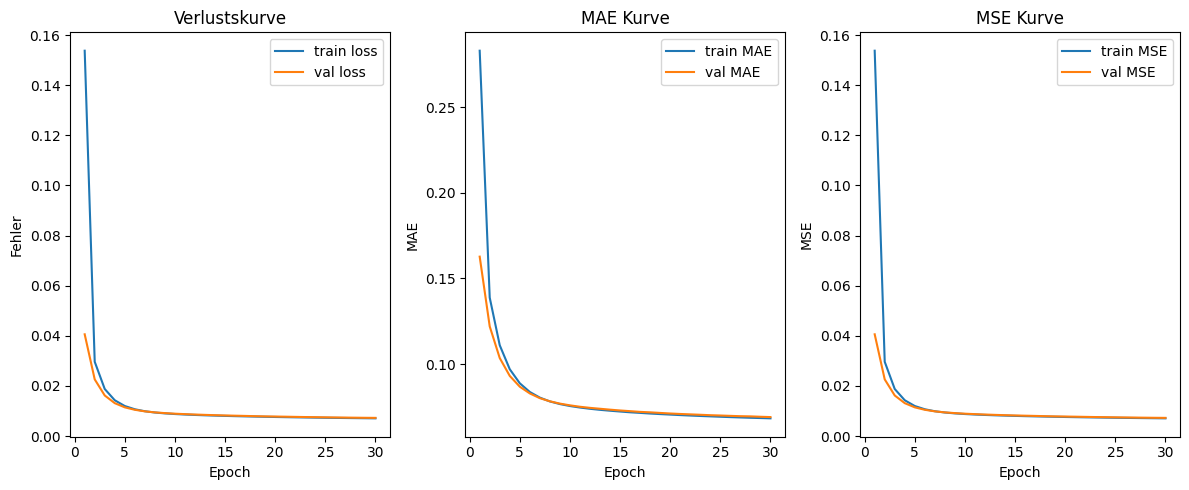

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


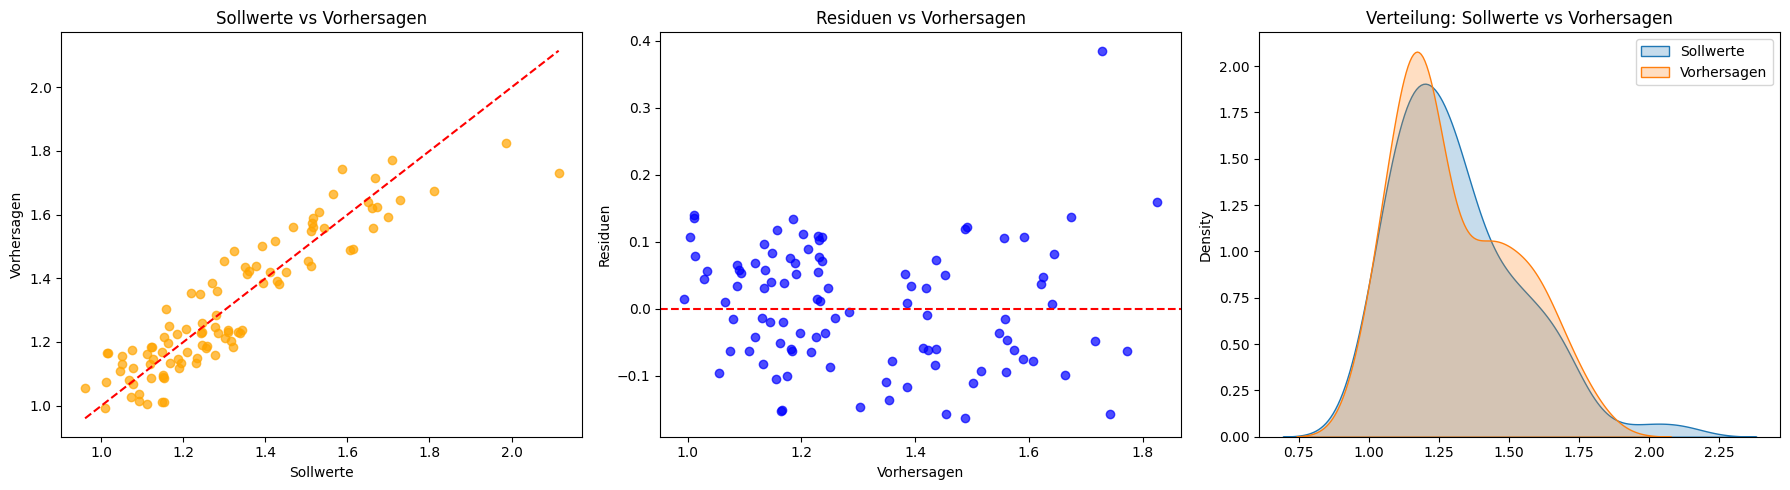

SGD_lr_0.01_mse_mm_0.9
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0853 - mae: 0.1502 - mse: 0.0853 - val_loss: 0.0079 - val_mae: 0.0728 - val_mse: 0.0079
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0071 - mae: 0.0691 - mse: 0.0071 - val_loss: 0.0069 - val_mae: 0.0682 - val_mse: 0.0069
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0066 - mae: 0.0667 - mse: 0.0066 - val_loss: 0.0066 - val_mae: 0.0667 - val_mse: 0.0066
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0064 - mae: 0.0658 - mse: 0.0064 - val_loss: 0.0065 - val_mae: 0.0661 - val_mse: 0.0065
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0062 - mae: 0.0652 - mse: 0.0062 - val_loss: 0.0063 - val_mae: 0.0655 - val_mse: 0.0063
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0061 - mae: 0.0646 - mse: 0.0061 - val_loss: 0.0062 - val_mae: 0.0649 - val_mse: 0.0062
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0060 - mae: 0.0

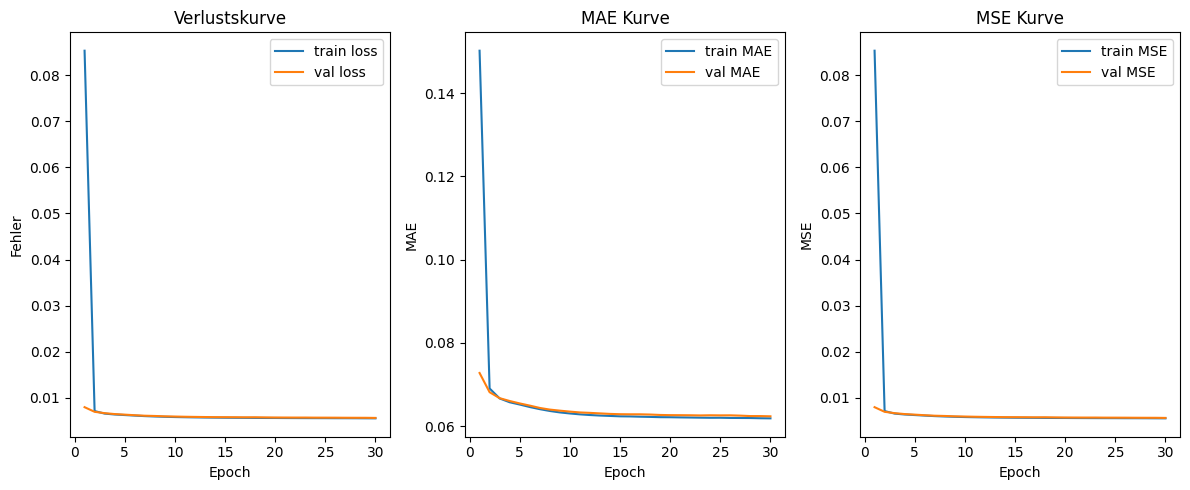

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


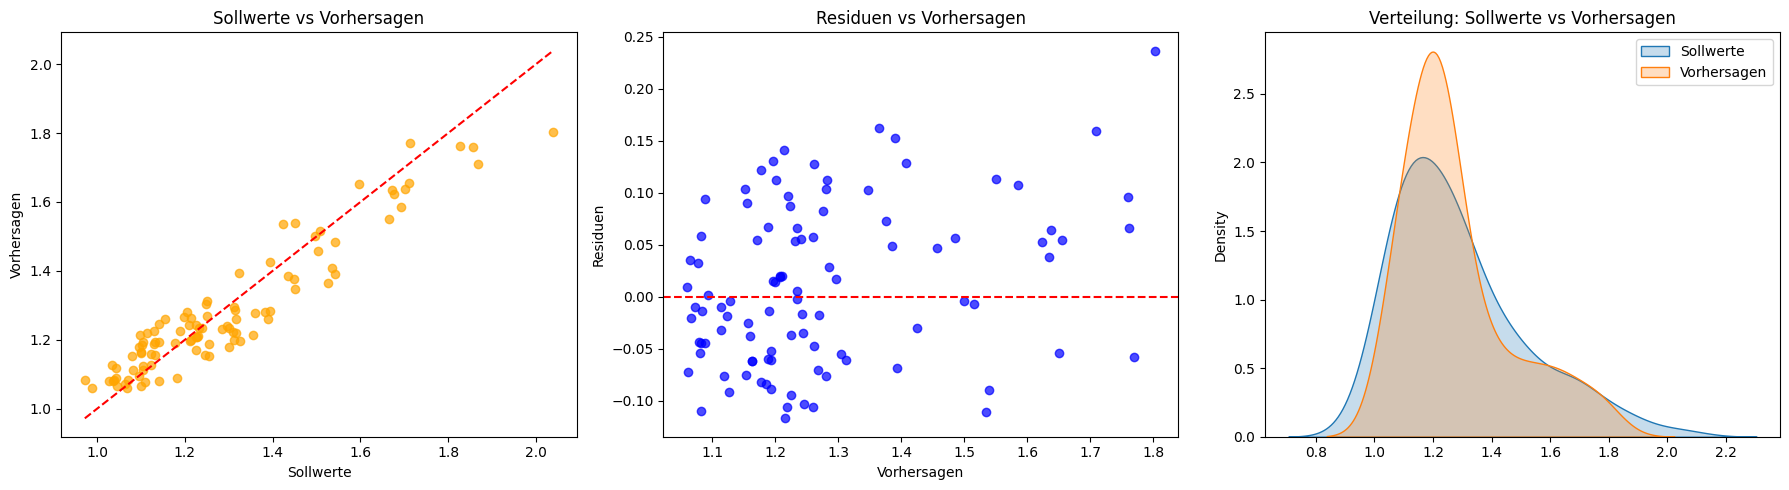

SGD_lr_0.001_mse_10
Epoch 1/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2128 - mae: 0.3144 - mse: 0.2128 - val_loss: 0.0412 - val_mae: 0.1619 - val_mse: 0.0412
Epoch 2/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0313 - mae: 0.1422 - mse: 0.0313 - val_loss: 0.0247 - val_mae: 0.1266 - val_mse: 0.0247
Epoch 3/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0209 - mae: 0.1167 - mse: 0.0209 - val_loss: 0.0182 - val_mae: 0.1088 - val_mse: 0.0182
Epoch 4/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0162 - mae: 0.1027 - mse: 0.0162 - val_loss: 0.0150 - val_mae: 0.0982 - val_mse: 0.0150
Epoch 5/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0138 - mae: 0.0944 - mse: 0.0138 - val_loss: 0.0131 - val_mae: 0.0916 - val_mse: 0.0131
Epoch 6/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0124 - mae: 0.0891 - mse: 0.0124 - val_loss: 0.0120 - val_mae: 0.0873 - val_mse: 0.0120
Epoch 7/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0114

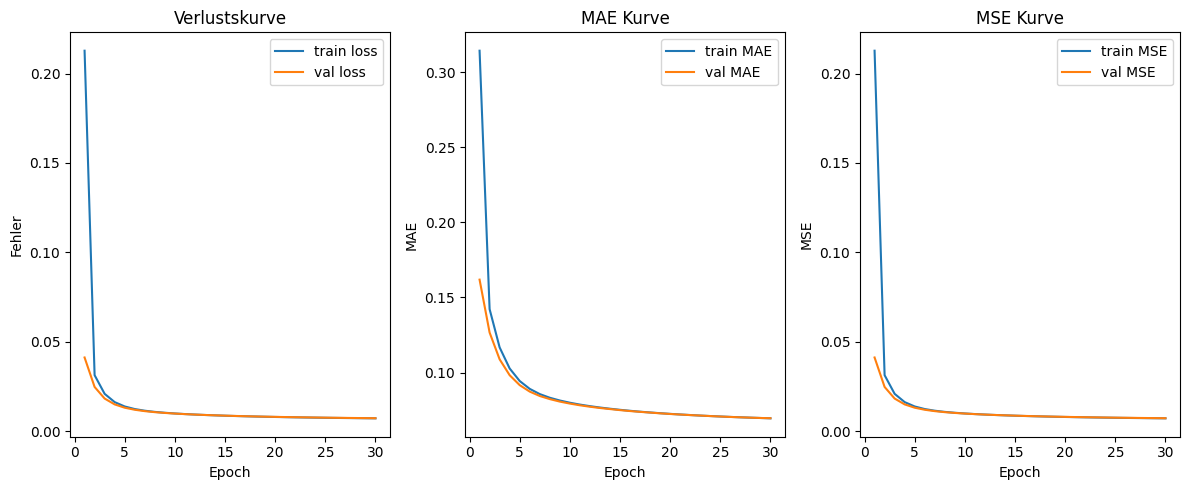

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


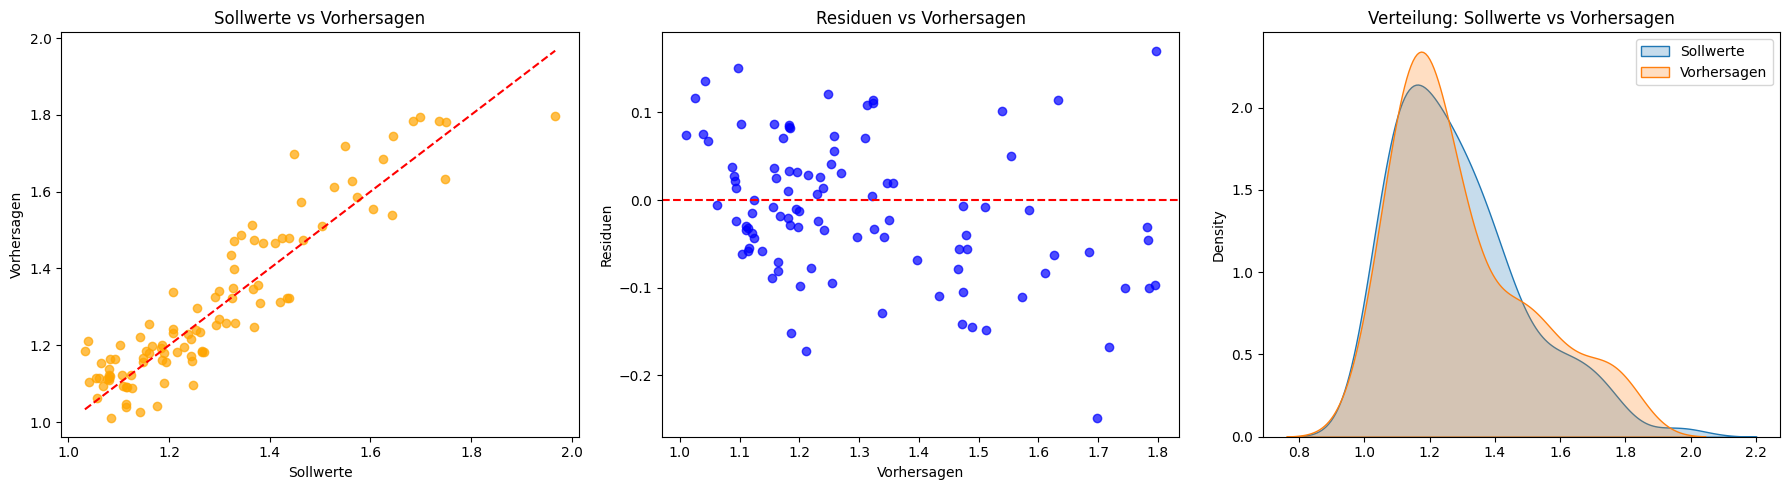

SGD_lr_0.01_mse_10
Epoch 1/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0204 - mae: 0.0898 - mse: 0.0204 - val_loss: 0.0063 - val_mae: 0.0651 - val_mse: 0.0063
Epoch 2/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0059 - mae: 0.0637 - mse: 0.0059 - val_loss: 0.0059 - val_mae: 0.0636 - val_mse: 0.0059
Epoch 3/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0057 - mae: 0.0629 - mse: 0.0057 - val_loss: 0.0058 - val_mae: 0.0633 - val_mse: 0.0058
Epoch 4/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0056 - mae: 0.0624 - mse: 0.0056 - val_loss: 0.0057 - val_mae: 0.0628 - val_mse: 0.0057
Epoch 5/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0056 - mae: 0.0622 - mse: 0.0056 - val_loss: 0.0057 - val_mae: 0.0628 - val_mse: 0.0057
Epoch 6/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0056 - mae: 0.0621 - mse: 0.0056 - val_loss: 0.0057 - val_mae: 0.0625 - val_mse: 0.0057
Epoch 7/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0055 

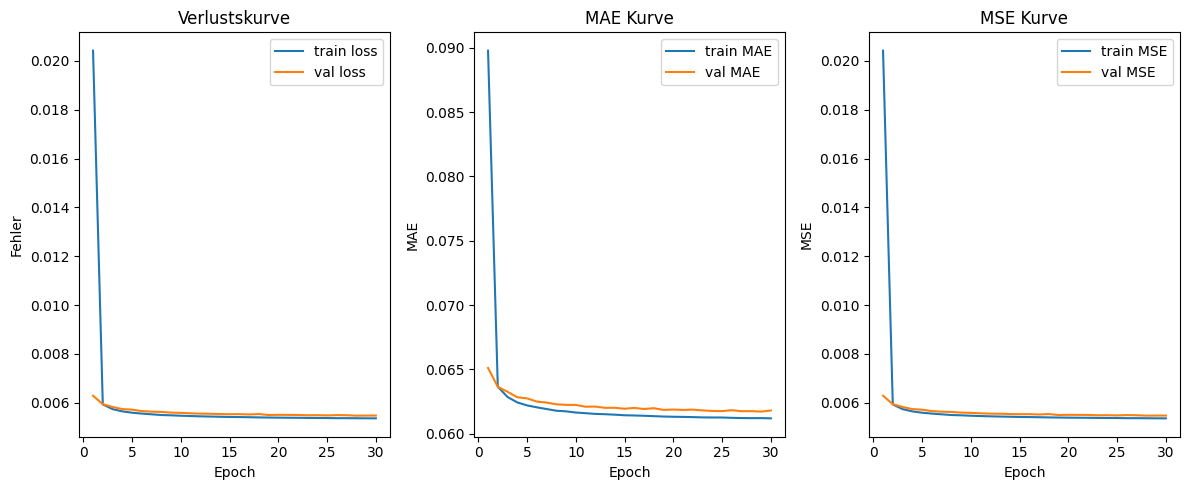

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


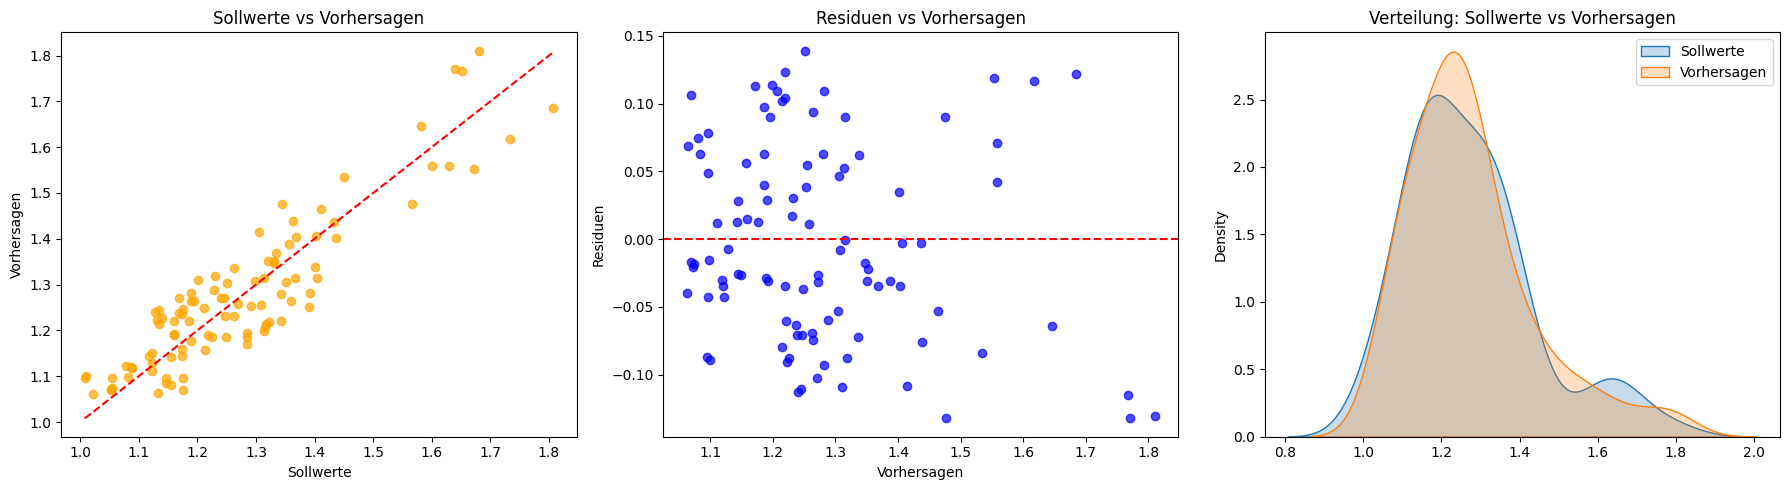

Adam_lr_0.1_mse_1
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0319 - mae: 0.1008 - mse: 0.0319 - val_loss: 0.0064 - val_mae: 0.0665 - val_mse: 0.0064
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0060 - mae: 0.0639 - mse: 0.0060 - val_loss: 0.0059 - val_mae: 0.0637 - val_mse: 0.0059
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0059 - mae: 0.0633 - mse: 0.0059 - val_loss: 0.0058 - val_mae: 0.0632 - val_mse: 0.0058
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0059 - mae: 0.0634 - mse: 0.0059 - val_loss: 0.0058 - val_mae: 0.0633 - val_mse: 0.0058
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0058 - mae: 0.0632 - mse: 0.0058 - val_loss: 0.0060 - val_mae: 0.0643 - val_mse: 0.0060
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0059 - mae: 0.0633 - mse: 0.0059 - val_loss: 0.0061 - val_mae: 0.0647 - val_mse: 0.0061
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0059 - mae: 0.0634 -

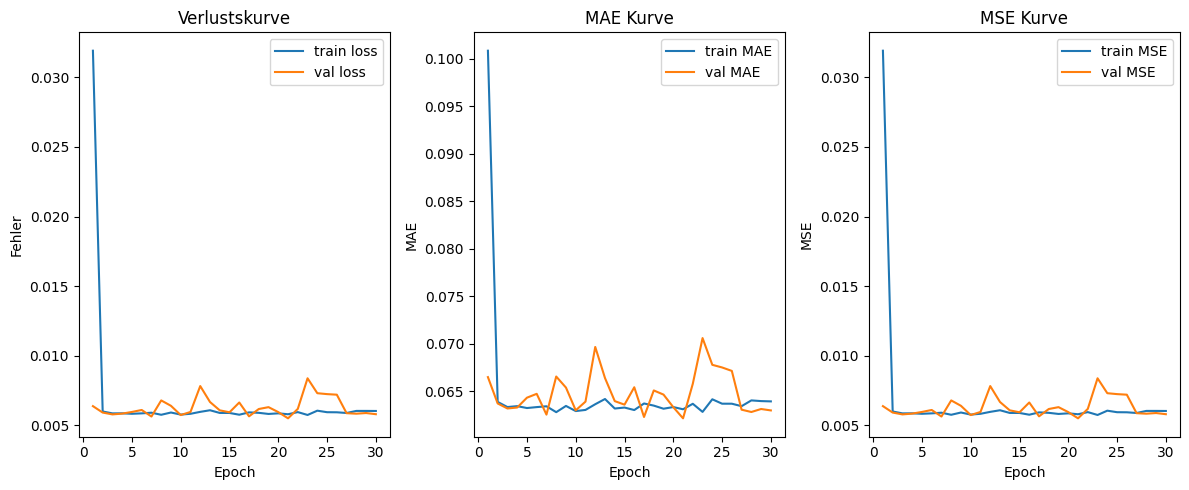

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 


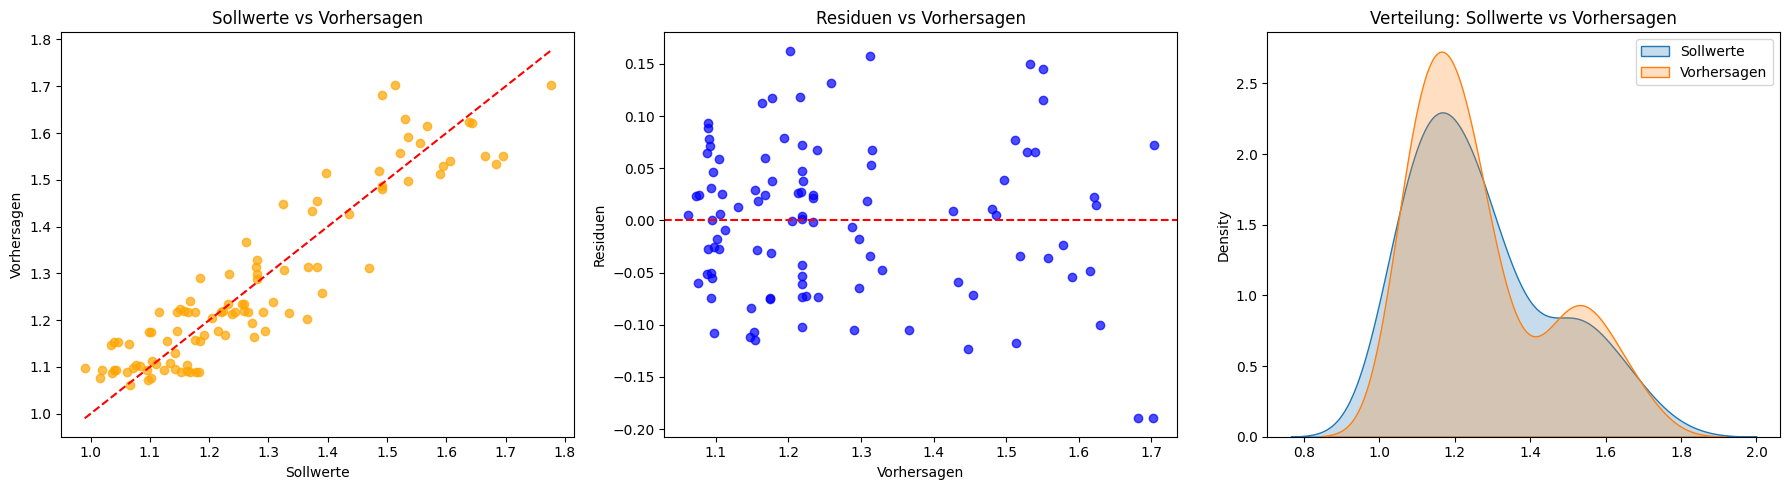

Adam_lr_0.001_mse_2
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4465 - mae: 0.5522 - mse: 0.4465 - val_loss: 0.1795 - val_mae: 0.3468 - val_mse: 0.1795
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1136 - mae: 0.2669 - mse: 0.1136 - val_loss: 0.0705 - val_mae: 0.2070 - val_mse: 0.0705
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0548 - mae: 0.1821 - mse: 0.0548 - val_loss: 0.0410 - val_mae: 0.1598 - val_mse: 0.0410
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0336 - mae: 0.1448 - mse: 0.0336 - val_loss: 0.0263 - val_mae: 0.1292 - val_mse: 0.0263
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0221 - mae: 0.1184 - mse: 0.0221 - val_loss: 0.0180 - val_mae: 0.1074 - val_mse: 0.0180
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0158 - mae: 0.1003 - mse: 0.0158 - val_loss: 0.0136 - val_mae: 0.0933 - val_mse: 0.0136
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0123 - mae: 0.0885

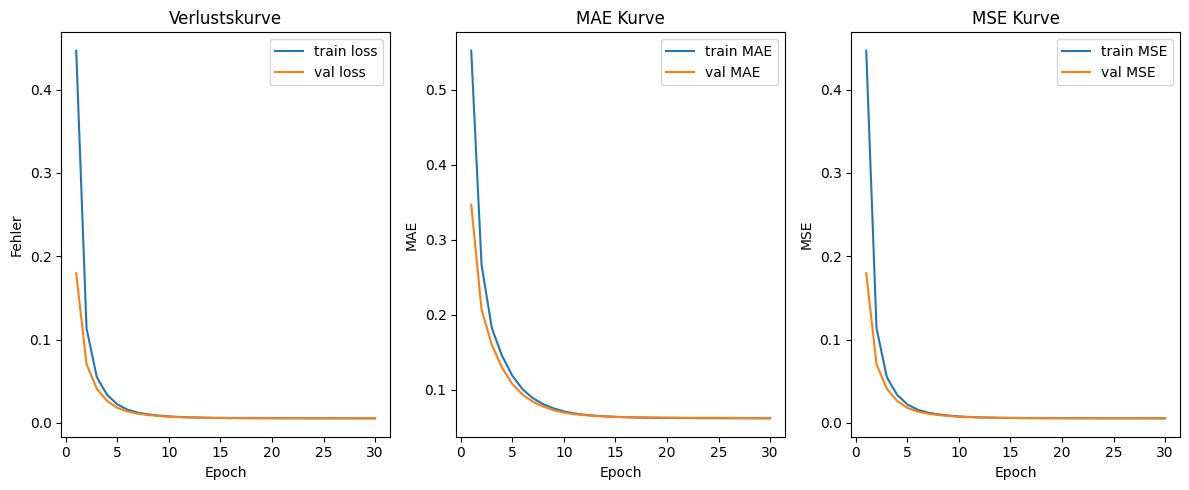

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 


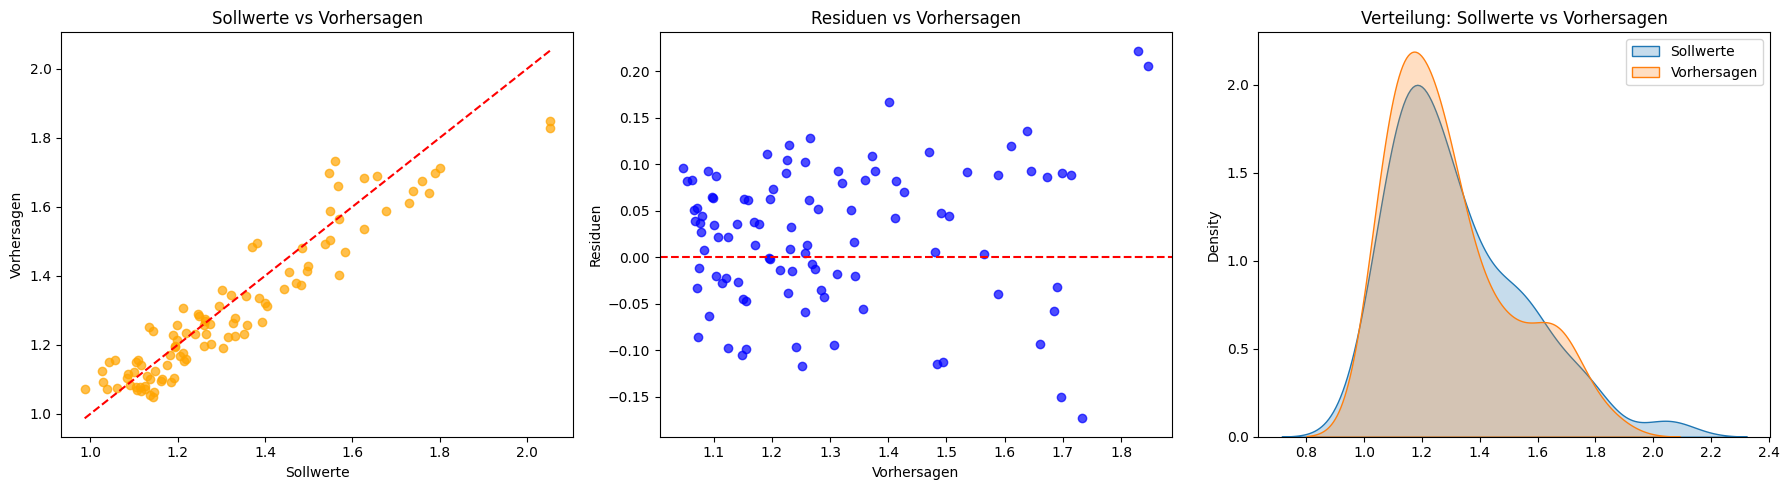

Adam_lr_0.01_mse_3
Epoch 1/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0209 - mae: 0.0796 - mse: 0.0209 - val_loss: 0.0059 - val_mae: 0.0636 - val_mse: 0.0059
Epoch 2/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0059 - mae: 0.0638 - mse: 0.0059 - val_loss: 0.0056 - val_mae: 0.0626 - val_mse: 0.0056
Epoch 3/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0058 - mae: 0.0630 - mse: 0.0058 - val_loss: 0.0056 - val_mae: 0.0623 - val_mse: 0.0056
Epoch 4/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0058 - mae: 0.0630 - mse: 0.0058 - val_loss: 0.0060 - val_mae: 0.0645 - val_mse: 0.0060
Epoch 5/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0056 - mae: 0.0623 - mse: 0.0056 - val_loss: 0.0056 - val_mae: 0.0626 - val_mse: 0.0056
Epoch 6/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0056 - mae: 0.0621 - mse: 0.0056 - val_loss: 0.0055 - val_mae: 0.0620 - val_mse: 0.0055
Epoch 7/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0056

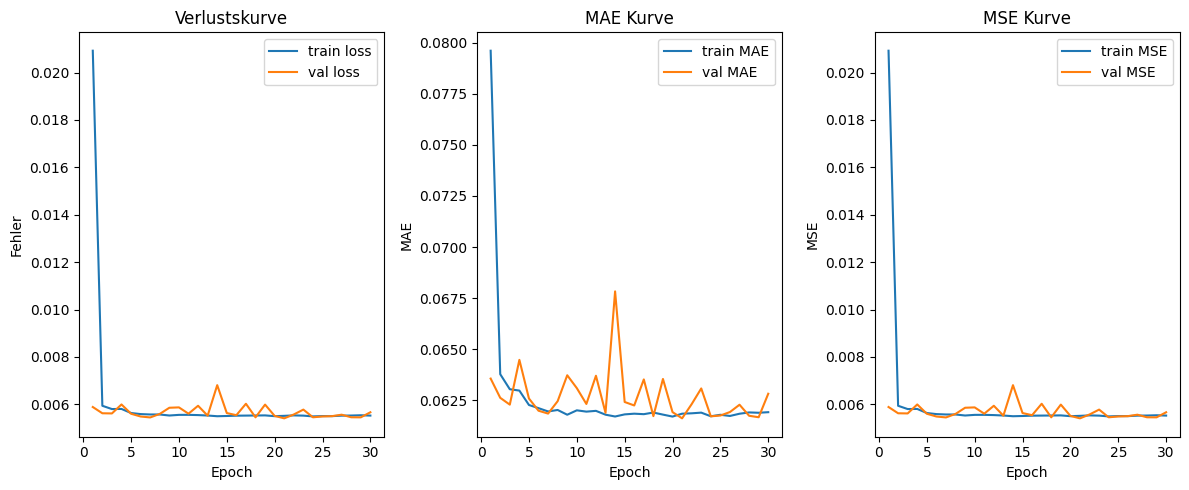

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


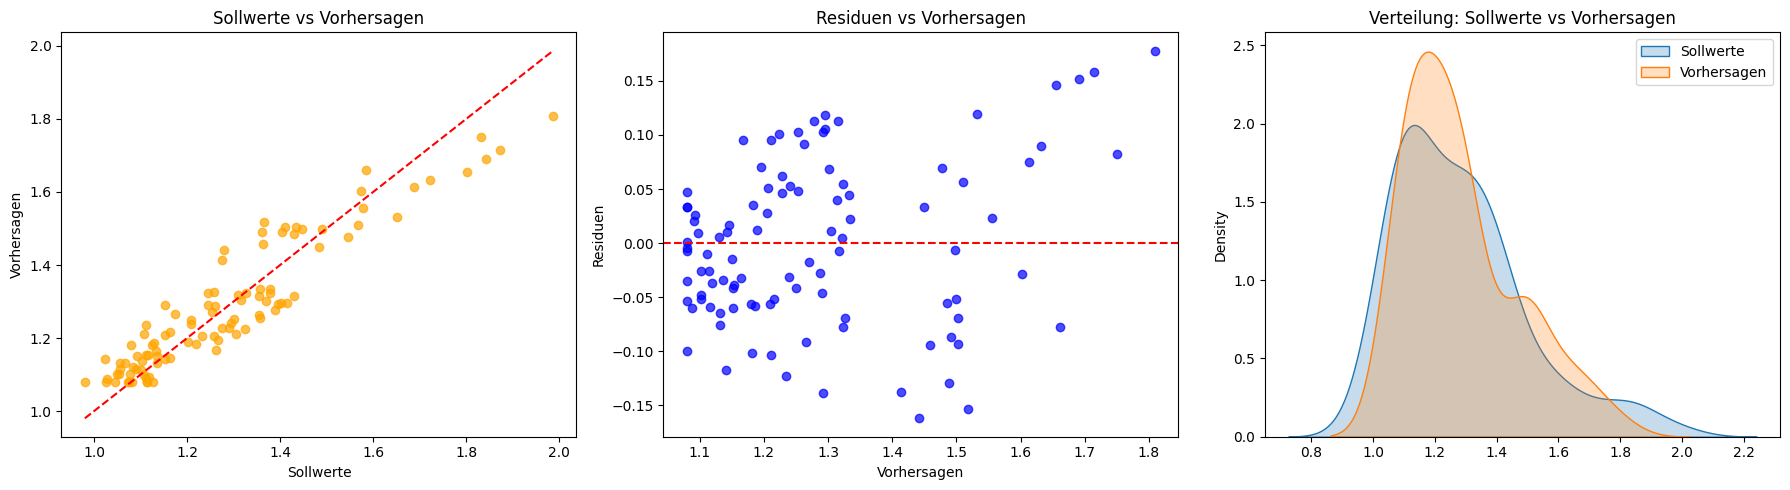

RMSprop_lr_0.01_mse_1
Epoch 1/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0187 - mae: 0.0815 - mse: 0.0187 - val_loss: 0.0084 - val_mae: 0.0733 - val_mse: 0.0084
Epoch 2/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 0.0064 - mae: 0.0654 - mse: 0.0064 - val_loss: 0.0063 - val_mae: 0.0647 - val_mse: 0.0063
Epoch 3/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0061 - mae: 0.0641 - mse: 0.0061 - val_loss: 0.0058 - val_mae: 0.0632 - val_mse: 0.0058
Epoch 4/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 0.0059 - mae: 0.0635 - mse: 0.0059 - val_loss: 0.0058 - val_mae: 0.0627 - val_mse: 0.0058
Epoch 5/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0057 - mae: 0.0627 - mse: 0.0057 - val_loss: 0.0056 - val_mae: 0.0626 - val_mse: 0.0056
Epoch 6/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0057 - mae: 0.0626 - mse: 0.0057 - val_loss: 0.0058 - val_mae: 0.0628 - val_mse: 0.0058
Epoch 7/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 

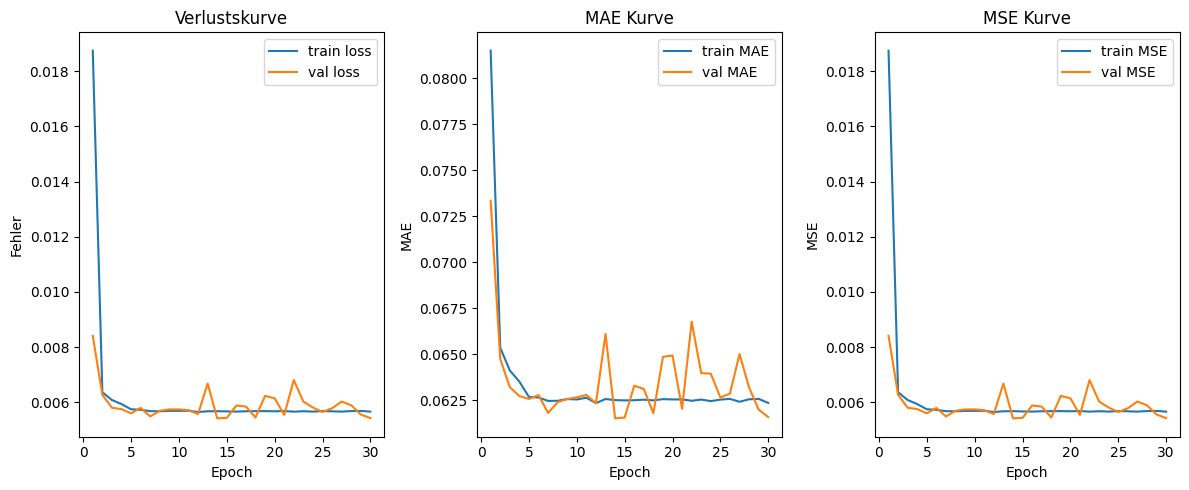

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


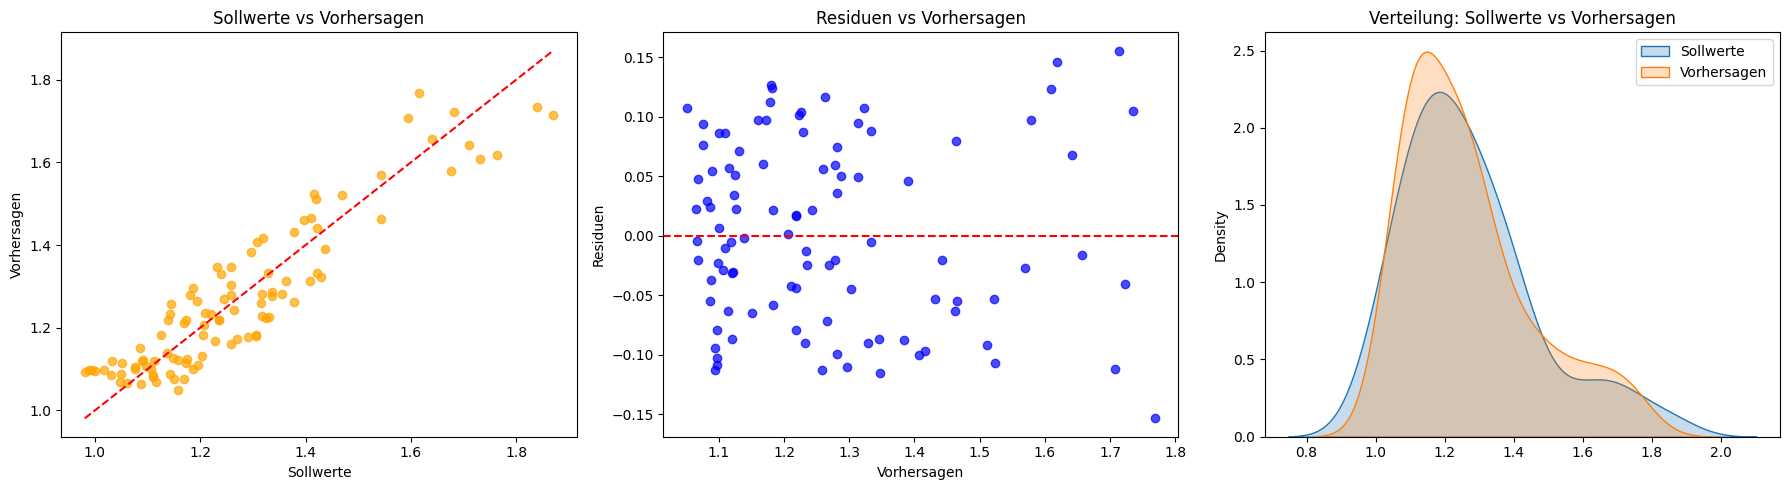

RMSprop_lr_0.001_mse_2
Epoch 1/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0270 - mae: 0.0954 - mse: 0.0270 - val_loss: 0.0060 - val_mae: 0.0640 - val_mse: 0.0060
Epoch 2/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0056 - mae: 0.0624 - mse: 0.0056 - val_loss: 0.0060 - val_mae: 0.0642 - val_mse: 0.0060
Epoch 3/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0056 - mae: 0.0621 - mse: 0.0056 - val_loss: 0.0055 - val_mae: 0.0619 - val_mse: 0.0055
Epoch 4/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0055 - mae: 0.0620 - mse: 0.0055 - val_loss: 0.0058 - val_mae: 0.0631 - val_mse: 0.0058
Epoch 5/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0055 - mae: 0.0619 - mse: 0.0055 - val_loss: 0.0055 - val_mae: 0.0619 - val_mse: 0.0055
Epoch 6/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0055 - mae: 0.0619 - mse: 0.0055 - val_loss: 0.0056 - val_mae: 0.0622 - val_mse: 0.0056
Epoch 7/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0

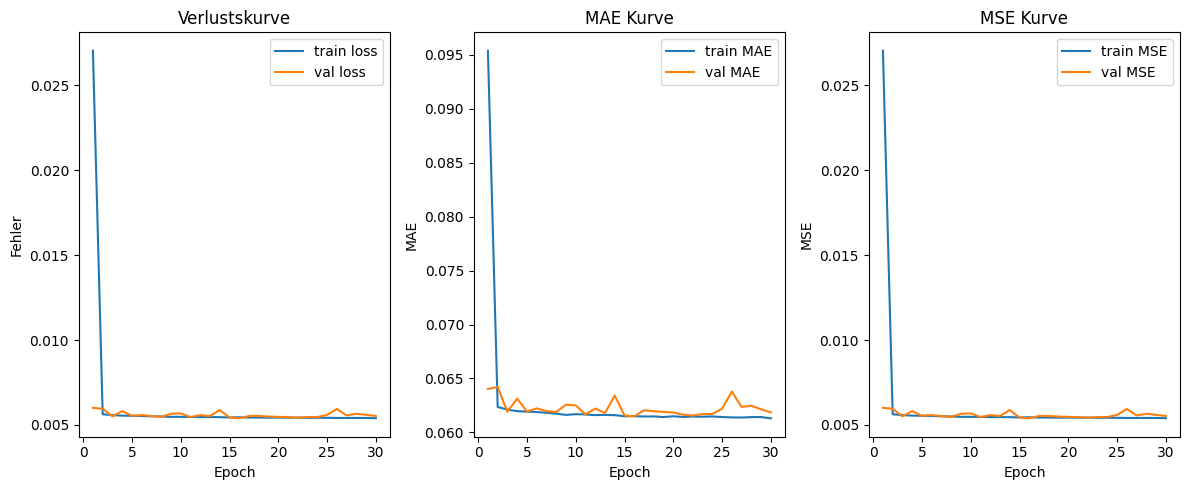

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


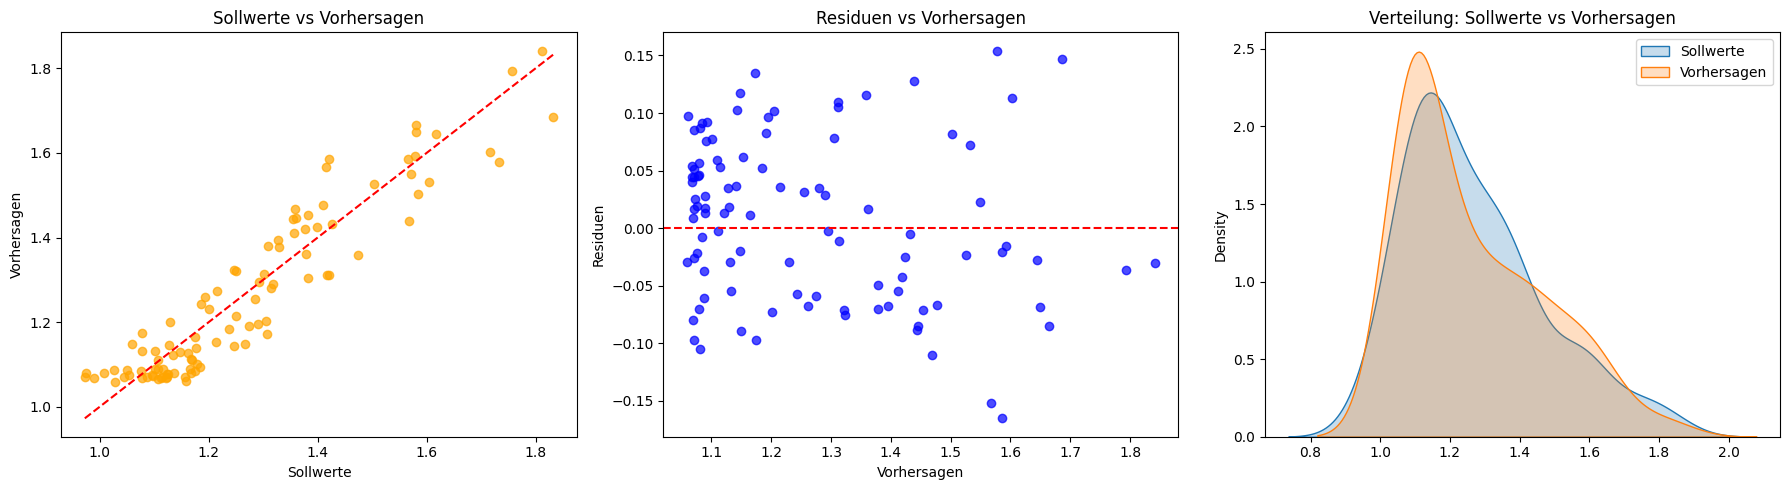

RMSprop_lr_0.01_mse_3
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0276 - mae: 0.1180 - mse: 0.0276 - val_loss: 0.0201 - val_mae: 0.1183 - val_mse: 0.0201
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0112 - mae: 0.0851 - mse: 0.0112 - val_loss: 0.0191 - val_mae: 0.1113 - val_mse: 0.0191
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0088 - mae: 0.0757 - mse: 0.0088 - val_loss: 0.0082 - val_mae: 0.0711 - val_mse: 0.0082
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0080 - mae: 0.0725 - mse: 0.0080 - val_loss: 0.0086 - val_mae: 0.0746 - val_mse: 0.0086
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0074 - mae: 0.0697 - mse: 0.0074 - val_loss: 0.0116 - val_mae: 0.0887 - val_mse: 0.0116
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0072 - mae: 0.0687 - mse: 0.0072 - val_loss: 0.0091 - val_mae: 0.0783 - val_mse: 0.0091
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0068 - mae: 0.06

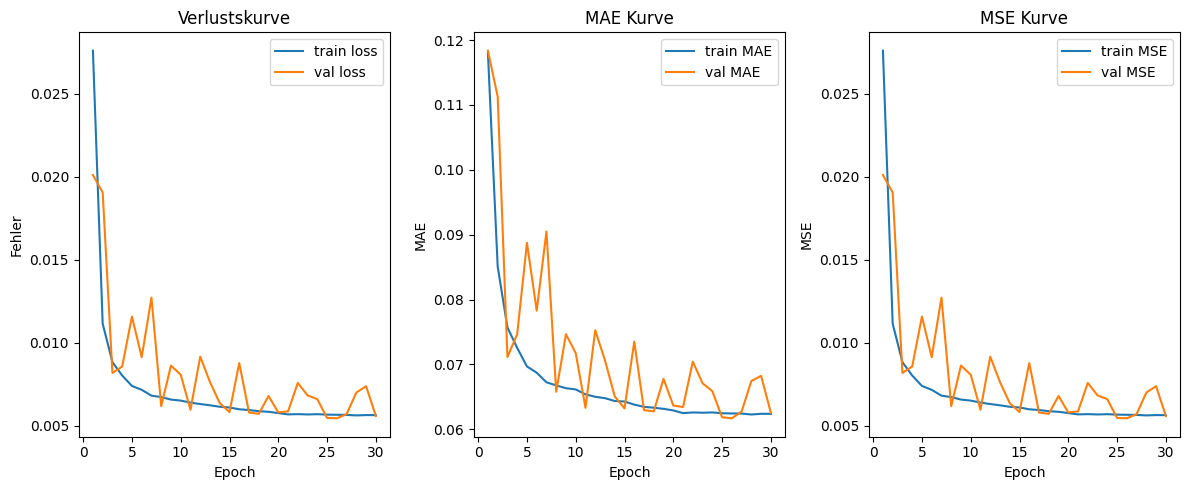

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


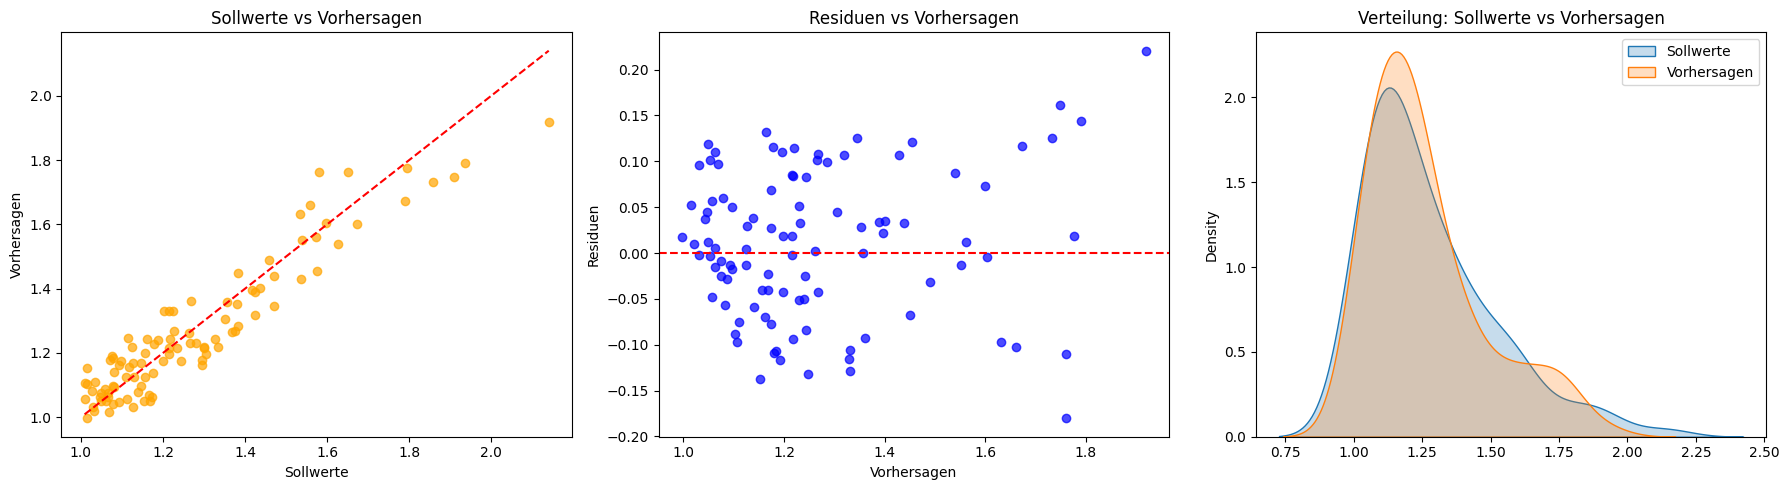

In [60]:
# Neuronale Netze mit einer einzigen versteckten Schicht aufstellen
models = [
    # sgd
    KerasModel(
        name="SGD_lr_0.01_mse_1",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="SGD_lr_0.01_mse_mm_0.9",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="SGD_lr_0.001_mse_10",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
        loss_function="mse",
        epochs=30,
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="SGD_lr_0.01_mse_10",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        loss_function="mse",
        epochs=30,
        batch_size=None,
        layers=[
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    # sehr gutes Modell, flunktuierende Verlustkurve,
    KerasModel(
        name="Adam_lr_0.1_mse_1",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="Adam_lr_0.001_mse_2",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="Adam_lr_0.01_mse_3",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        epochs=30,
        batch_size=None,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="RMSprop_lr_0.01_mse_1",
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.01),
        epochs=30,
        batch_size=None,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="RMSprop_lr_0.001_mse_2",
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
        epochs=30,
        batch_size=32,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="RMSprop_lr_0.01_mse_3",
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.01),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
]
train_neuronal_nets(models)

SGD_l4_lr_0.01_mse_1
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0953 - mae: 0.1788 - mse: 0.0953 - val_loss: 0.0109 - val_mae: 0.0853 - val_mse: 0.0109
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0092 - mae: 0.0778 - mse: 0.0092 - val_loss: 0.0084 - val_mae: 0.0743 - val_mse: 0.0084
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0077 - mae: 0.0713 - mse: 0.0077 - val_loss: 0.0074 - val_mae: 0.0704 - val_mse: 0.0074
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0070 - mae: 0.0684 - mse: 0.0070 - val_loss: 0.0069 - val_mae: 0.0683 - val_mse: 0.0069
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0066 - mae: 0.0668 - mse: 0.0066 - val_loss: 0.0066 - val_mae: 0.0669 - val_mse: 0.0066
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0064 - mae: 0.0656 - mse: 0.0064 - val_loss: 0.0064 - val_mae: 0.0662 - val_mse: 0.0064
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0062 - mae: 0.064

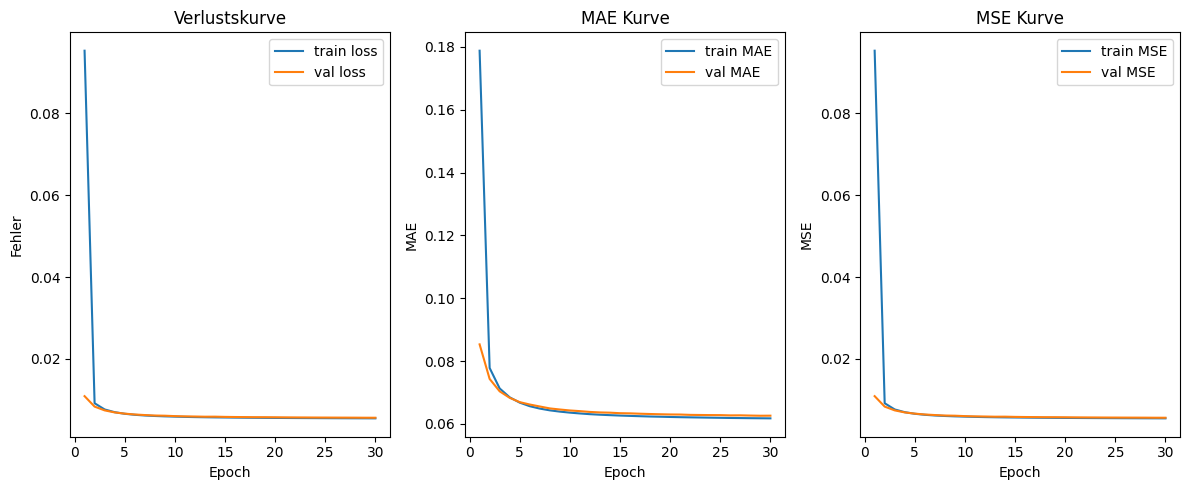

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


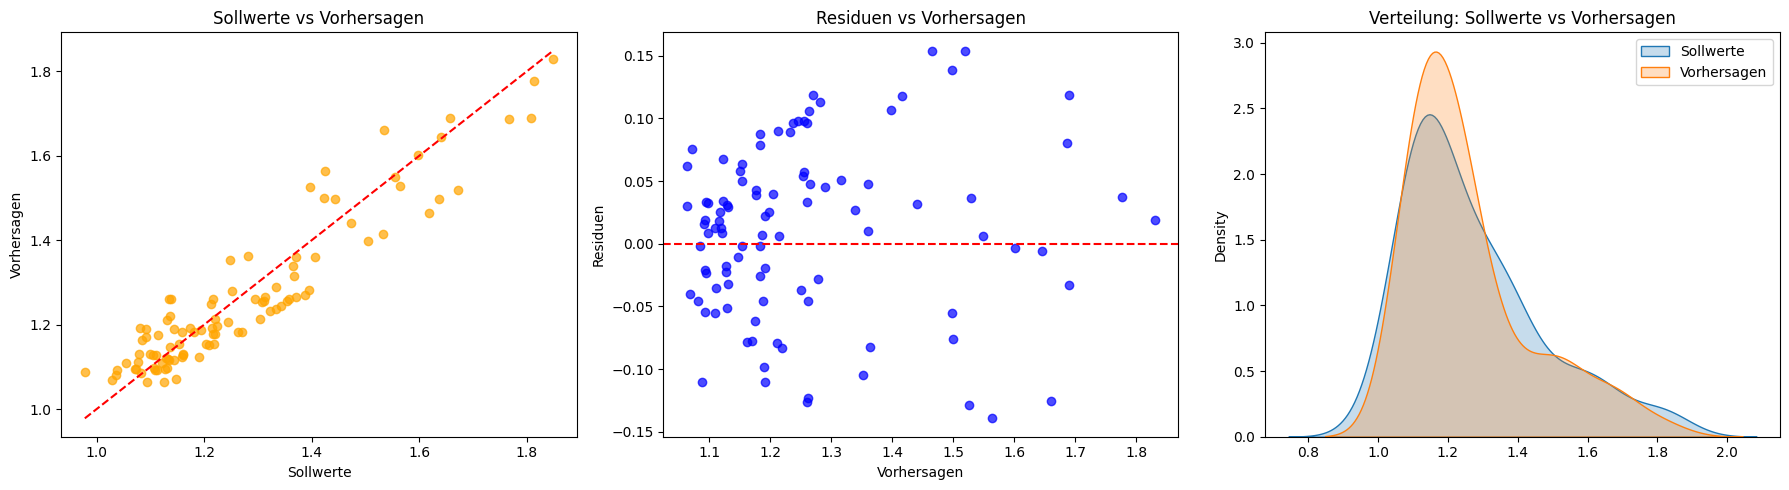

SGD_l4_lr_0.01_mse_mm_0.9
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1032 - mae: 0.2213 - mse: 0.1032 - val_loss: 0.0437 - val_mae: 0.1657 - val_mse: 0.0437
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0427 - mae: 0.1653 - mse: 0.0427 - val_loss: 0.0436 - val_mae: 0.1664 - val_mse: 0.0436
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0427 - mae: 0.1653 - mse: 0.0427 - val_loss: 0.0436 - val_mae: 0.1673 - val_mse: 0.0436
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0427 - mae: 0.1654 - mse: 0.0427 - val_loss: 0.0436 - val_mae: 0.1659 - val_mse: 0.0436
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0426 - mae: 0.1653 - mse: 0.0426 - val_loss: 0.0436 - val_mae: 0.1675 - val_mse: 0.0436
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0427 - mae: 0.1653 - mse: 0.0427 - val_loss: 0.0436 - val_mae: 0.1680 - val_mse: 0.0436
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0427 - mae: 

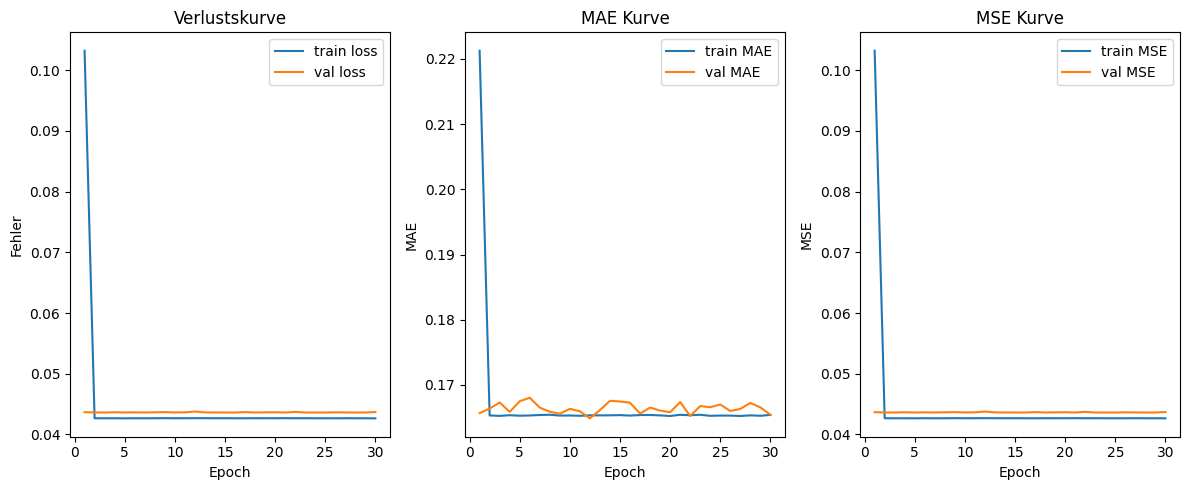

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


C:\Users\harro\AppData\Local\Temp\ipykernel_23820\2702515471.py:248: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(Y_pred, ax=axes[2], label="Vorhersagen", fill=True)


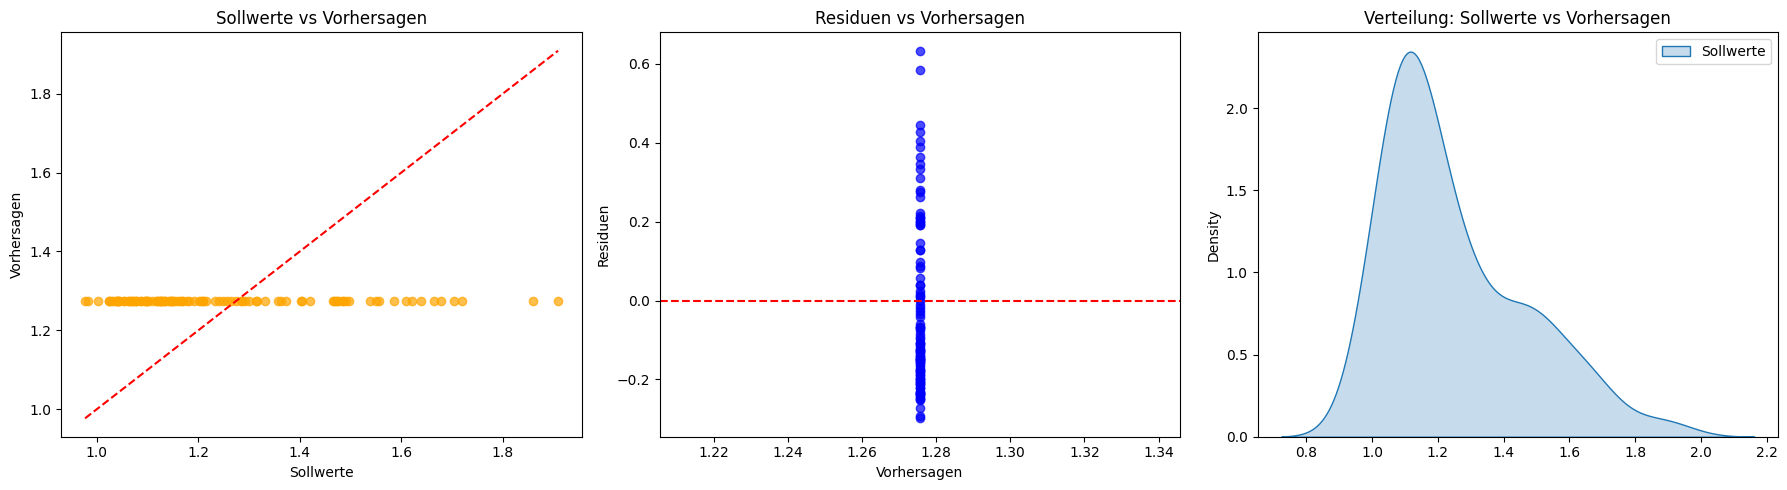

SGD_l4_lr_0.001_mse_10
Epoch 1/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.1073 - mae: 0.2198 - mse: 0.1073 - val_loss: 0.0162 - val_mae: 0.1037 - val_mse: 0.0162
Epoch 2/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0125 - mae: 0.0908 - mse: 0.0125 - val_loss: 0.0105 - val_mae: 0.0839 - val_mse: 0.0105
Epoch 3/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0094 - mae: 0.0790 - mse: 0.0094 - val_loss: 0.0087 - val_mae: 0.0766 - val_mse: 0.0087
Epoch 4/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0081 - mae: 0.0736 - mse: 0.0081 - val_loss: 0.0078 - val_mae: 0.0727 - val_mse: 0.0078
Epoch 5/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0074 - mae: 0.0705 - mse: 0.0074 - val_loss: 0.0073 - val_mae: 0.0702 - val_mse: 0.0073
Epoch 6/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0069 - mae: 0.0685 - mse: 0.0069 - val_loss: 0.0069 - val_mae: 0.0685 - val_mse: 0.0069
Epoch 7/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0

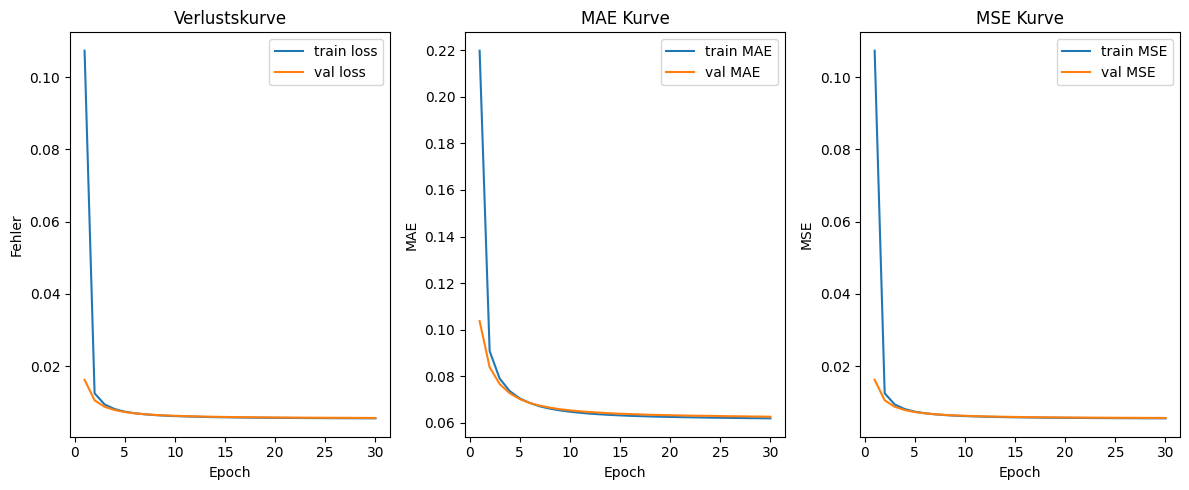

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


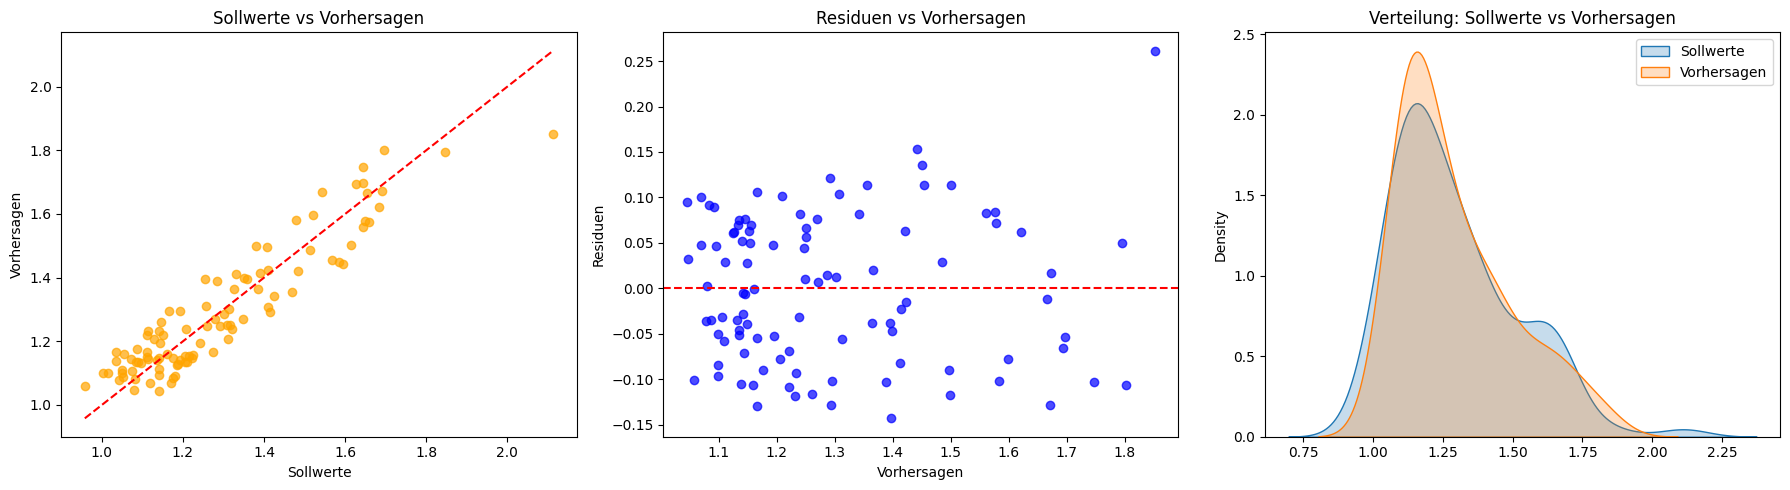

SGD_l4_lr_0.01_mse_10
Epoch 1/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0251 - mae: 0.0937 - mse: 0.0251 - val_loss: 0.0062 - val_mae: 0.0651 - val_mse: 0.0062
Epoch 2/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0058 - mae: 0.0633 - mse: 0.0058 - val_loss: 0.0058 - val_mae: 0.0631 - val_mse: 0.0058
Epoch 3/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0056 - mae: 0.0621 - mse: 0.0056 - val_loss: 0.0056 - val_mae: 0.0623 - val_mse: 0.0056
Epoch 4/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0055 - mae: 0.0617 - mse: 0.0055 - val_loss: 0.0056 - val_mae: 0.0621 - val_mse: 0.0056
Epoch 5/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0054 - mae: 0.0615 - mse: 0.0054 - val_loss: 0.0055 - val_mae: 0.0619 - val_mse: 0.0055
Epoch 6/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0054 - mae: 0.0614 - mse: 0.0054 - val_loss: 0.0055 - val_mae: 0.0618 - val_mse: 0.0055
Epoch 7/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.00

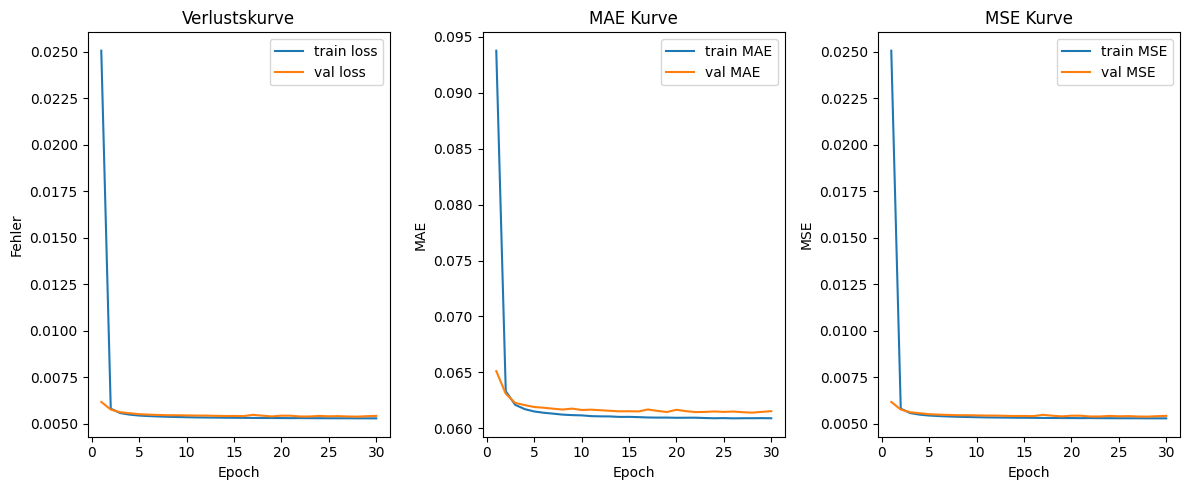

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


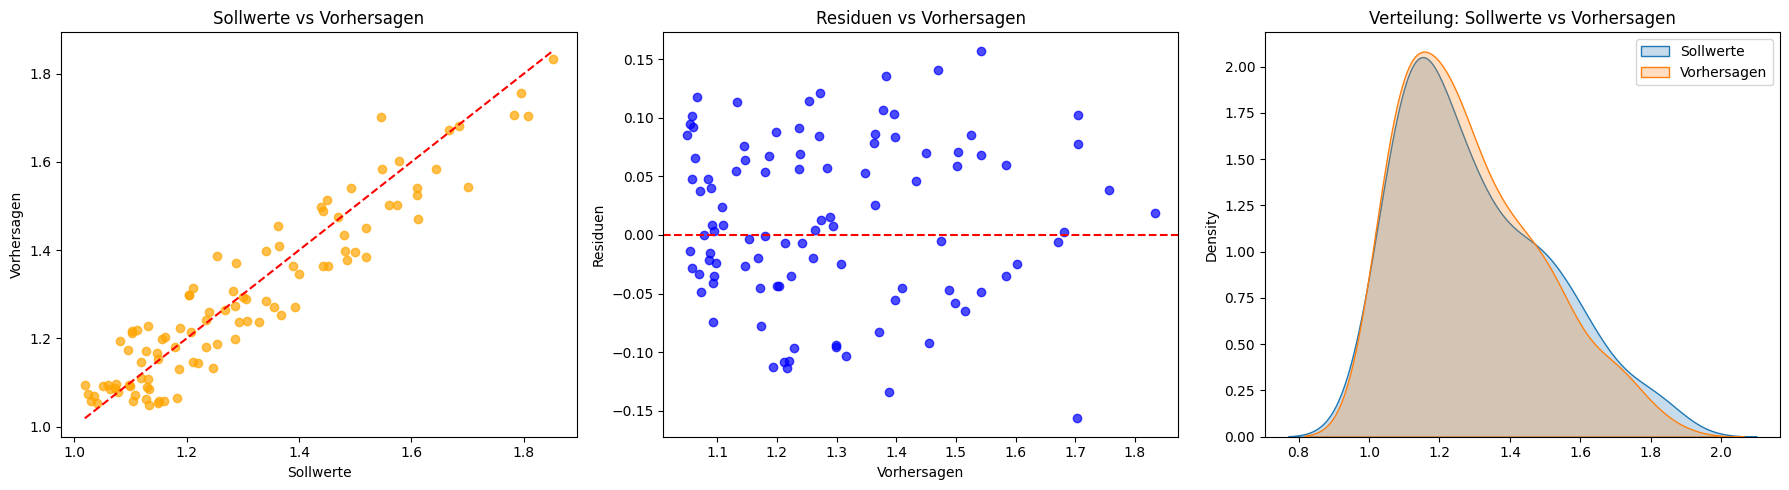

Adam_l4_lr_0.1_mse_1
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0931 - mae: 0.1214 - mse: 0.0931 - val_loss: 0.0057 - val_mae: 0.0625 - val_mse: 0.0057
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0055 - mae: 0.0618 - mse: 0.0055 - val_loss: 0.0055 - val_mae: 0.0619 - val_mse: 0.0055
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - mae: 0.0621 - mse: 0.0056 - val_loss: 0.0057 - val_mae: 0.0627 - val_mse: 0.0057
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - mae: 0.0622 - mse: 0.0056 - val_loss: 0.0055 - val_mae: 0.0618 - val_mse: 0.0055
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - mae: 0.0621 - mse: 0.0056 - val_loss: 0.0058 - val_mae: 0.0632 - val_mse: 0.0058
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0057 - mae: 0.0624 - mse: 0.0057 - val_loss: 0.0056 - val_mae: 0.0621 - val_mse: 0.0056
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0058 - mae: 0.063

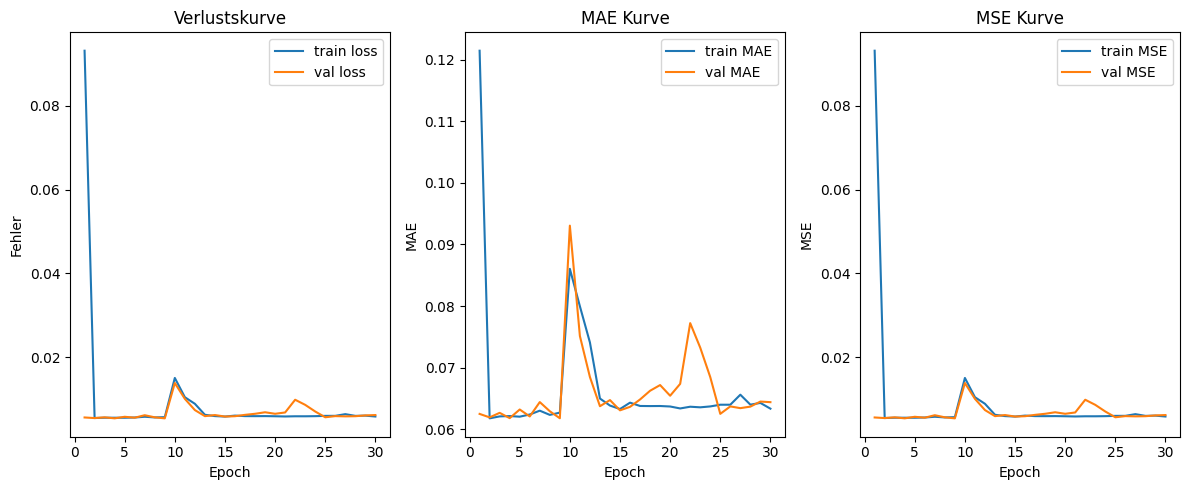

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


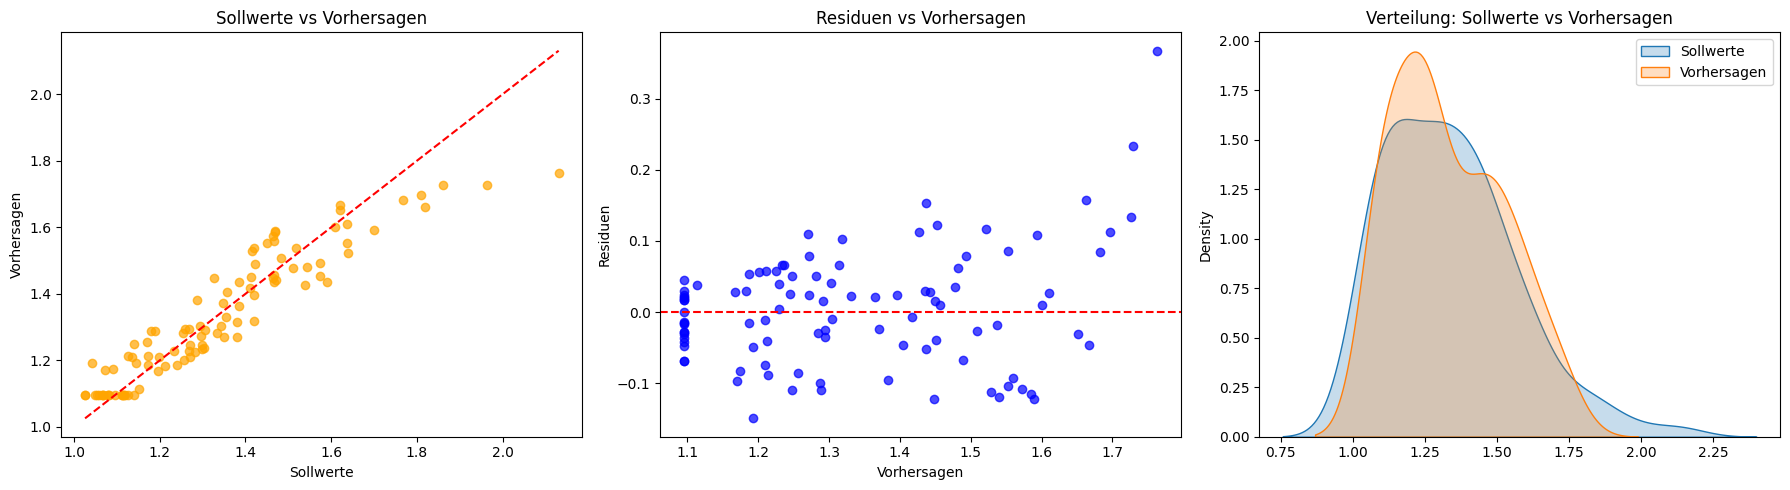

Adam_l4_lr_0.001_mse_2
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1378 - mae: 0.2265 - mse: 0.1378 - val_loss: 0.0079 - val_mae: 0.0727 - val_mse: 0.0079
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0061 - mae: 0.0646 - mse: 0.0061 - val_loss: 0.0057 - val_mae: 0.0627 - val_mse: 0.0057
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - mae: 0.0621 - mse: 0.0056 - val_loss: 0.0056 - val_mae: 0.0622 - val_mse: 0.0056
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0055 - mae: 0.0616 - mse: 0.0055 - val_loss: 0.0055 - val_mae: 0.0620 - val_mse: 0.0055
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - mae: 0.0614 - mse: 0.0054 - val_loss: 0.0055 - val_mae: 0.0620 - val_mse: 0.0055
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - mae: 0.0614 - mse: 0.0054 - val_loss: 0.0055 - val_mae: 0.0617 - val_mse: 0.0055
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - mae: 0.0

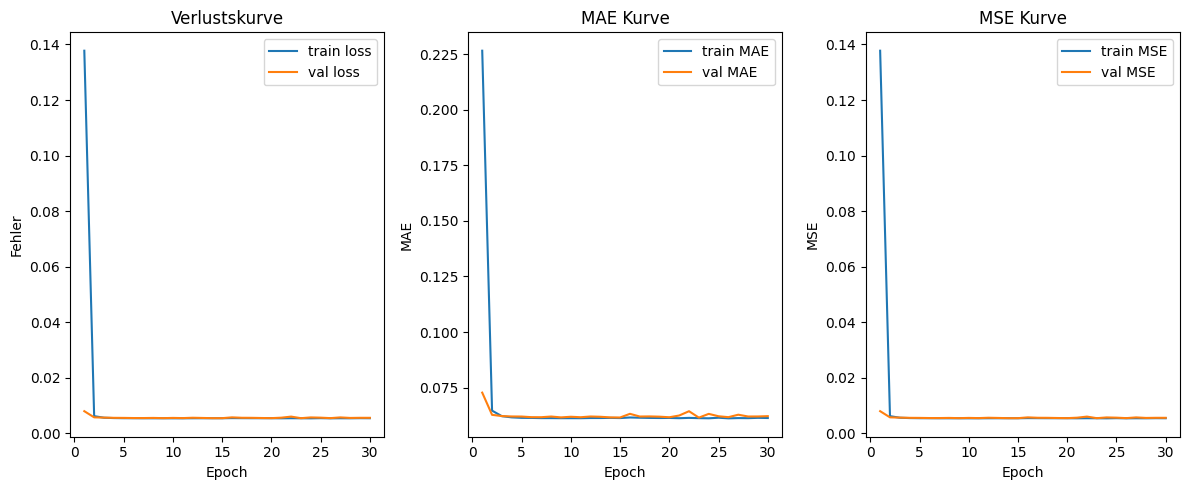

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


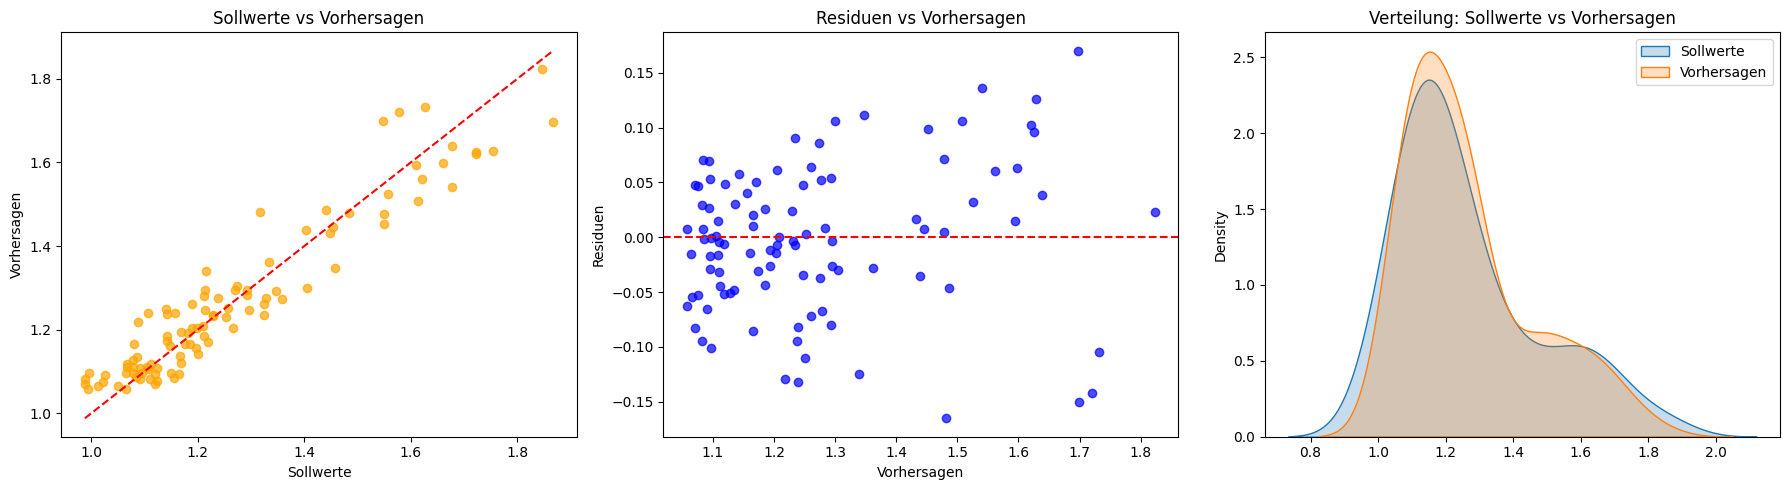

Adam_l4_lr_0.01_mse_3
Epoch 1/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0156 - mae: 0.0738 - mse: 0.0156 - val_loss: 0.0062 - val_mae: 0.0644 - val_mse: 0.0062
Epoch 2/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0059 - mae: 0.0634 - mse: 0.0059 - val_loss: 0.0055 - val_mae: 0.0620 - val_mse: 0.0055
Epoch 3/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0059 - mae: 0.0634 - mse: 0.0059 - val_loss: 0.0058 - val_mae: 0.0635 - val_mse: 0.0058
Epoch 4/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0058 - mae: 0.0629 - mse: 0.0058 - val_loss: 0.0061 - val_mae: 0.0648 - val_mse: 0.0061
Epoch 5/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0057 - mae: 0.0626 - mse: 0.0057 - val_loss: 0.0056 - val_mae: 0.0628 - val_mse: 0.0056
Epoch 6/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0057 - mae: 0.0626 - mse: 0.0057 - val_loss: 0.0064 - val_mae: 0.0647 - val_mse: 0.0064
Epoch 7/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0

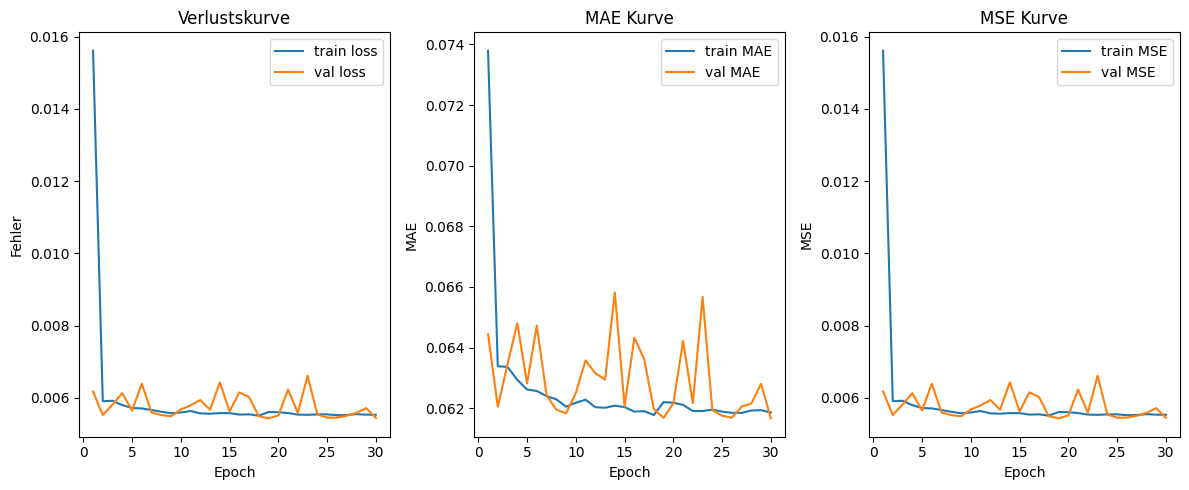

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


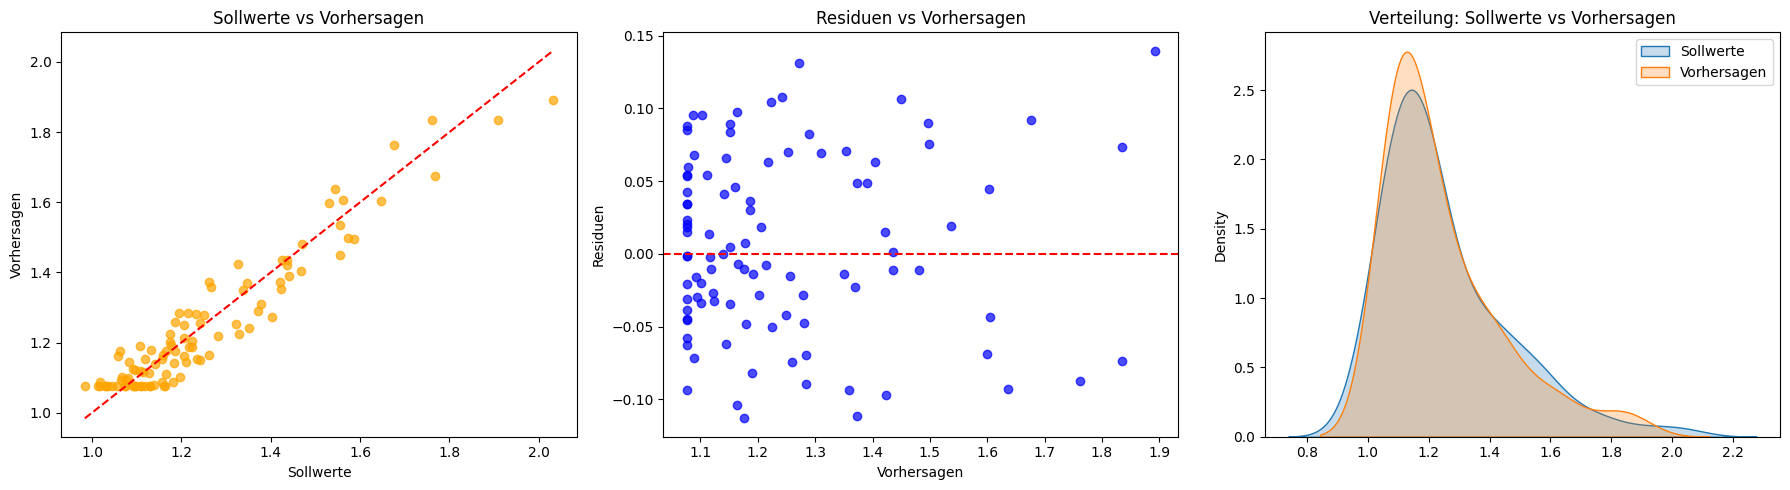

RMSprop_l4_lr_0.01_mse_1
Epoch 1/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0138 - mae: 0.0826 - mse: 0.0138 - val_loss: 0.0059 - val_mae: 0.0633 - val_mse: 0.0059
Epoch 2/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0064 - mae: 0.0652 - mse: 0.0064 - val_loss: 0.0081 - val_mae: 0.0730 - val_mse: 0.0081
Epoch 3/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0061 - mae: 0.0642 - mse: 0.0061 - val_loss: 0.0071 - val_mae: 0.0674 - val_mse: 0.0071
Epoch 4/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0059 - mae: 0.0635 - mse: 0.0059 - val_loss: 0.0055 - val_mae: 0.0619 - val_mse: 0.0055
Epoch 5/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0059 - mae: 0.0632 - mse: 0.0059 - val_loss: 0.0058 - val_mae: 0.0629 - val_mse: 0.0058
Epoch 6/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0058 - mae: 0.0628 - mse: 0.0058 - val_loss: 0.0055 - val_mae: 0.0619 - val_mse: 0.0055
Epoch 7/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0

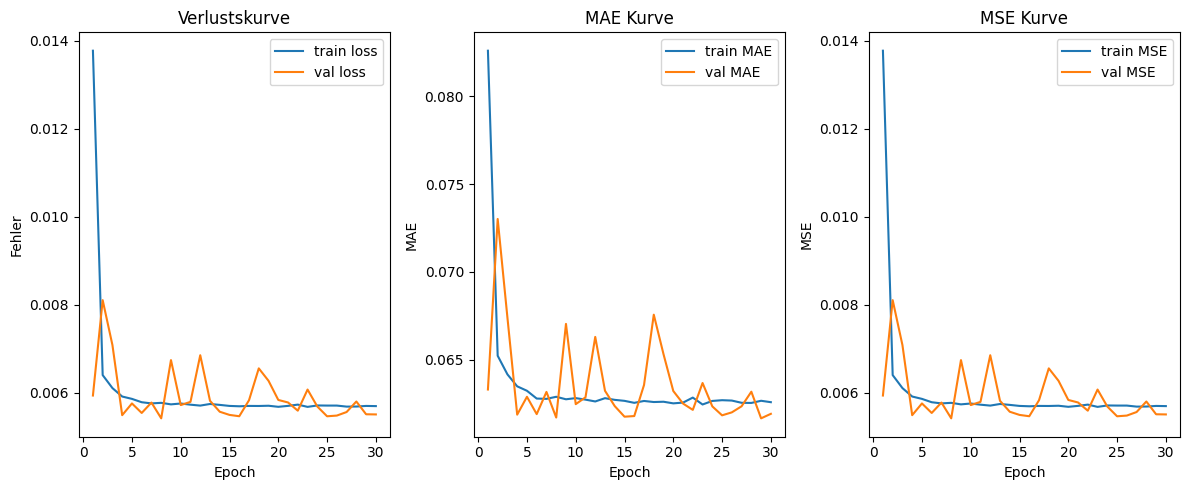

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


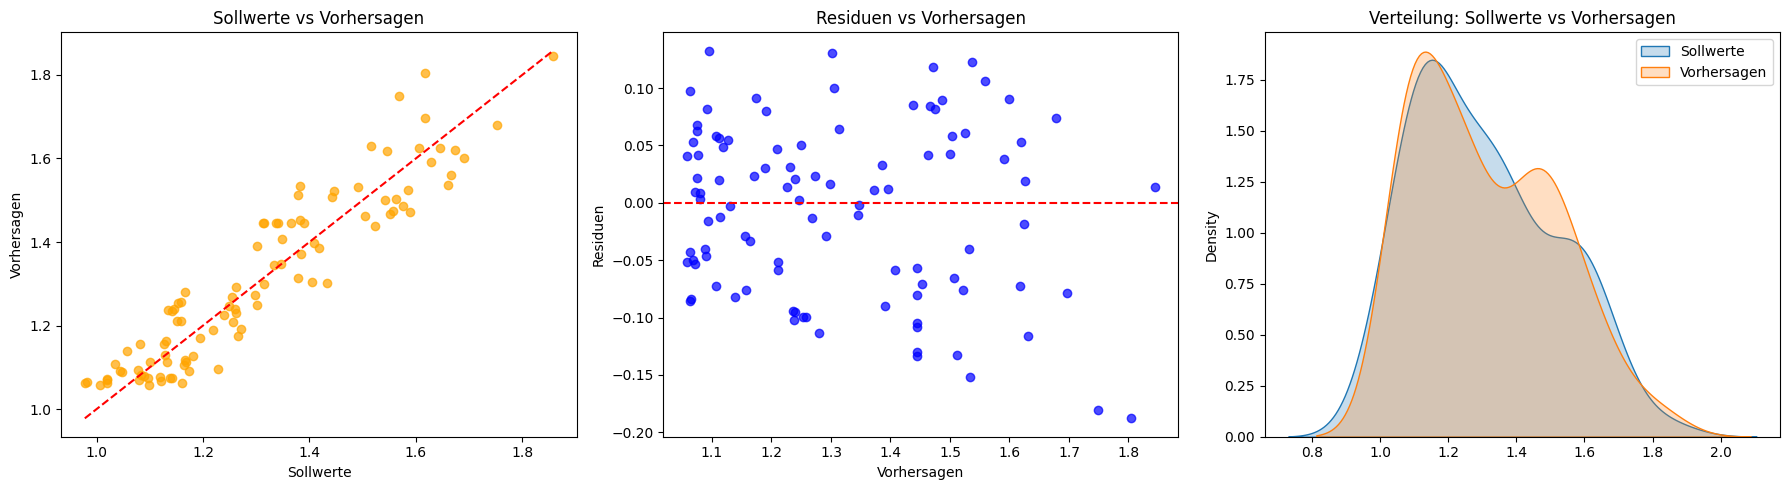

RMSprop_l4_lr_0.001_mse_2
Epoch 1/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0153 - mae: 0.0781 - mse: 0.0153 - val_loss: 0.0074 - val_mae: 0.0693 - val_mse: 0.0074
Epoch 2/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0062 - mae: 0.0647 - mse: 0.0062 - val_loss: 0.0057 - val_mae: 0.0630 - val_mse: 0.0057
Epoch 3/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0060 - mae: 0.0636 - mse: 0.0060 - val_loss: 0.0062 - val_mae: 0.0644 - val_mse: 0.0062
Epoch 4/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0058 - mae: 0.0630 - mse: 0.0058 - val_loss: 0.0066 - val_mae: 0.0658 - val_mse: 0.0066
Epoch 5/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0057 - mae: 0.0625 - mse: 0.0057 - val_loss: 0.0060 - val_mae: 0.0646 - val_mse: 0.0060
Epoch 6/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0056 - mae: 0.0623 - mse: 0.0056 - val_loss: 0.0064 - val_mae: 0.0655 - val_mse: 0.0064
Epoch 7/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 

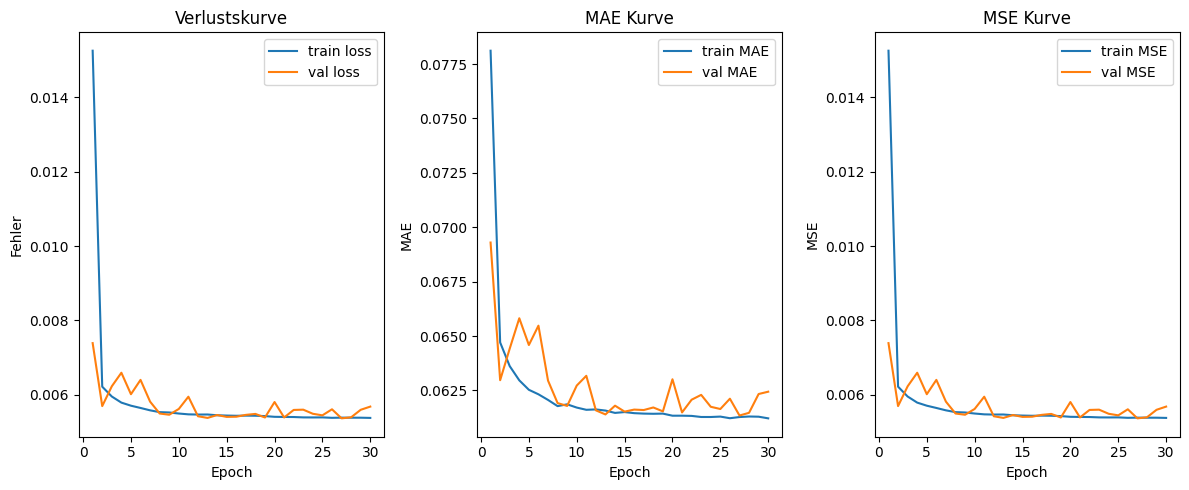

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


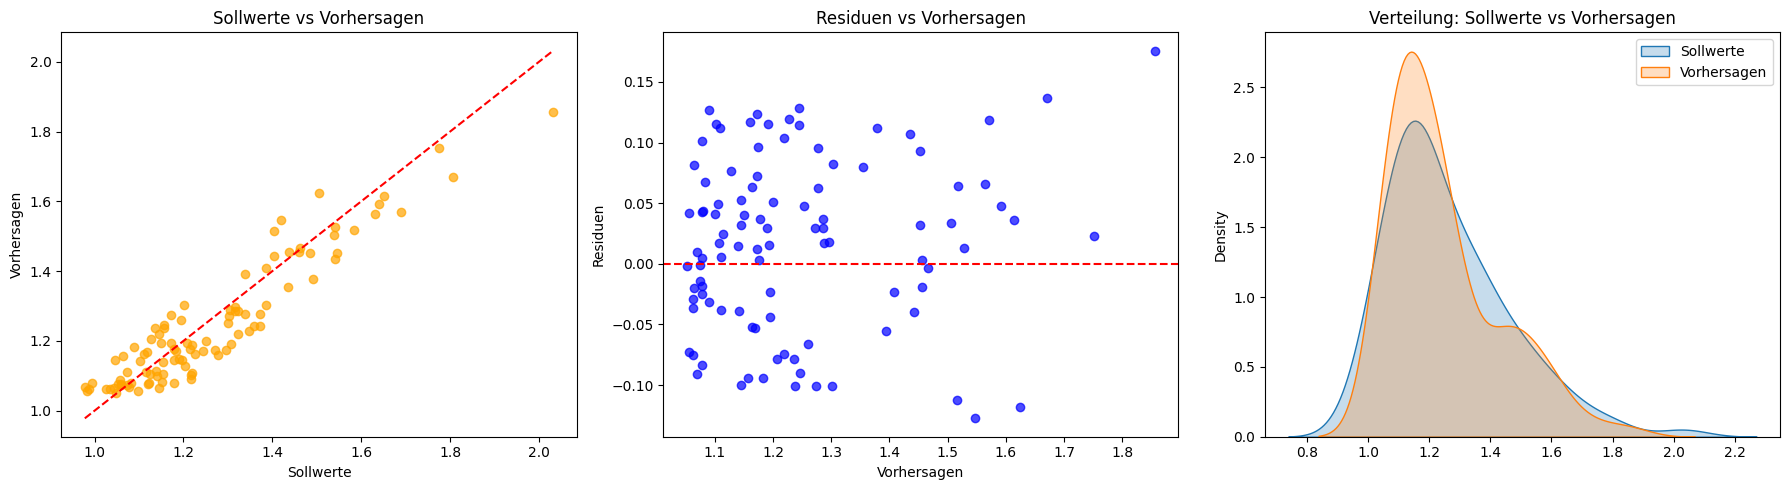

RMSprop_l4_lr_0.01_mse_3
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0449 - mae: 0.1600 - mse: 0.0449 - val_loss: 0.0162 - val_mae: 0.1006 - val_mse: 0.0162
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0120 - mae: 0.0868 - mse: 0.0120 - val_loss: 0.0072 - val_mae: 0.0685 - val_mse: 0.0072
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0089 - mae: 0.0741 - mse: 0.0089 - val_loss: 0.0073 - val_mae: 0.0688 - val_mse: 0.0073
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0080 - mae: 0.0709 - mse: 0.0080 - val_loss: 0.0088 - val_mae: 0.0763 - val_mse: 0.0088
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0075 - mae: 0.0692 - mse: 0.0075 - val_loss: 0.0056 - val_mae: 0.0620 - val_mse: 0.0056
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0071 - mae: 0.0676 - mse: 0.0071 - val_loss: 0.0081 - val_mae: 0.0708 - val_mse: 0.0081
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0069 - mae: 0

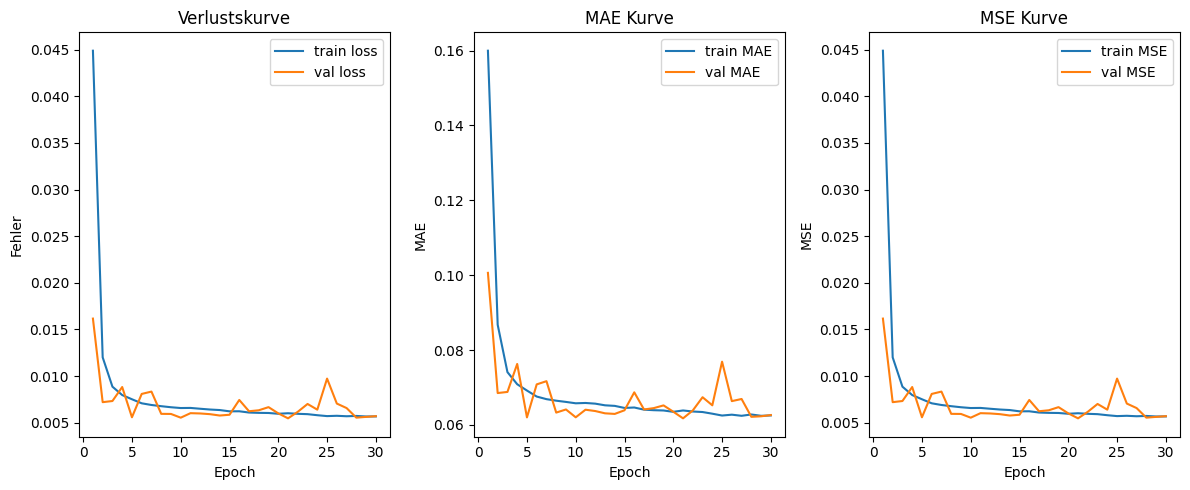

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


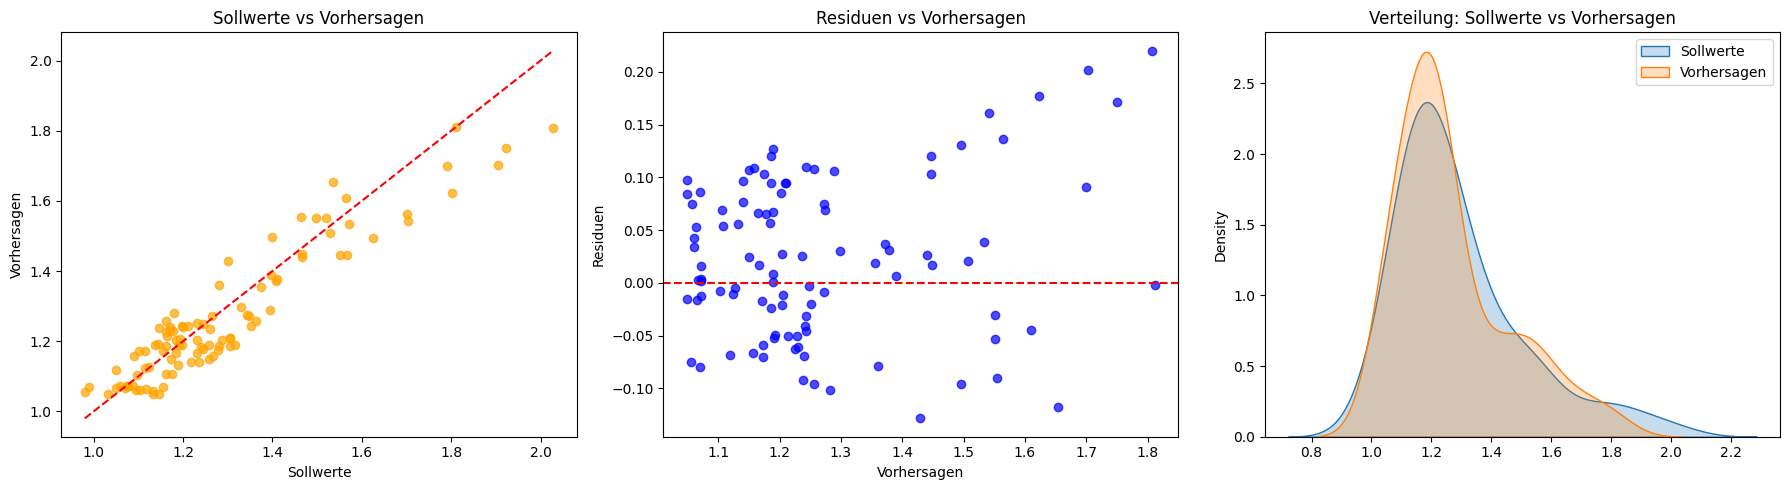

In [61]:
# Neuronale Netze mit unterschiedlichen Architekturen aufstellen
models_2 = [
    # sgd
    KerasModel(
        name="SGD_l4_lr_0.01_mse_1",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="SGD_l4_lr_0.01_mse_mm_0.9",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="SGD_l4_lr_0.001_mse_10",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
        loss_function="mse",
        epochs=30,
        layers=[
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="SGD_l4_lr_0.01_mse_10",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        loss_function="mse",
        epochs=30,
        batch_size=None,
        layers=[
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    # sehr gutes Modell, flunktuierende Verlustkurve,
    KerasModel(
        name="Adam_l4_lr_0.1_mse_1",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="Adam_l4_lr_0.001_mse_2",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="Adam_l4_lr_0.01_mse_3",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        epochs=30,
        batch_size=None,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="RMSprop_l4_lr_0.01_mse_1",
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.01),
        epochs=30,
        batch_size=None,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="RMSprop_l4_lr_0.001_mse_2",
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
        epochs=30,
        batch_size=32,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="RMSprop_l4_lr_0.01_mse_3",
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.01),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
]

train_neuronal_nets(models_2)

SGD_l2_drp_0.2_lr_0.01_mse_1
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2912 - mae: 0.4007 - mse: 0.2912 - val_loss: 0.0398 - val_mae: 0.1542 - val_mse: 0.0398
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0600 - mae: 0.1865 - mse: 0.0600 - val_loss: 0.0189 - val_mae: 0.1082 - val_mse: 0.0189
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0344 - mae: 0.1396 - mse: 0.0344 - val_loss: 0.0138 - val_mae: 0.0937 - val_mse: 0.0138
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0245 - mae: 0.1188 - mse: 0.0245 - val_loss: 0.0120 - val_mae: 0.0878 - val_mse: 0.0120
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0201 - mae: 0.1085 - mse: 0.0201 - val_loss: 0.0109 - val_mae: 0.0844 - val_mse: 0.0109
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0176 - mae: 0.1018 - mse: 0.0176 - val_loss: 0.0102 - val_mae: 0.0821 - val_mse: 0.0102
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0161 - ma

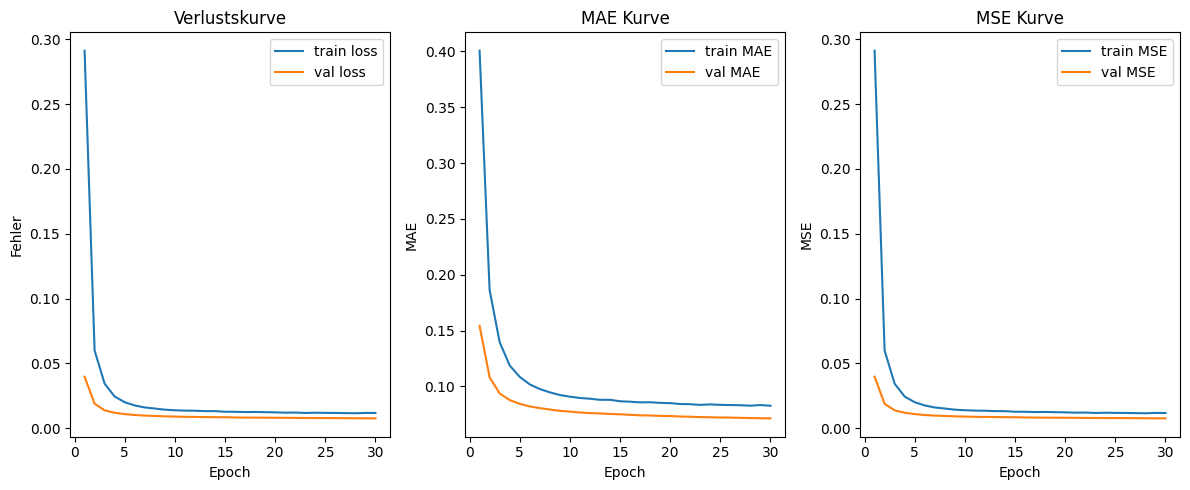

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


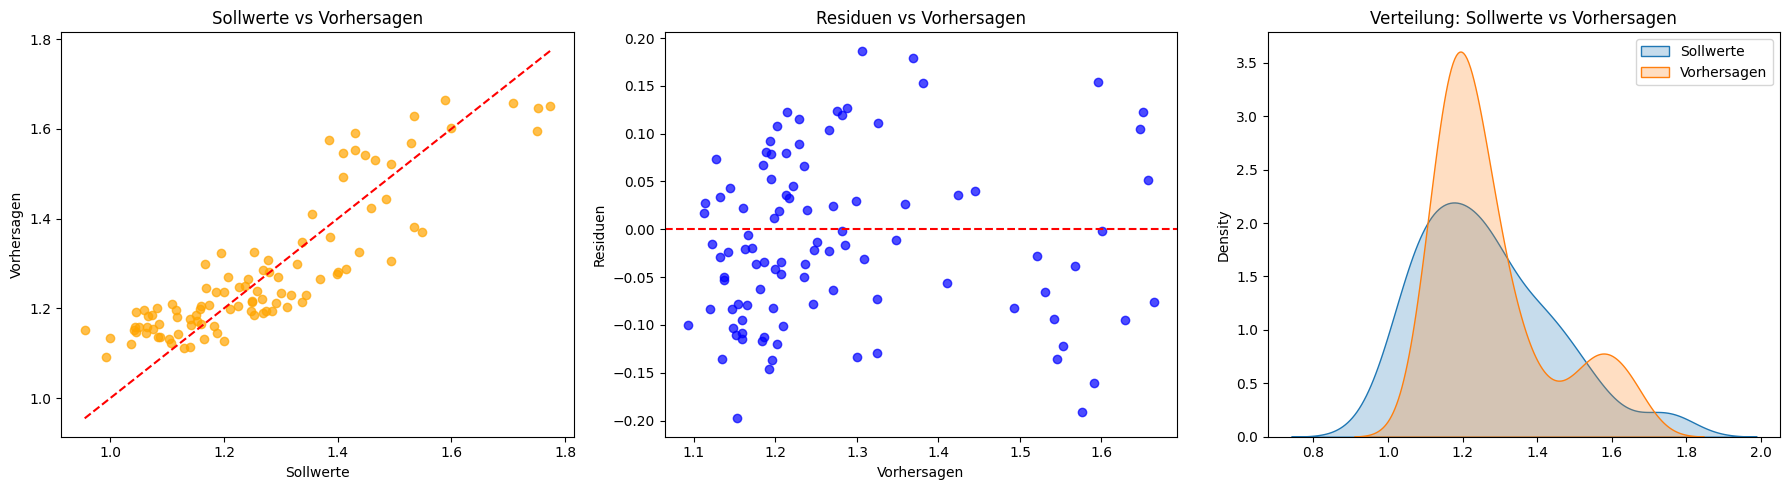

SGD_l2_drp_0.4_lr_0.01_mse_1
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2807 - mae: 0.4043 - mse: 0.2807 - val_loss: 0.0251 - val_mae: 0.1213 - val_mse: 0.0251
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0414 - mae: 0.1568 - mse: 0.0414 - val_loss: 0.0165 - val_mae: 0.0975 - val_mse: 0.0165
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0274 - mae: 0.1270 - mse: 0.0274 - val_loss: 0.0158 - val_mae: 0.0964 - val_mse: 0.0158
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0239 - mae: 0.1192 - mse: 0.0239 - val_loss: 0.0153 - val_mae: 0.0954 - val_mse: 0.0153
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0224 - mae: 0.1156 - mse: 0.0224 - val_loss: 0.0149 - val_mae: 0.0943 - val_mse: 0.0149
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0217 - mae: 0.1132 - mse: 0.0217 - val_loss: 0.0144 - val_mae: 0.0930 - val_mse: 0.0144
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0208 - ma

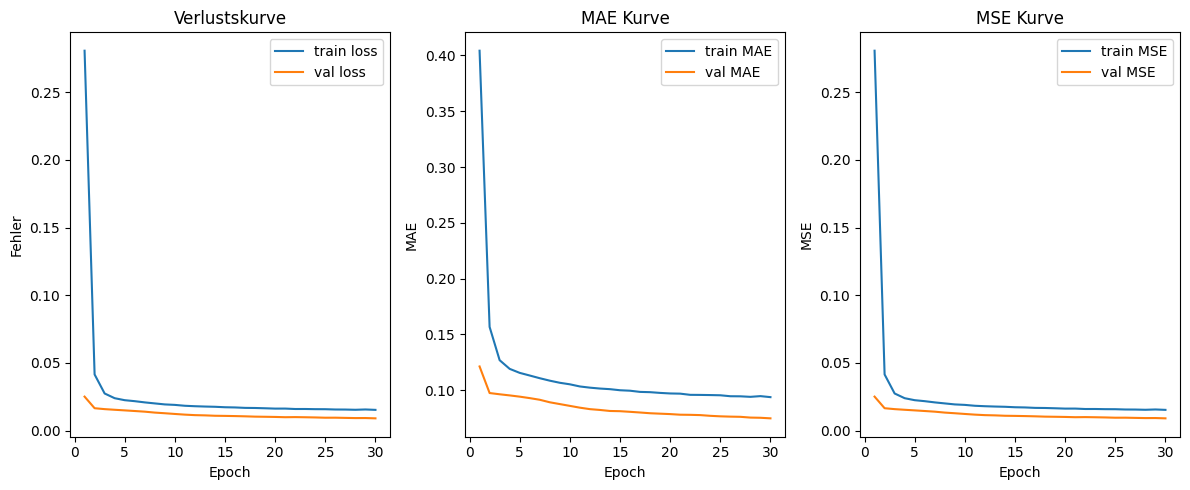

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


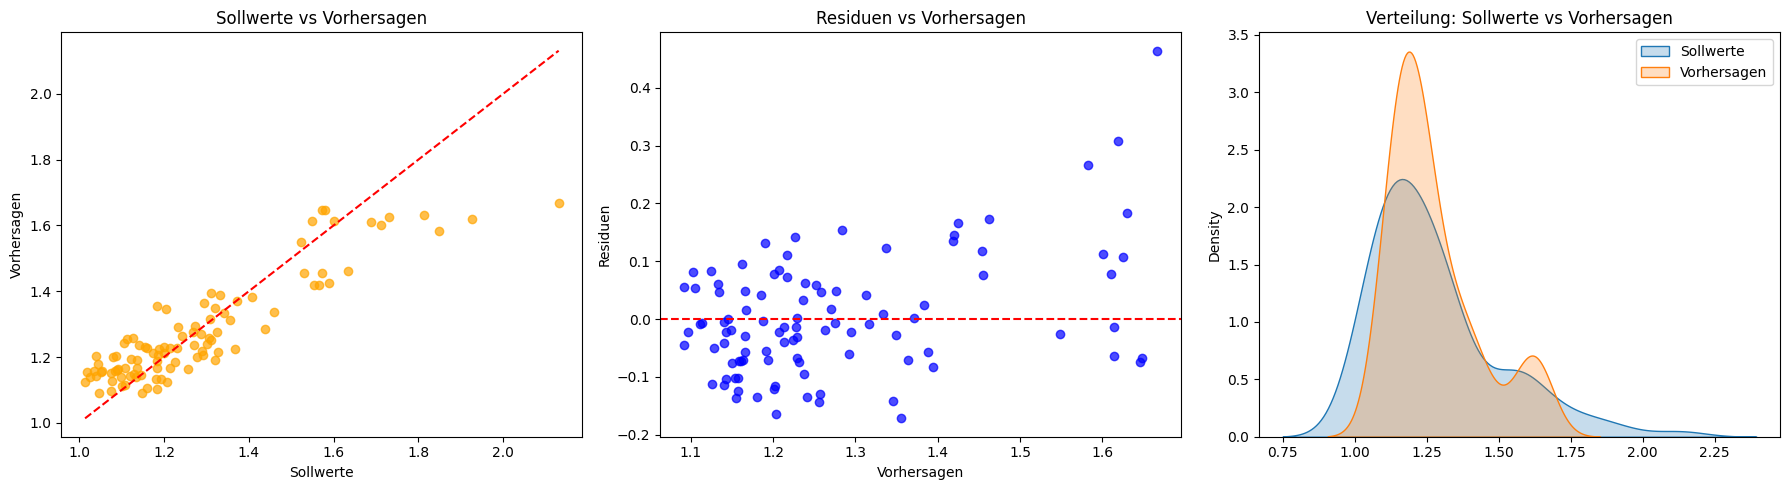

Adam_l2_drp_0.2_lr_0.1_mse_1
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0820 - mae: 0.1372 - mse: 0.0820 - val_loss: 0.0061 - val_mae: 0.0640 - val_mse: 0.0061
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0094 - mae: 0.0754 - mse: 0.0094 - val_loss: 0.0059 - val_mae: 0.0637 - val_mse: 0.0059
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0092 - mae: 0.0745 - mse: 0.0092 - val_loss: 0.0060 - val_mae: 0.0639 - val_mse: 0.0060
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0086 - mae: 0.0729 - mse: 0.0086 - val_loss: 0.0059 - val_mae: 0.0631 - val_mse: 0.0059
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0083 - mae: 0.0722 - mse: 0.0083 - val_loss: 0.0064 - val_mae: 0.0645 - val_mse: 0.0064
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0082 - mae: 0.0717 - mse: 0.0082 - val_loss: 0.0062 - val_mae: 0.0639 - val_mse: 0.0062
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0082 - ma

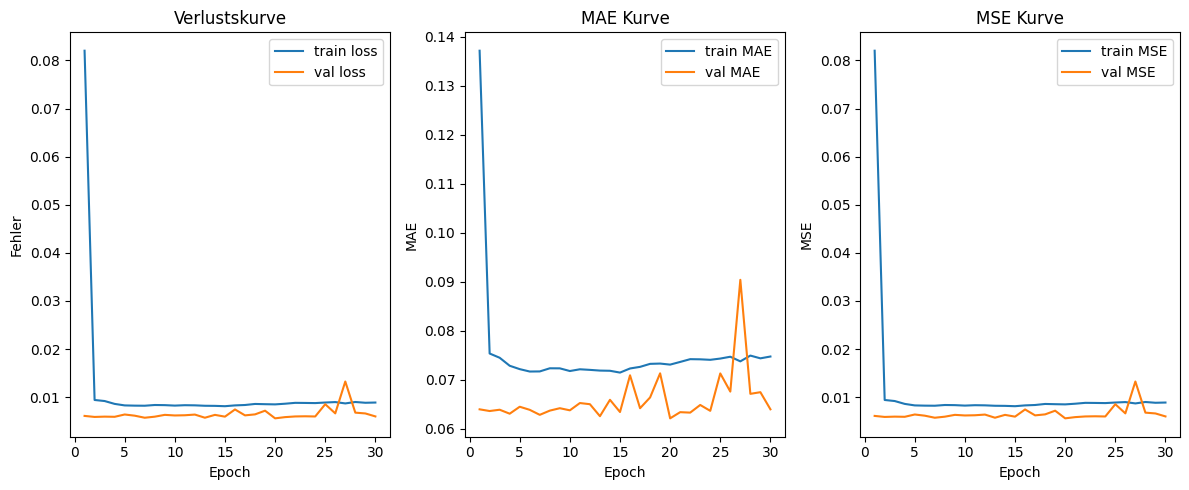

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


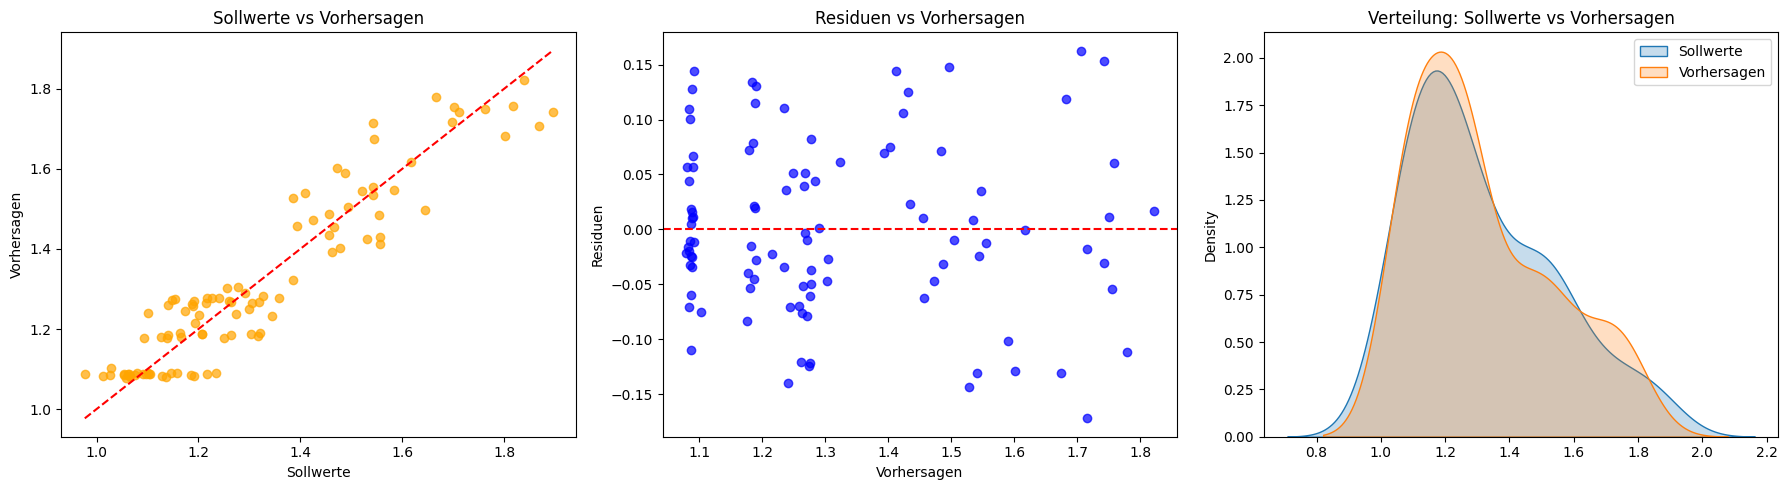

Adam_l2_drp_0.4_lr_0.1_mse_1
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0370 - mae: 0.1172 - mse: 0.0370 - val_loss: 0.0101 - val_mae: 0.0775 - val_mse: 0.0101
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0120 - mae: 0.0840 - mse: 0.0120 - val_loss: 0.0063 - val_mae: 0.0656 - val_mse: 0.0063
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0119 - mae: 0.0836 - mse: 0.0119 - val_loss: 0.0062 - val_mae: 0.0648 - val_mse: 0.0062
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0116 - mae: 0.0829 - mse: 0.0116 - val_loss: 0.0064 - val_mae: 0.0656 - val_mse: 0.0064
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0121 - mae: 0.0845 - mse: 0.0121 - val_loss: 0.0067 - val_mae: 0.0682 - val_mse: 0.0067
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0121 - mae: 0.0846 - mse: 0.0121 - val_loss: 0.0089 - val_mae: 0.0722 - val_mse: 0.0089
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0122 - m

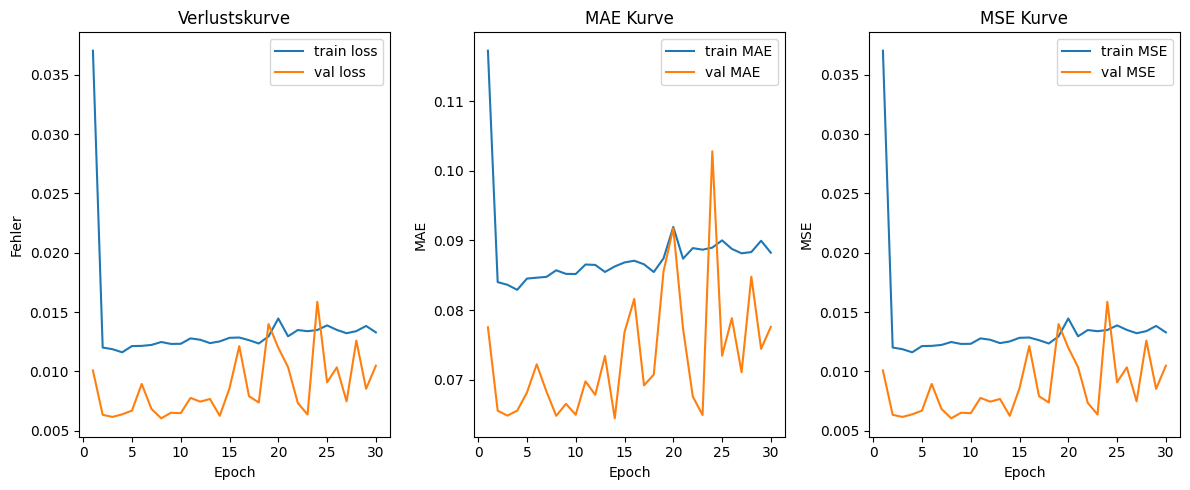

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


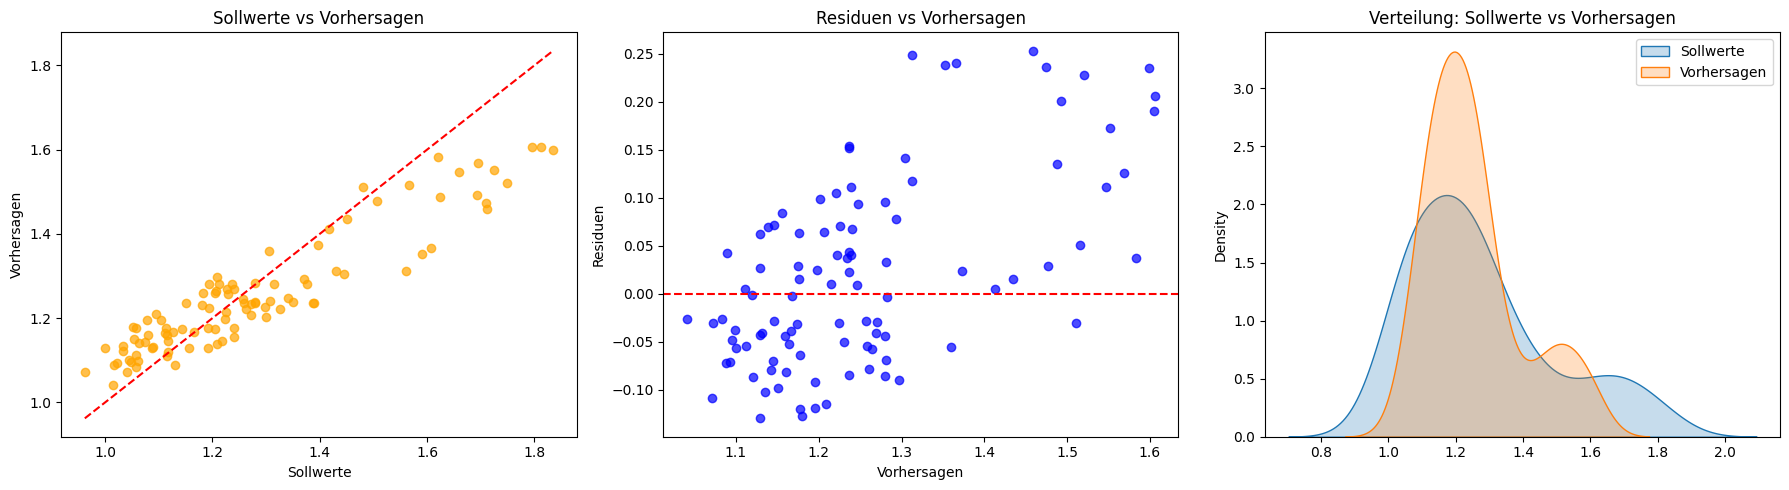

RMSprop_l2_drp_0.2_lr_0.01_mse_1
Epoch 1/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0306 - mae: 0.0975 - mse: 0.0306 - val_loss: 0.0076 - val_mae: 0.0681 - val_mse: 0.0076
Epoch 2/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0090 - mae: 0.0743 - mse: 0.0090 - val_loss: 0.0059 - val_mae: 0.0637 - val_mse: 0.0059
Epoch 3/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0089 - mae: 0.0742 - mse: 0.0089 - val_loss: 0.0073 - val_mae: 0.0672 - val_mse: 0.0073
Epoch 4/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0089 - mae: 0.0741 - mse: 0.0089 - val_loss: 0.0060 - val_mae: 0.0636 - val_mse: 0.0060
Epoch 5/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0089 - mae: 0.0739 - mse: 0.0089 - val_loss: 0.0059 - val_mae: 0.0635 - val_mse: 0.0059
Epoch 6/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0090 - mae: 0.0743 - mse: 0.0090 - val_loss: 0.0065 - val_mae: 0.0648 - val_mse: 0.0065
Epoch 7/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/ste

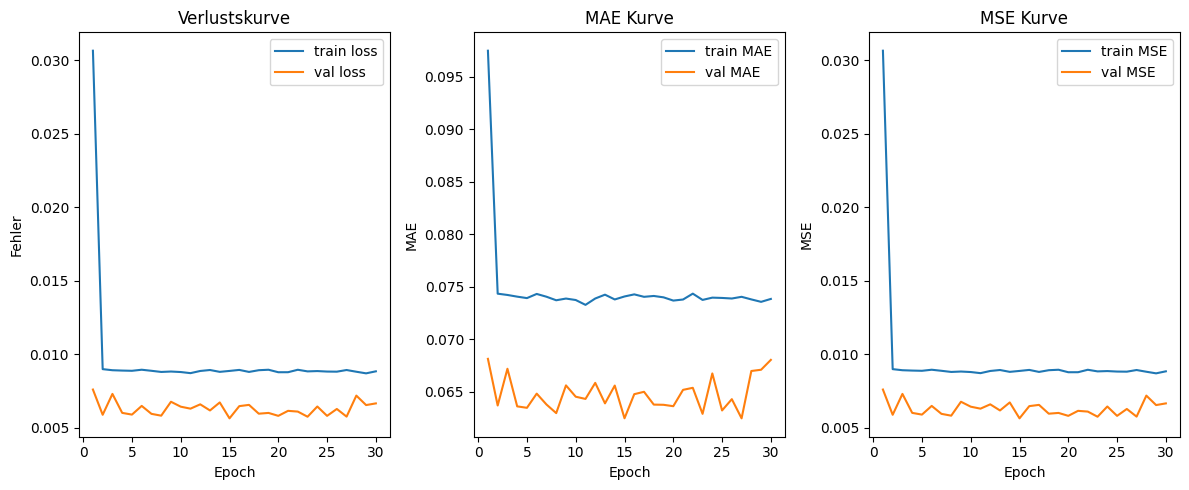

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


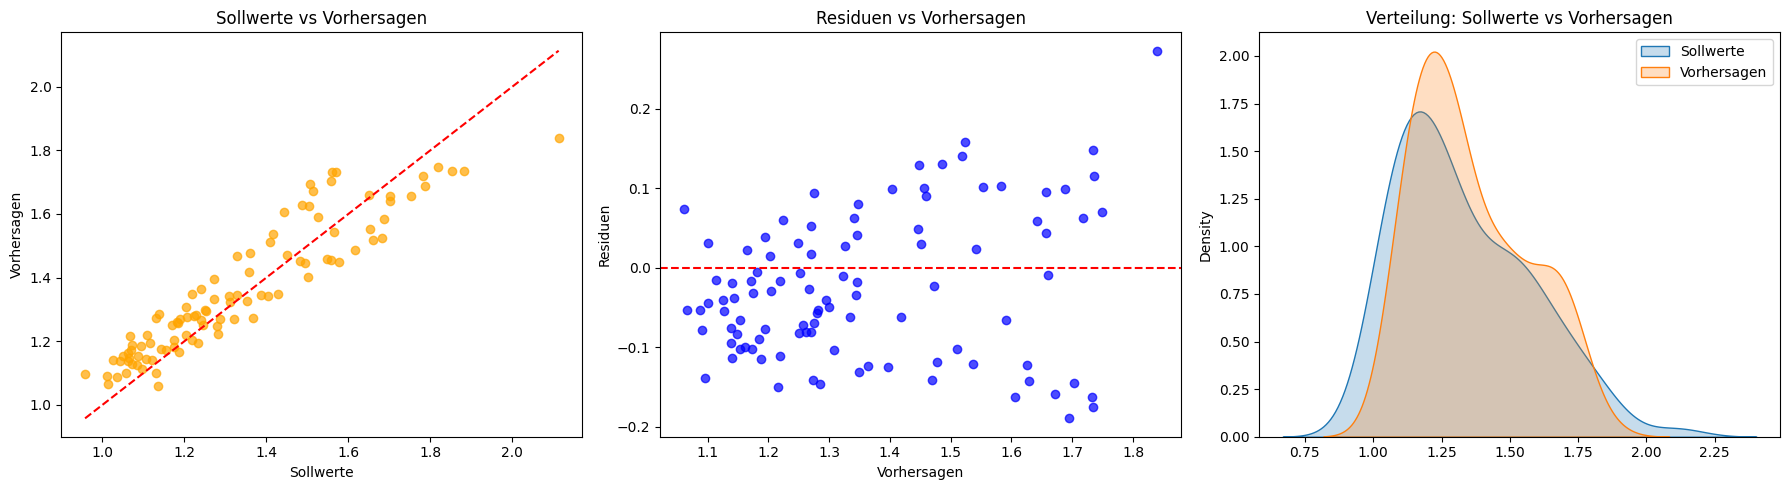

RMSprop_l2_drp_0.4_lr_0.01_mse_1
Epoch 1/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0304 - mae: 0.1076 - mse: 0.0304 - val_loss: 0.0085 - val_mae: 0.0744 - val_mse: 0.0085
Epoch 2/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0126 - mae: 0.0856 - mse: 0.0126 - val_loss: 0.0089 - val_mae: 0.0754 - val_mse: 0.0089
Epoch 3/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0126 - mae: 0.0857 - mse: 0.0126 - val_loss: 0.0075 - val_mae: 0.0718 - val_mse: 0.0075
Epoch 4/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0126 - mae: 0.0854 - mse: 0.0126 - val_loss: 0.0079 - val_mae: 0.0733 - val_mse: 0.0079
Epoch 5/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0124 - mae: 0.0854 - mse: 0.0124 - val_loss: 0.0092 - val_mae: 0.0767 - val_mse: 0.0092
Epoch 6/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0127 - mae: 0.0859 - mse: 0.0127 - val_loss: 0.0073 - val_mae: 0.0711 - val_mse: 0.0073
Epoch 7/30
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step -

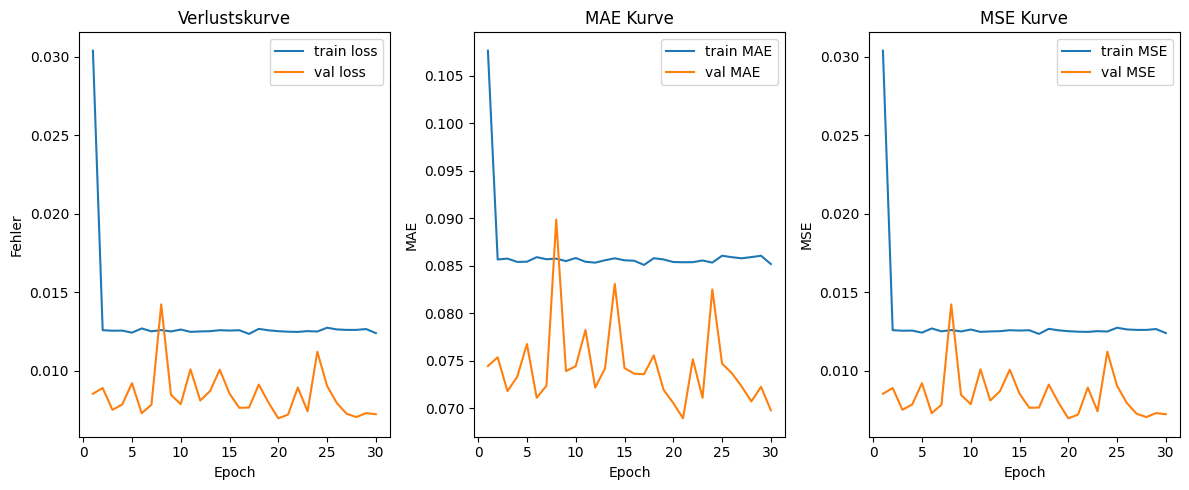

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


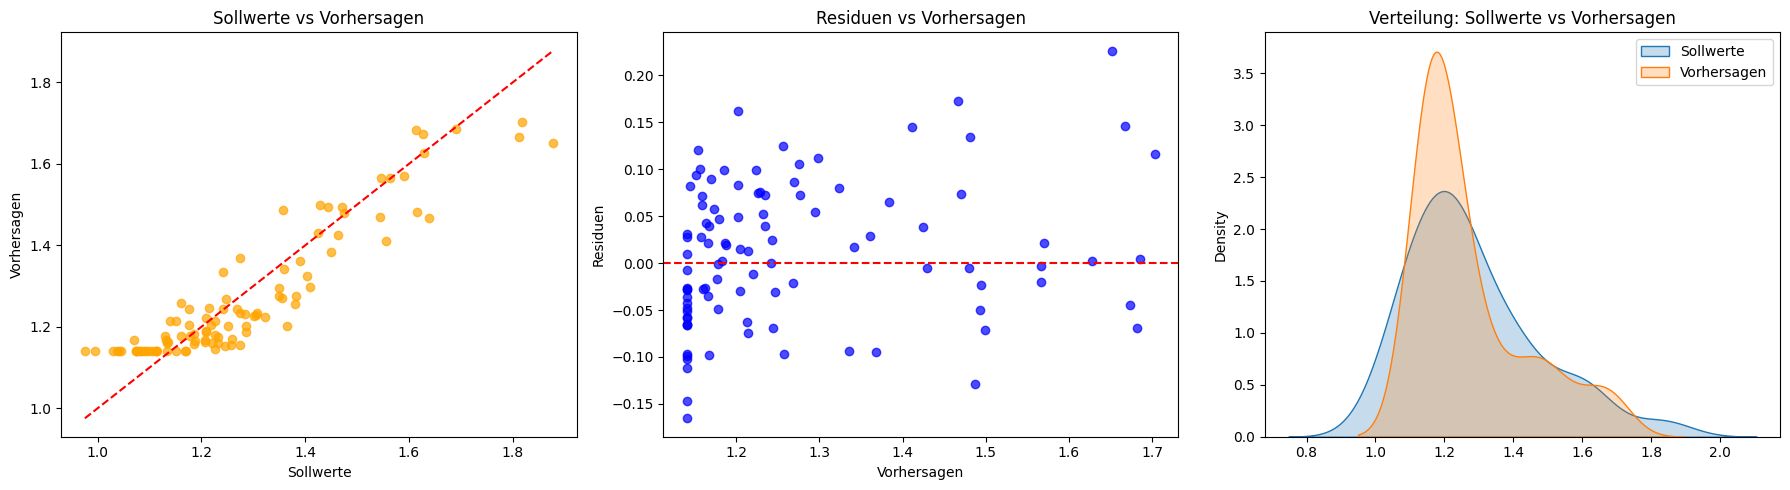

In [62]:
# Regulaisierte neuronale Netze aufstellen
models_drp = [
    # sgd
    KerasModel(
        name="SGD_l2_drp_0.2_lr_0.01_mse_1",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="SGD_l2_drp_0.4_lr_0.01_mse_1",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dropout(0.4),
            tf.keras.layers.Dense(1),
        ],
    ),
    # sehr gutes Modell, flunktuierende Verlustkurve,
    KerasModel(
        name="Adam_l2_drp_0.2_lr_0.1_mse_1",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="Adam_l2_drp_0.4_lr_0.1_mse_1",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dropout(0.4),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="RMSprop_l2_drp_0.2_lr_0.01_mse_1",
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.01),
        epochs=30,
        batch_size=None,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="RMSprop_l2_drp_0.4_lr_0.01_mse_1",
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.01),
        epochs=30,
        batch_size=None,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dropout(0.4),
            tf.keras.layers.Dense(1),
        ],
    ),
]

train_neuronal_nets(models_drp)

SGD_lr_0.01_mse_mm_0.2
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1499 - mae: 0.2629 - mse: 0.1499 - val_loss: 0.0267 - val_mae: 0.1296 - val_mse: 0.0267
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0184 - mae: 0.1067 - mse: 0.0184 - val_loss: 0.0144 - val_mae: 0.0950 - val_mse: 0.0144
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0130 - mae: 0.0900 - mse: 0.0130 - val_loss: 0.0122 - val_mae: 0.0874 - val_mse: 0.0122
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0114 - mae: 0.0846 - mse: 0.0114 - val_loss: 0.0110 - val_mae: 0.0836 - val_mse: 0.0110
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0105 - mae: 0.0814 - mse: 0.0105 - val_loss: 0.0103 - val_mae: 0.0807 - val_mse: 0.0103
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0099 - mae: 0.0790 - mse: 0.0099 - val_loss: 0.0097 - val_mae: 0.0787 - val_mse: 0.0097
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0094 - mae: 0.0

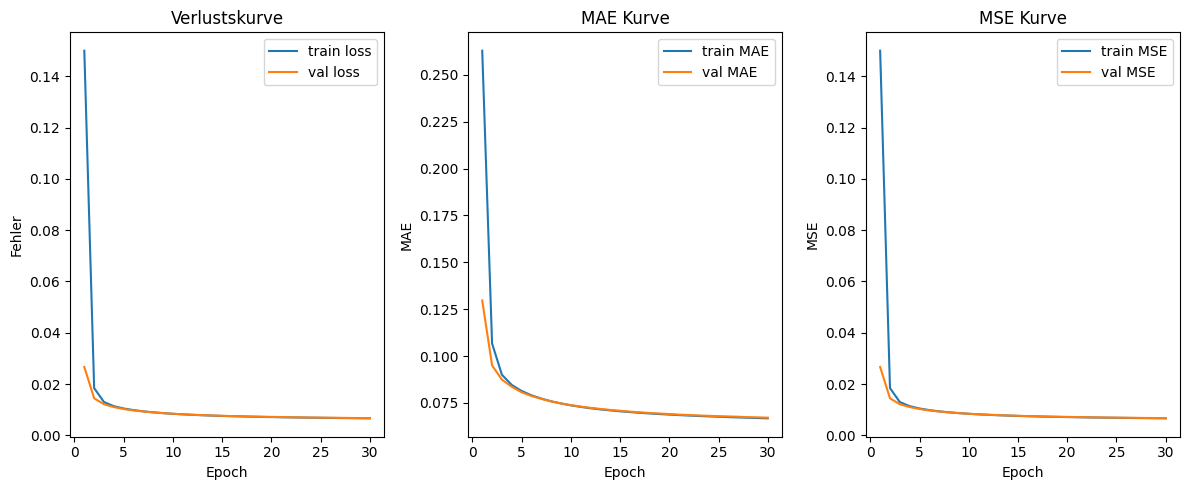

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


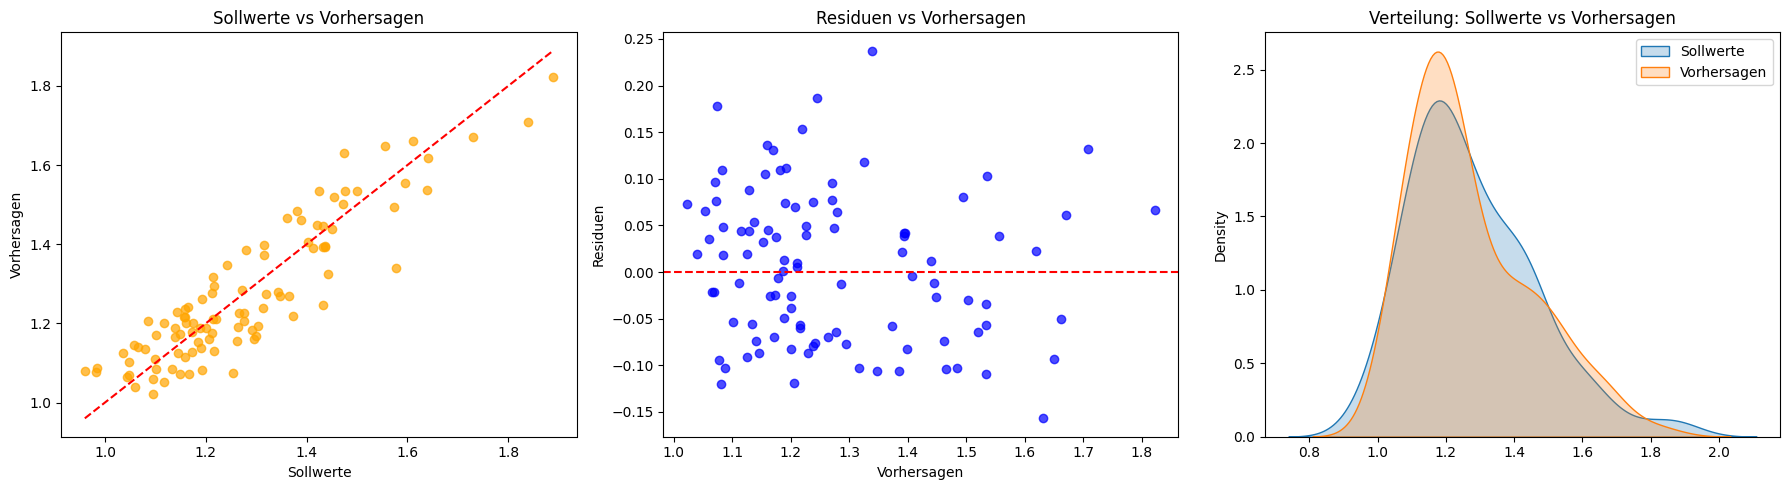

SGD_lr_0.01_mse_mm_0.6
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1026 - mae: 0.1873 - mse: 0.1026 - val_loss: 0.0128 - val_mae: 0.0921 - val_mse: 0.0128
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0108 - mae: 0.0843 - mse: 0.0108 - val_loss: 0.0098 - val_mae: 0.0803 - val_mse: 0.0098
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0091 - mae: 0.0771 - mse: 0.0091 - val_loss: 0.0088 - val_mae: 0.0759 - val_mse: 0.0088
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0083 - mae: 0.0741 - mse: 0.0083 - val_loss: 0.0083 - val_mae: 0.0739 - val_mse: 0.0083
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0080 - mae: 0.0725 - mse: 0.0080 - val_loss: 0.0080 - val_mae: 0.0725 - val_mse: 0.0080
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0077 - mae: 0.0714 - mse: 0.0077 - val_loss: 0.0078 - val_mae: 0.0716 - val_mse: 0.0078
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0076 - mae: 0.0

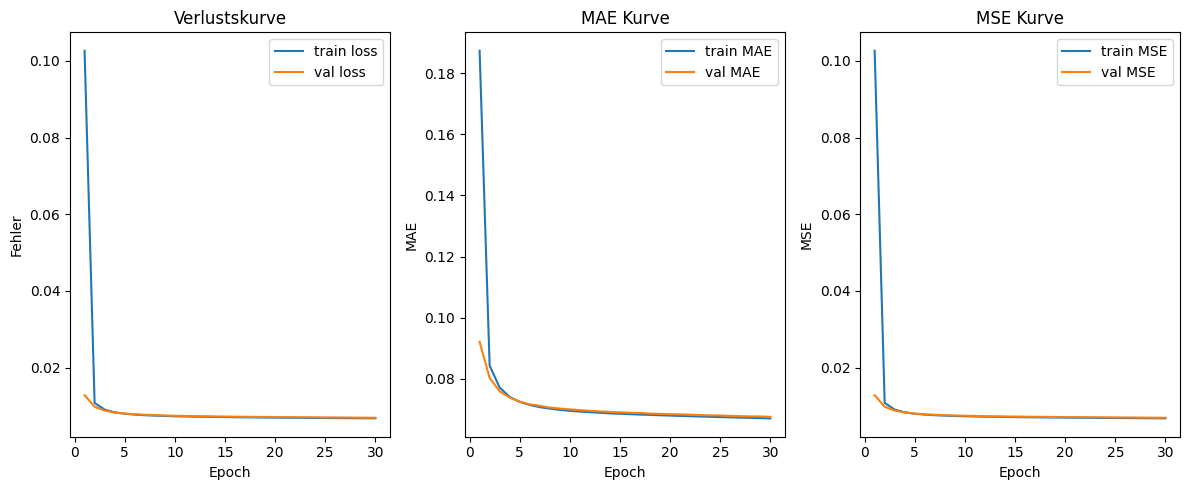

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


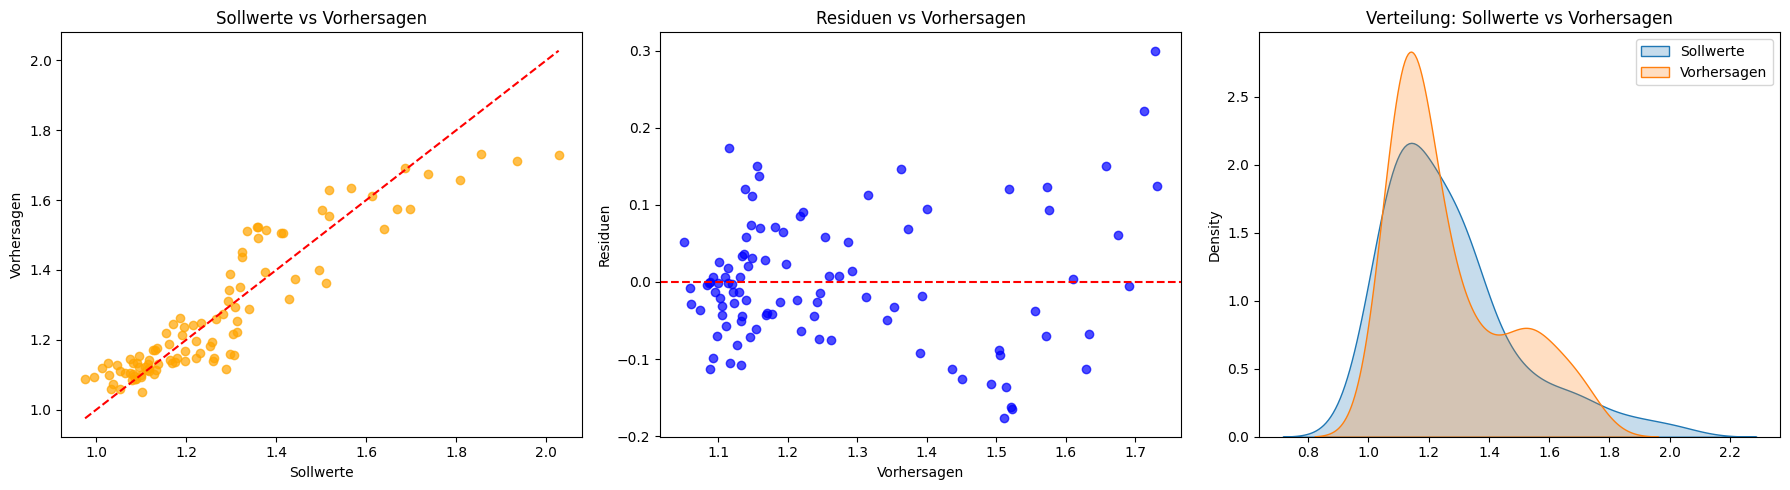

Adam_lr_0.1_mse_1_wd_1e2
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1311 - mae: 0.1983 - mse: 0.1311 - val_loss: 0.0100 - val_mae: 0.0807 - val_mse: 0.0100
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0081 - mae: 0.0728 - mse: 0.0081 - val_loss: 0.0072 - val_mae: 0.0686 - val_mse: 0.0072
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0066 - mae: 0.0663 - mse: 0.0066 - val_loss: 0.0064 - val_mae: 0.0654 - val_mse: 0.0064
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0061 - mae: 0.0642 - mse: 0.0061 - val_loss: 0.0061 - val_mae: 0.0645 - val_mse: 0.0061
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0059 - mae: 0.0634 - mse: 0.0059 - val_loss: 0.0060 - val_mae: 0.0640 - val_mse: 0.0060
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0058 - mae: 0.0632 - mse: 0.0058 - val_loss: 0.0059 - val_mae: 0.0638 - val_mse: 0.0059
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0057 - mae: 0

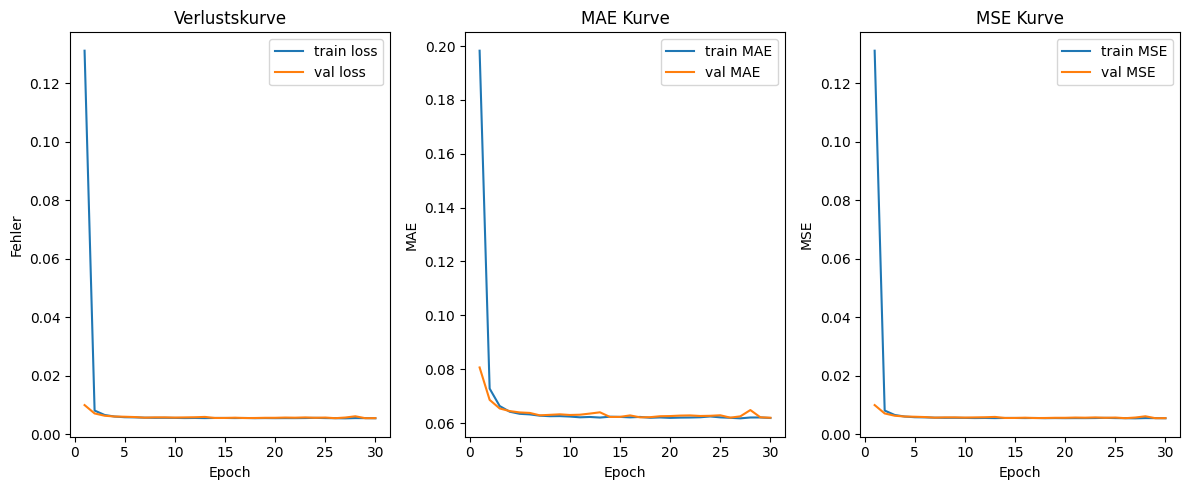

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


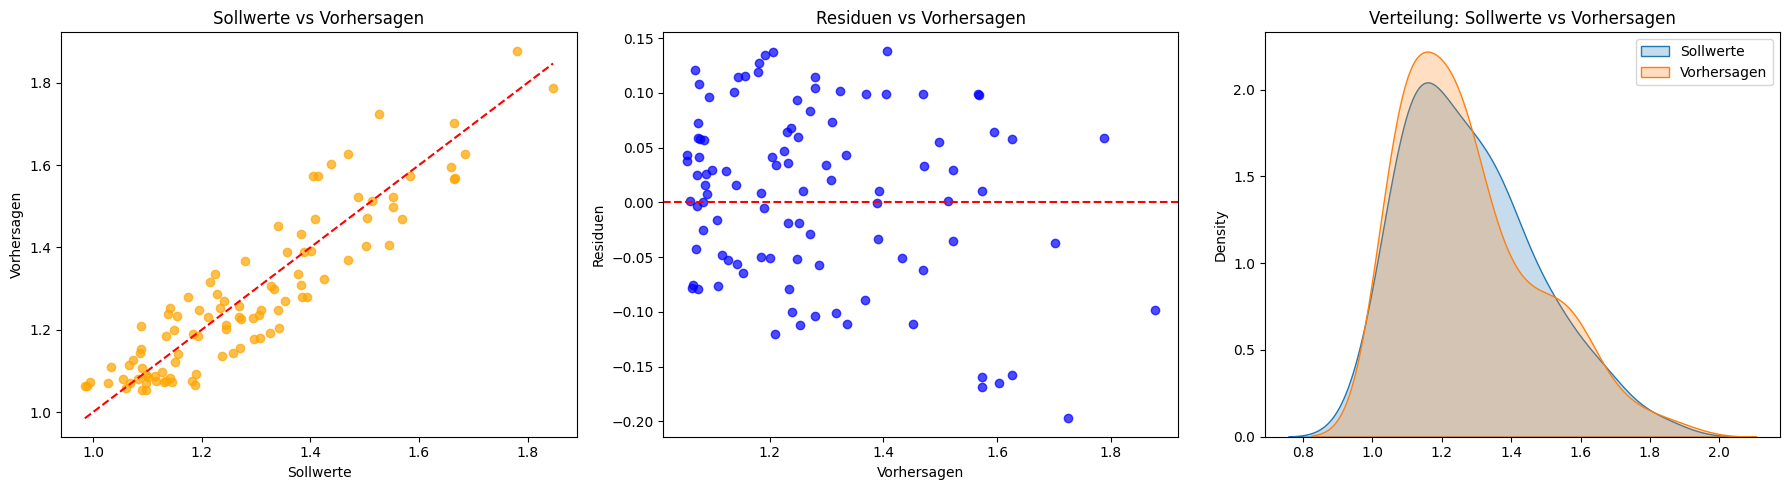

RMSprop_lr_0.01_mse_3_m_0.2
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0410 - mae: 0.1099 - mse: 0.0410 - val_loss: 0.0095 - val_mae: 0.0753 - val_mse: 0.0095
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0079 - mae: 0.0719 - mse: 0.0079 - val_loss: 0.0104 - val_mae: 0.0783 - val_mse: 0.0104
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0075 - mae: 0.0697 - mse: 0.0075 - val_loss: 0.0081 - val_mae: 0.0738 - val_mse: 0.0081
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0070 - mae: 0.0678 - mse: 0.0070 - val_loss: 0.0073 - val_mae: 0.0706 - val_mse: 0.0073
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0068 - mae: 0.0670 - mse: 0.0068 - val_loss: 0.0069 - val_mae: 0.0674 - val_mse: 0.0069
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0066 - mae: 0.0662 - mse: 0.0066 - val_loss: 0.0062 - val_mae: 0.0644 - val_mse: 0.0062
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0064 - mae

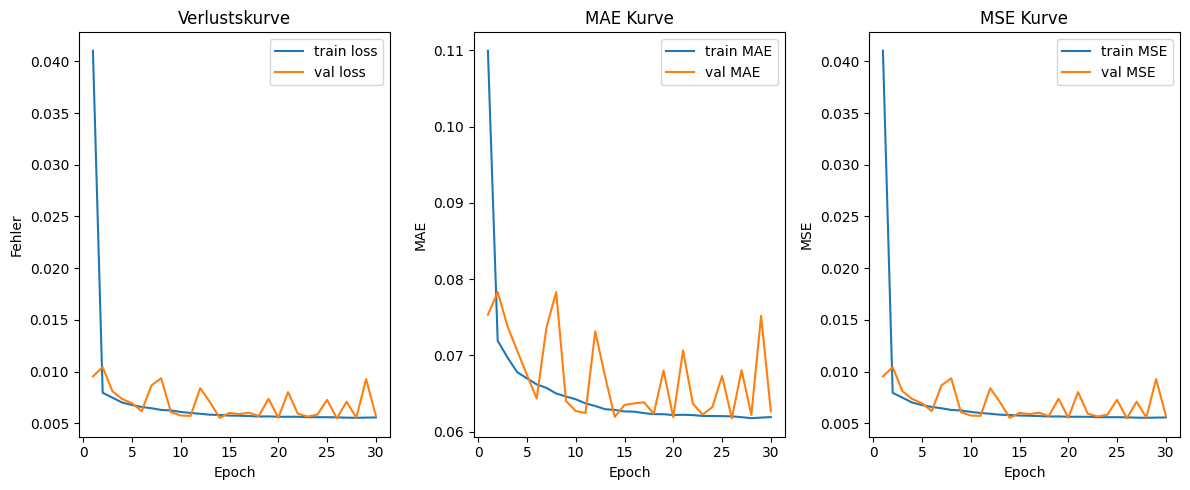

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


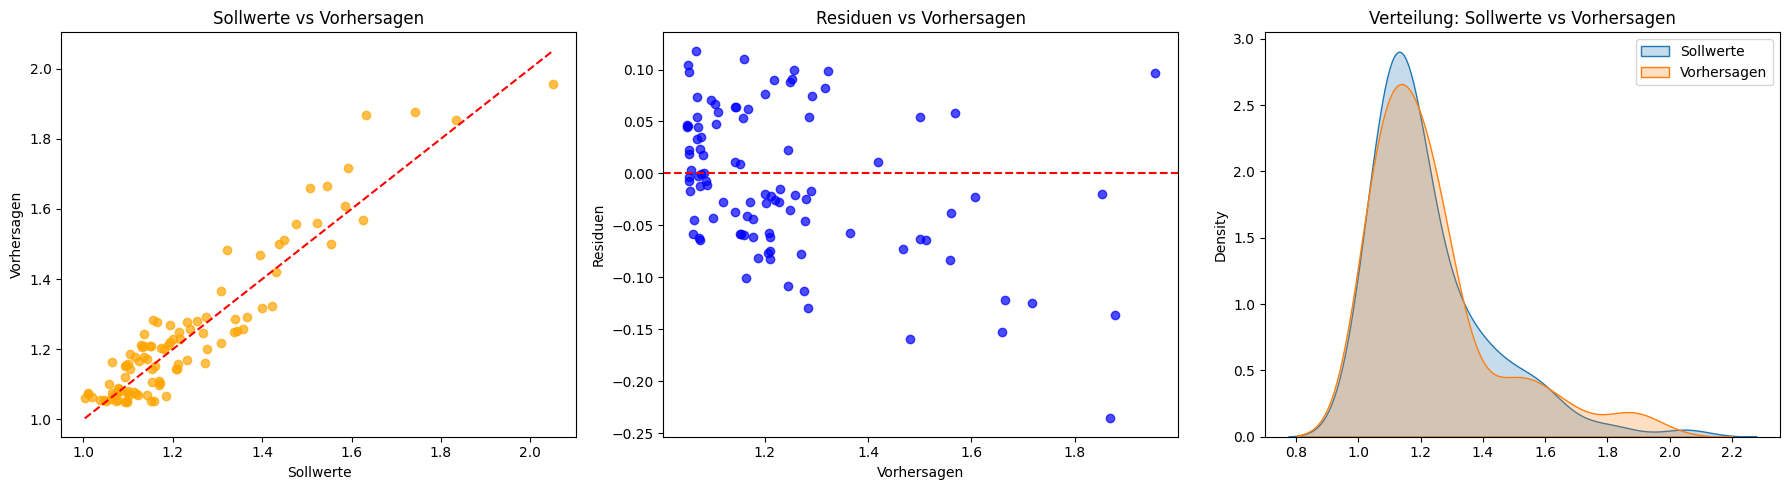

RMSprop_lr_0.01_mse_3_0.6
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0208 - mae: 0.0899 - mse: 0.0208 - val_loss: 0.0067 - val_mae: 0.0684 - val_mse: 0.0067
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0071 - mae: 0.0685 - mse: 0.0071 - val_loss: 0.0073 - val_mae: 0.0679 - val_mse: 0.0073
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0066 - mae: 0.0663 - mse: 0.0066 - val_loss: 0.0069 - val_mae: 0.0672 - val_mse: 0.0069
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0063 - mae: 0.0649 - mse: 0.0063 - val_loss: 0.0075 - val_mae: 0.0703 - val_mse: 0.0075
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0061 - mae: 0.0643 - mse: 0.0061 - val_loss: 0.0062 - val_mae: 0.0642 - val_mse: 0.0062
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0059 - mae: 0.0635 - mse: 0.0059 - val_loss: 0.0058 - val_mae: 0.0632 - val_mse: 0.0058
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0058 - mae: 

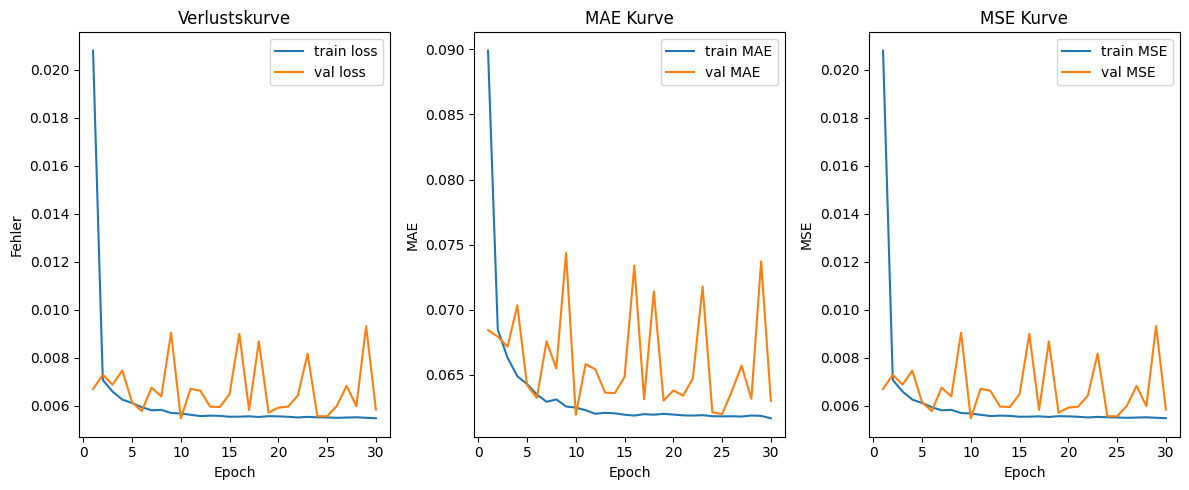

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


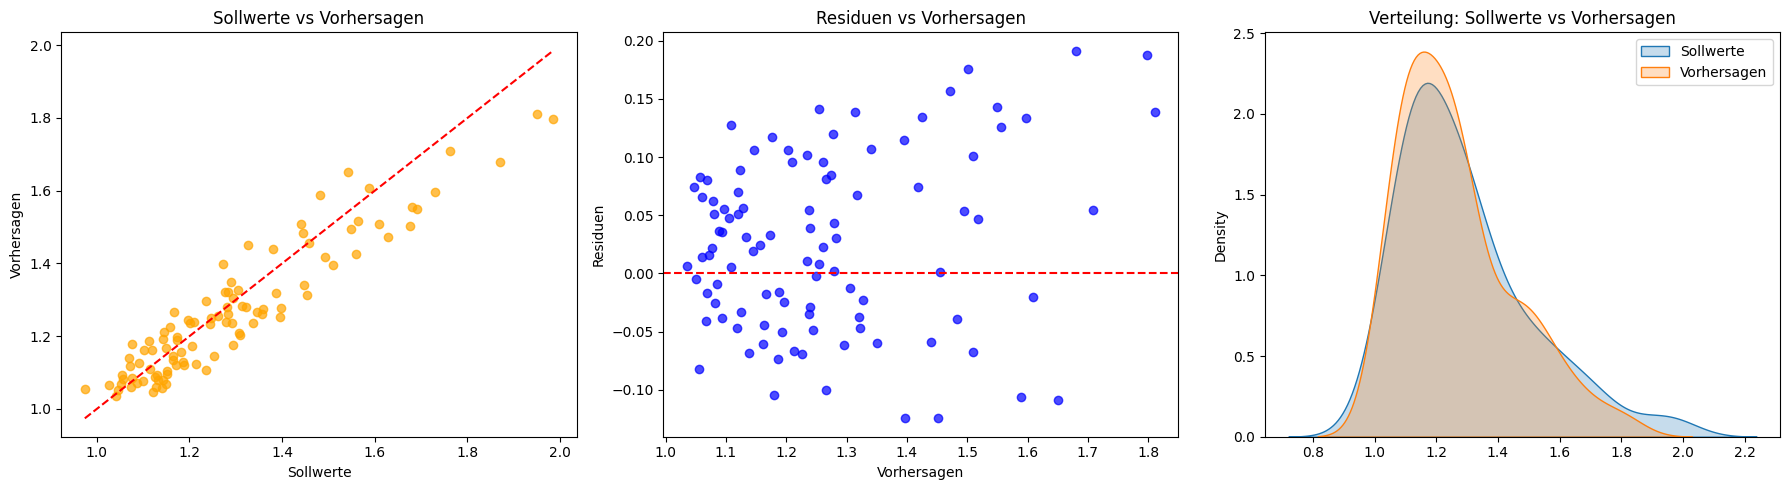

In [63]:
# Neuronale Netze mit Parametern aufstellen
models_paramed = [
    KerasModel(
        name="SGD_lr_0.01_mse_mm_0.2",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.2),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="SGD_lr_0.01_mse_mm_0.6",
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.6),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="Adam_lr_0.1_mse_1_wd_1e2",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01, weight_decay=1e-2),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="RMSprop_lr_0.01_mse_3_m_0.2",
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.01, momentum=0.2),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
    KerasModel(
        name="RMSprop_lr_0.01_mse_3_0.6",
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.01, momentum=0.6),
        epochs=30,
        batch_size=256,
        loss_function="mse",
        layers=[
            tf.keras.layers.Dense(16, activation="relu"),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(1),
        ],
    ),
]

train_neuronal_nets(models_paramed)

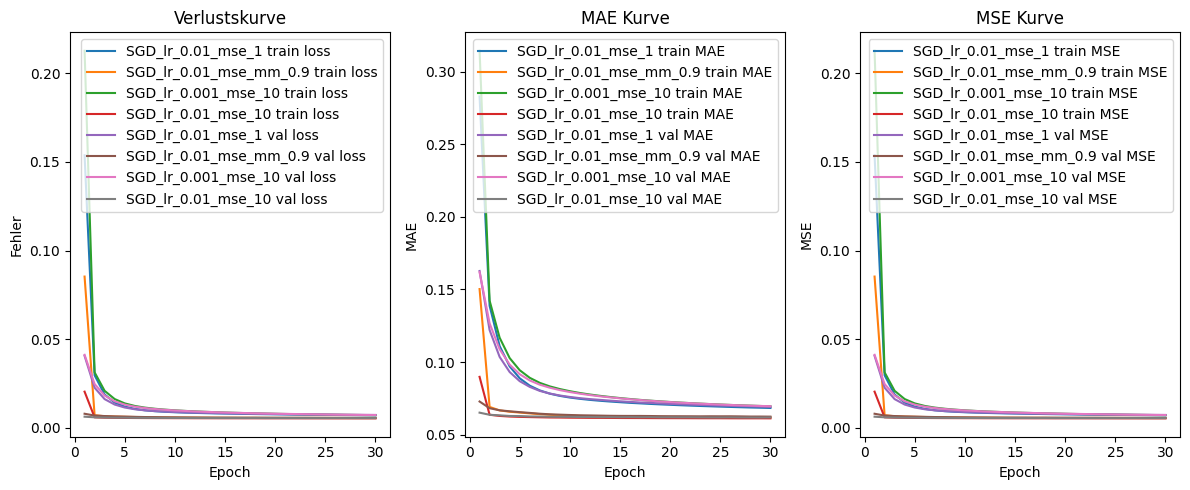

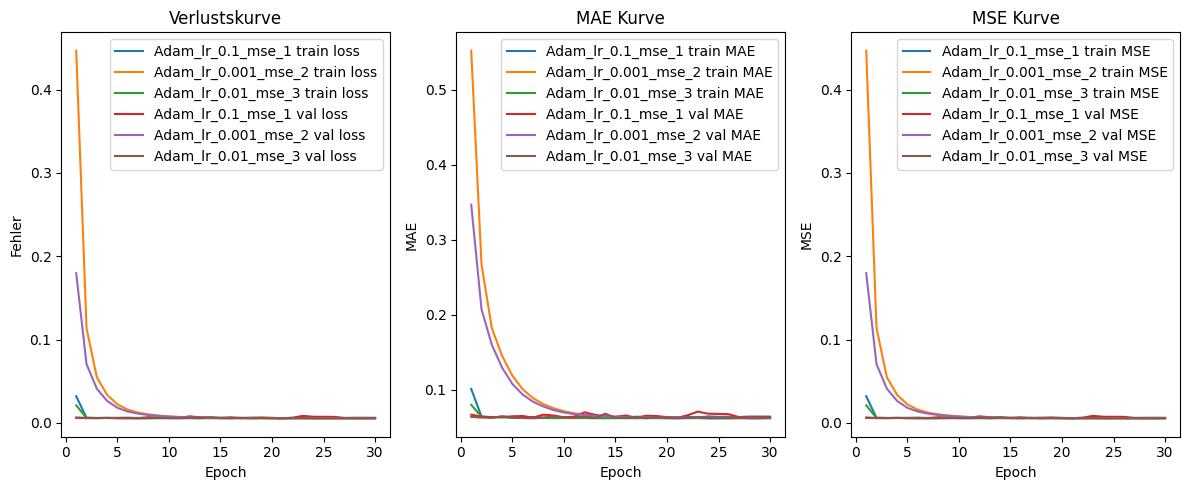

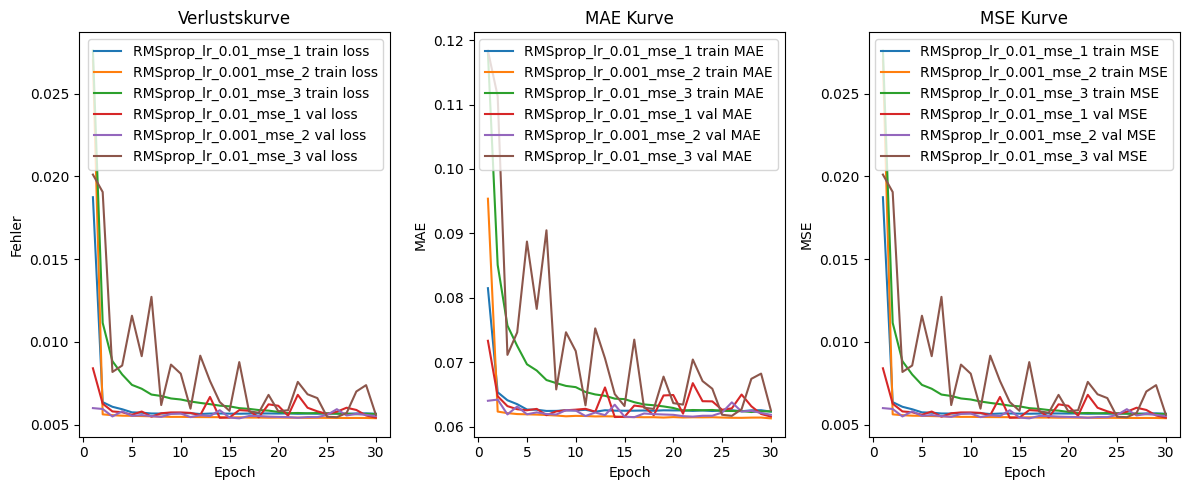

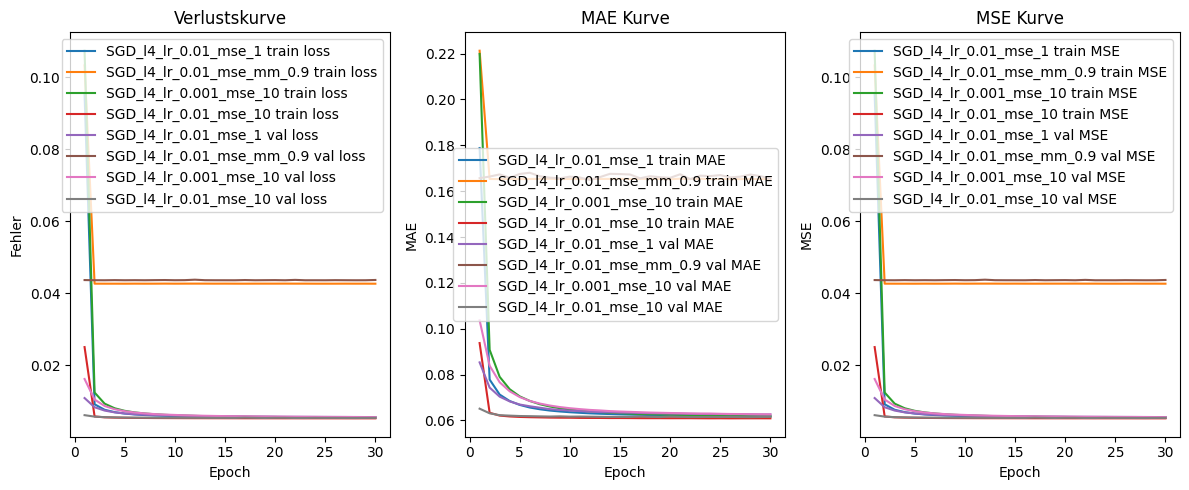

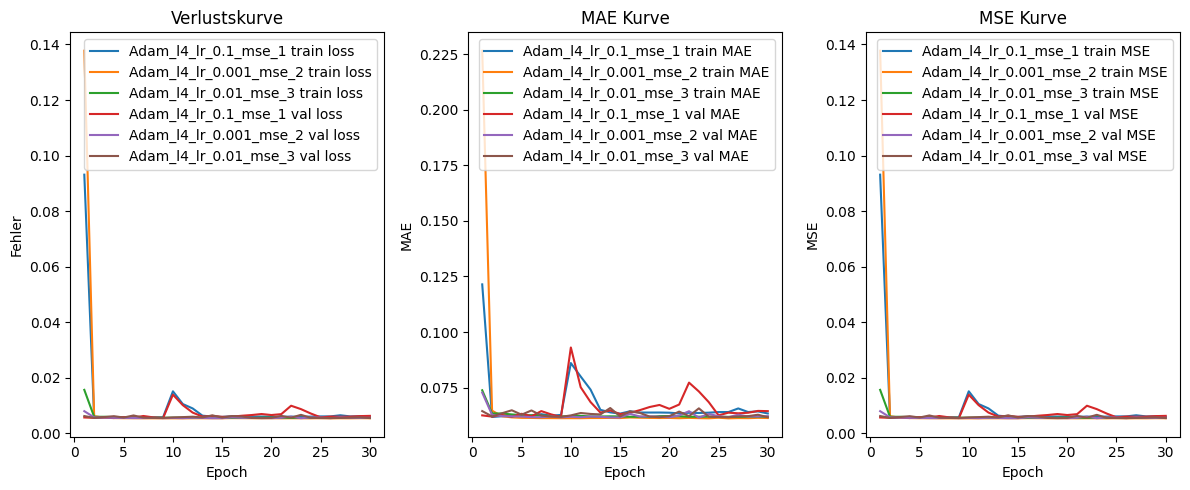

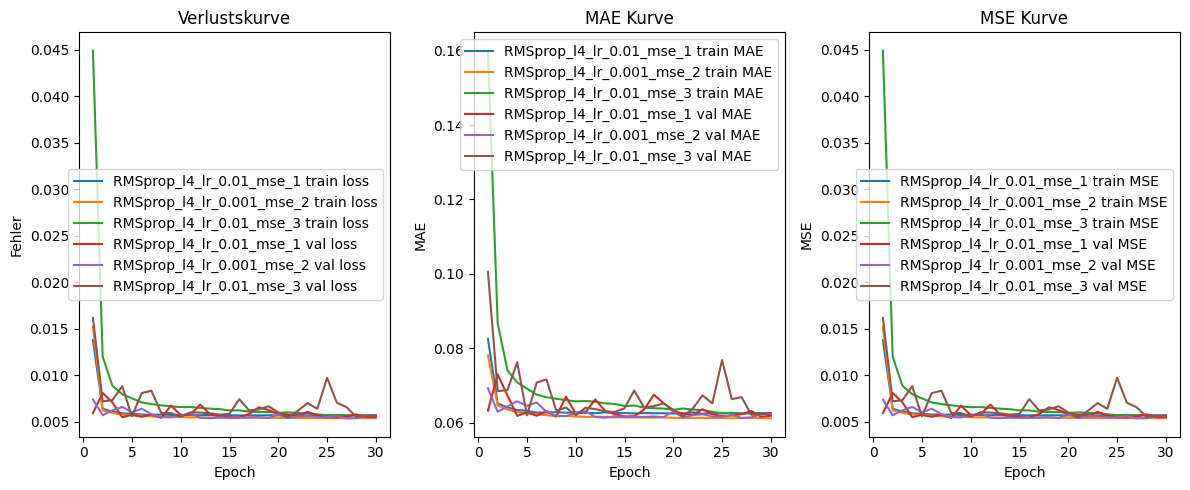

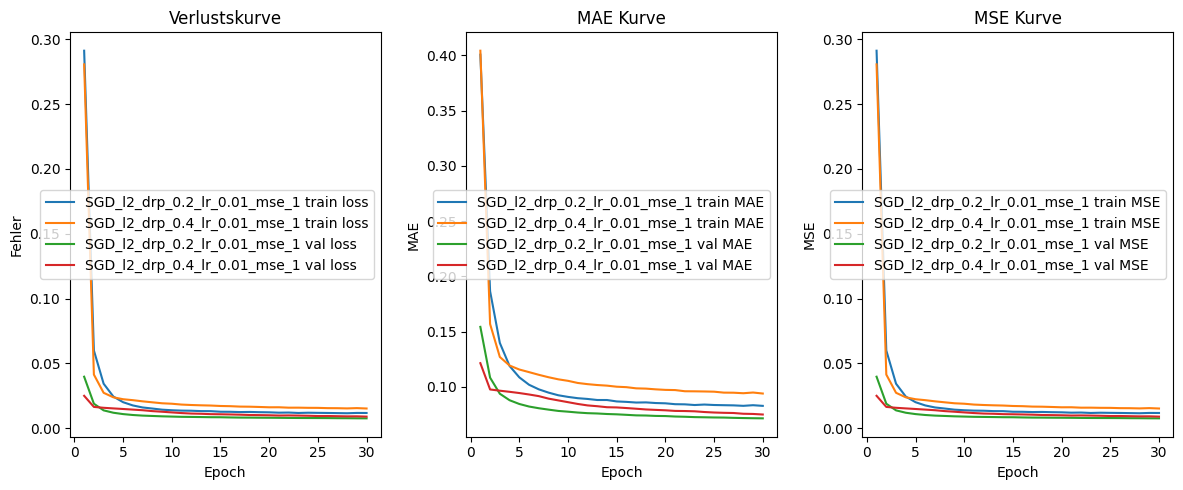

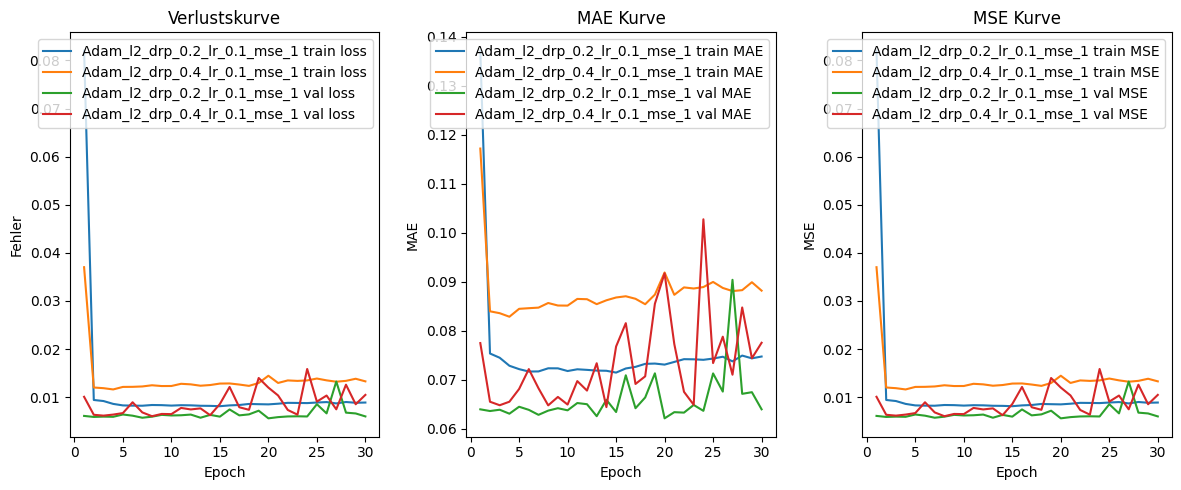

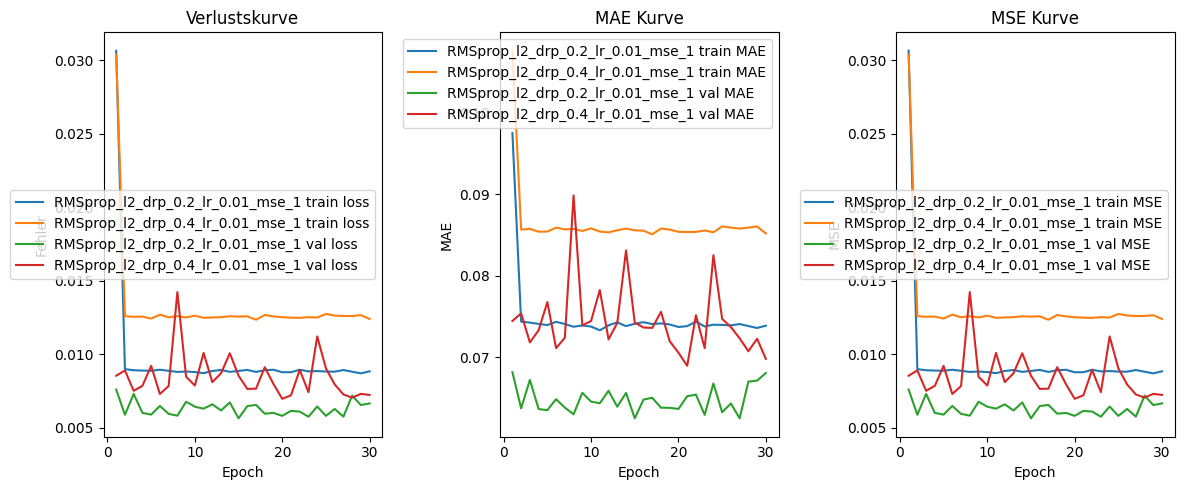

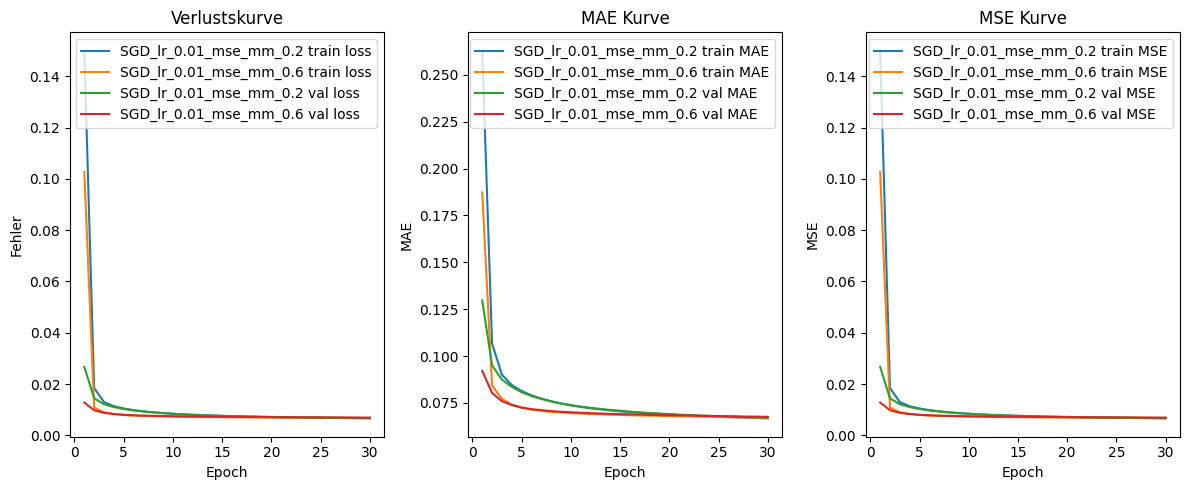

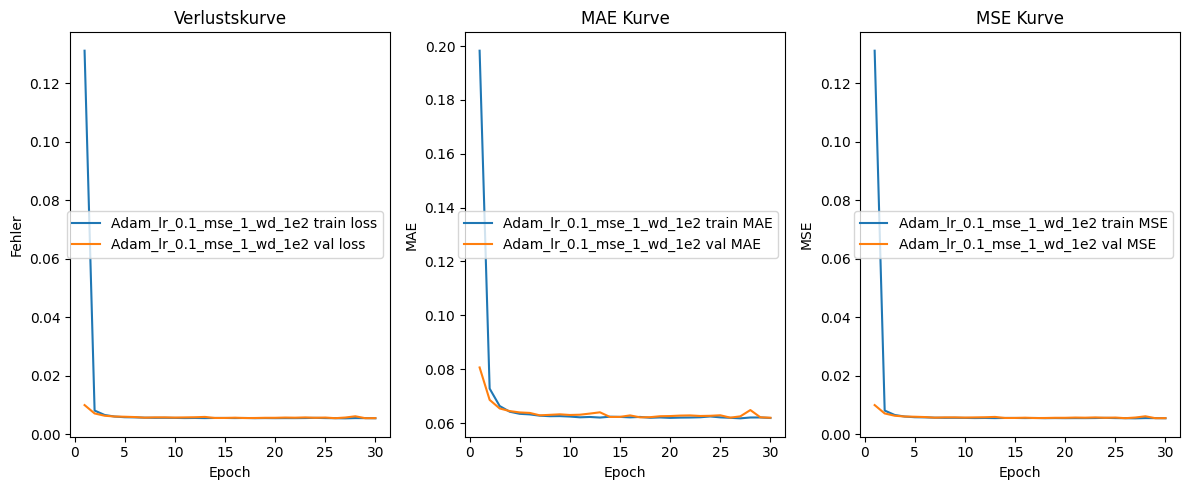

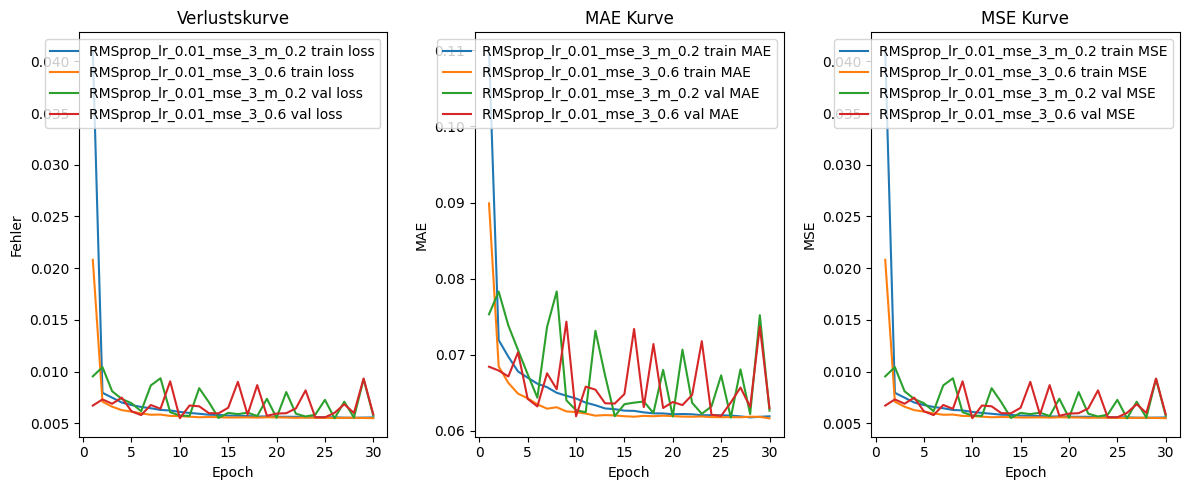

In [64]:
grouped_items_list = {
    "models": models,
    "models_2": models_2,
    "models_drp": models_drp,
    "models_paramed": models_paramed,
}

# Verlustverlauf der verschiedenen Modelle visualisieren
for grouped_items_k, grouped_items_model in grouped_items_list.items():
    grouped_items = group_models_by_name_key(grouped_items_model)
    for k, v in grouped_items.items():
        plot_training_for_all(v)
    

In [71]:
# ein optimales Modell speichern
optimal_model = None
for model in models:
    if model.name == 'SGD_lr_0.01_mse_mm_0.9':
        optimal_model = model

optimal_model.saveModel(True)

INFO:tensorflow:Assets written to: C:\Users\harro\AppData\Local\Temp\tmpnndu3zcm\assets


INFO:tensorflow:Assets written to: C:\Users\harro\AppData\Local\Temp\tmpnndu3zcm\assets


Saved artifact at 'C:\Users\harro\AppData\Local\Temp\tmpnndu3zcm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor_141')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2142512664064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2142576487840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2142512665120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2142576164384: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [66]:
class SciKitModel:
    def __init__(self, name, model):
        self.name = name
        self.model = model

    def predict(self, data):
        return self.model.predict(data)

    def fit(self, test_data, val_data):
        self.model.fit(test_data[0], test_data[1])
        predictions = self.model.predict(val_data[0])

        r2 = r2_score(val_data[1], predictions)
        mae = mean_absolute_error(val_data[1], predictions)
        mse = mean_squared_error(val_data[1], predictions)

        return {"r2": r2, "mae": mae, "mse": mse}

    def test_prediction(self, test_data, sample_size=100):
        X_test, Y_test = test_data
        indices = np.random.choice(len(X_test), size=sample_size, replace=False)
        X_sample = X_test[indices]
        Y_sample = Y_test[indices]

        Y_pred = self.predict(X_sample).flatten()

        n_cols = 2
        n_rows = int(np.ceil(X_sample.shape[1] / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
        axes = axes.flatten()

        for i in range(X_sample.shape[1]):
            axes[i].scatter(X_sample[:, i], Y_sample, color="blue", label="Sollwerte")
            axes[i].scatter(X_sample[:, i], Y_pred, color="orange", label="Vorhersagen")
            axes[i].set_xlabel(f"X column {i}")
            axes[i].set_ylabel("Y values")
            axes[i].set_title(f"Column {i}: Sollwerte vs Vorhersagen")
            axes[i].legend()

        # Hide any unused subplots
        for j in range(X_sample.shape[1], len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()

    def regression_diagnostics(self, test_data, sample_size=100):
        X_test, Y_test = test_data
        indices = np.random.choice(
            len(X_test), size=min(sample_size, len(X_test)), replace=False
        )
        X_sample = X_test[indices]
        Y_sample = Y_test[indices]

        Y_pred = self.predict(X_sample).flatten()
        residuals = Y_sample - Y_pred

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # 1. True vs Predicted scatter
        axes[0].scatter(Y_sample, Y_pred, color="orange", alpha=0.7)
        axes[0].plot(
            [Y_sample.min(), Y_sample.max()], [Y_sample.min(), Y_sample.max()], "r--"
        )
        axes[0].set_xlabel("Sollwerte")
        axes[0].set_ylabel("Vorhersagen")
        axes[0].set_title("Sollwerte vs Vorhersagen")

        # 2. Residual plot
        axes[1].scatter(Y_pred, residuals, color="blue", alpha=0.7)
        axes[1].axhline(0, color="r", linestyle="--")
        axes[1].set_xlabel("Vorhersagen")
        axes[1].set_ylabel("Residuen")
        axes[1].set_title("Residuen vs Vorhersagen")

        # 3. Distribution comparison
        sns.kdeplot(Y_sample, ax=axes[2], label="Sollwerte", fill=True)
        sns.kdeplot(Y_pred, ax=axes[2], label="Vorhersagen", fill=True)
        axes[2].set_title("Verteilung: Sollwerte vs Vorhersagen")
        axes[2].legend()

        plt.tight_layout()
        plt.show()

In [67]:
def train_and_test_scikit_models(sci_kit_models):
    for model in sci_kit_models:
        print(model.name)
        accuracy_score = model.fit(
            (X_data_train, Y_train), (X_data_validation, Y_validation)
        )
        model.regression_diagnostics((X_data_validation, Y_validation))
        print(f"Ergebnis von {model.name}: MAE={accuracy_score['mae']:.4f}, MSE={accuracy_score['mse']:.4f}")

In [68]:
# Verschiedene Lernverfahren mithilfe scikit-learn erstellen und evaluieren
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor



LinearRegression


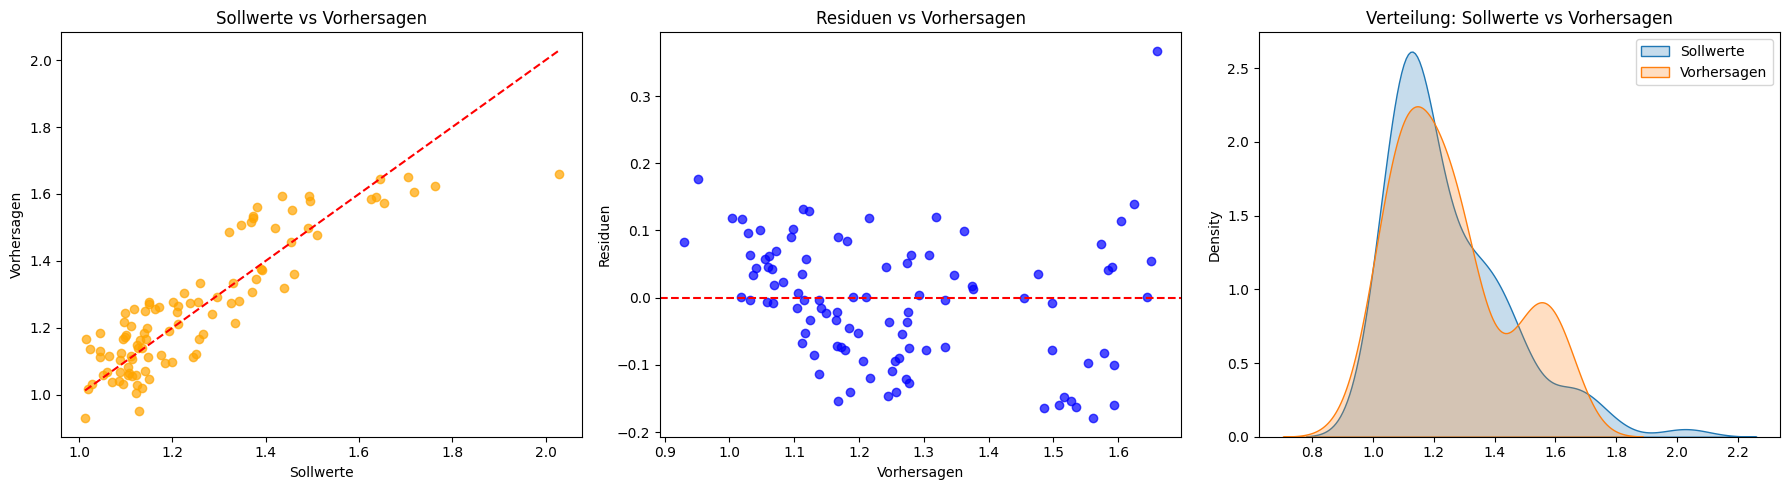

Ergebnis von LinearRegression: MAE=0.0691, MSE=0.0075
RandomForestRegressor


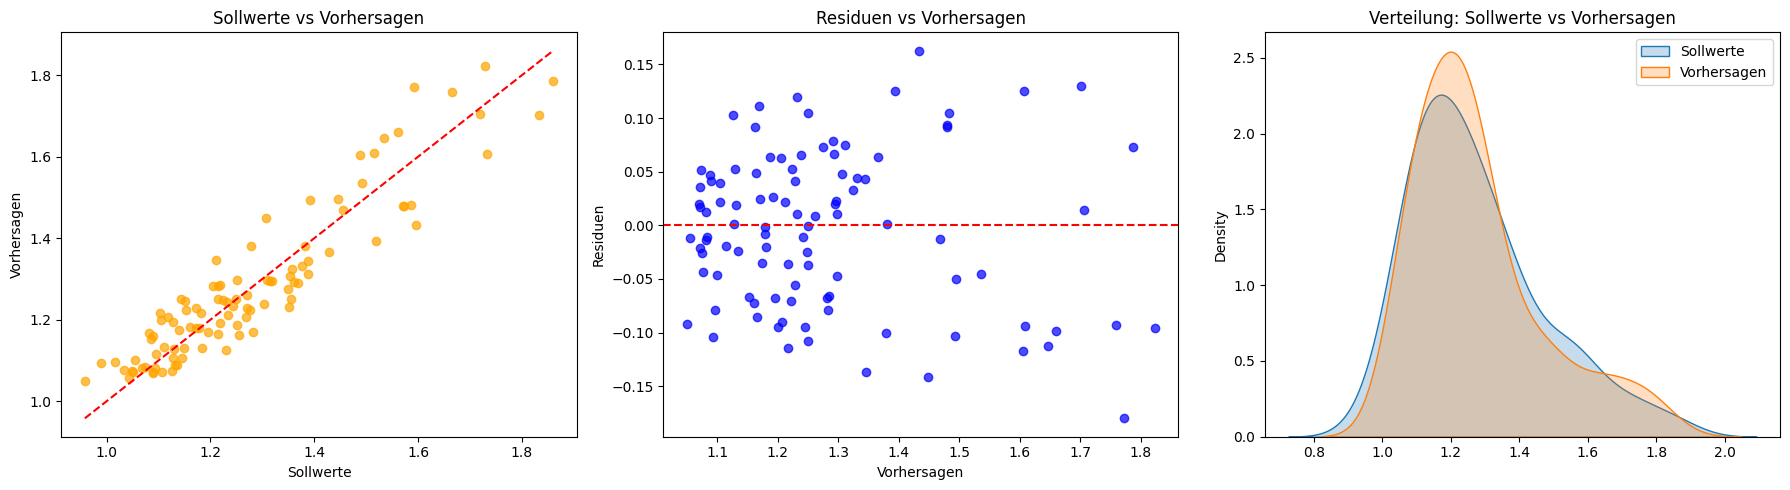

Ergebnis von RandomForestRegressor: MAE=0.0615, MSE=0.0054
GradientBoostingRegressor


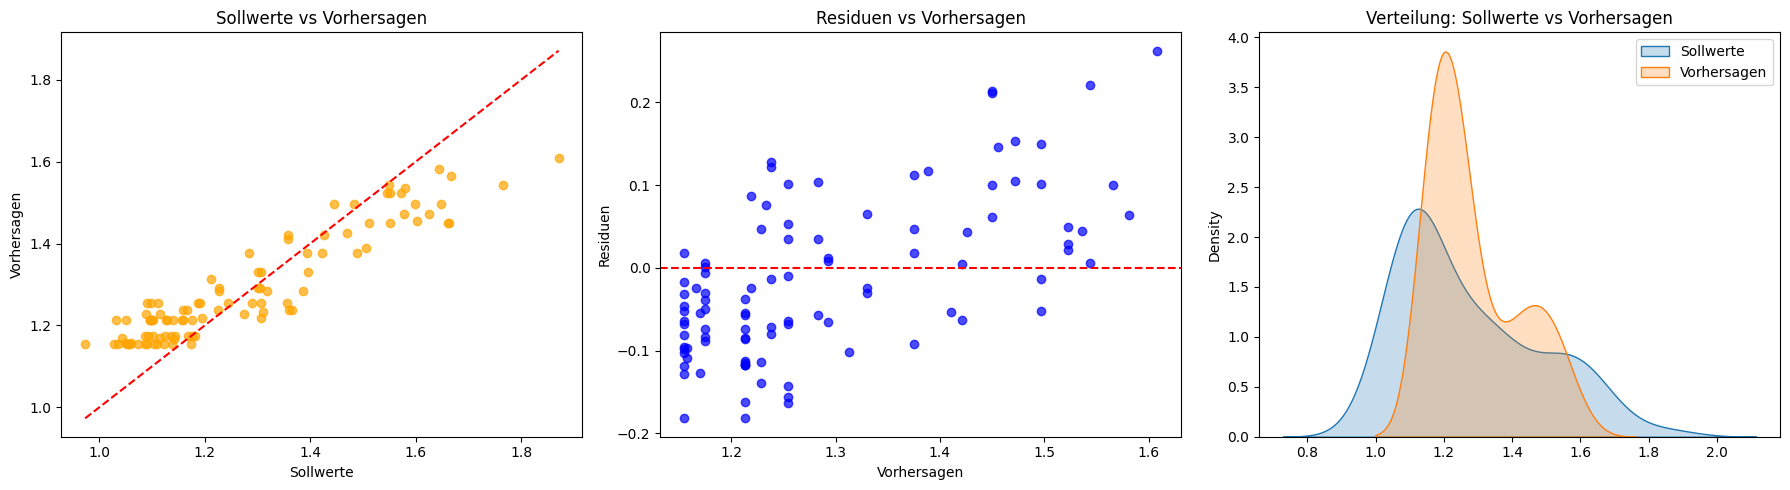

Ergebnis von GradientBoostingRegressor: MAE=0.0825, MSE=0.0109
KNeighborsRegressor


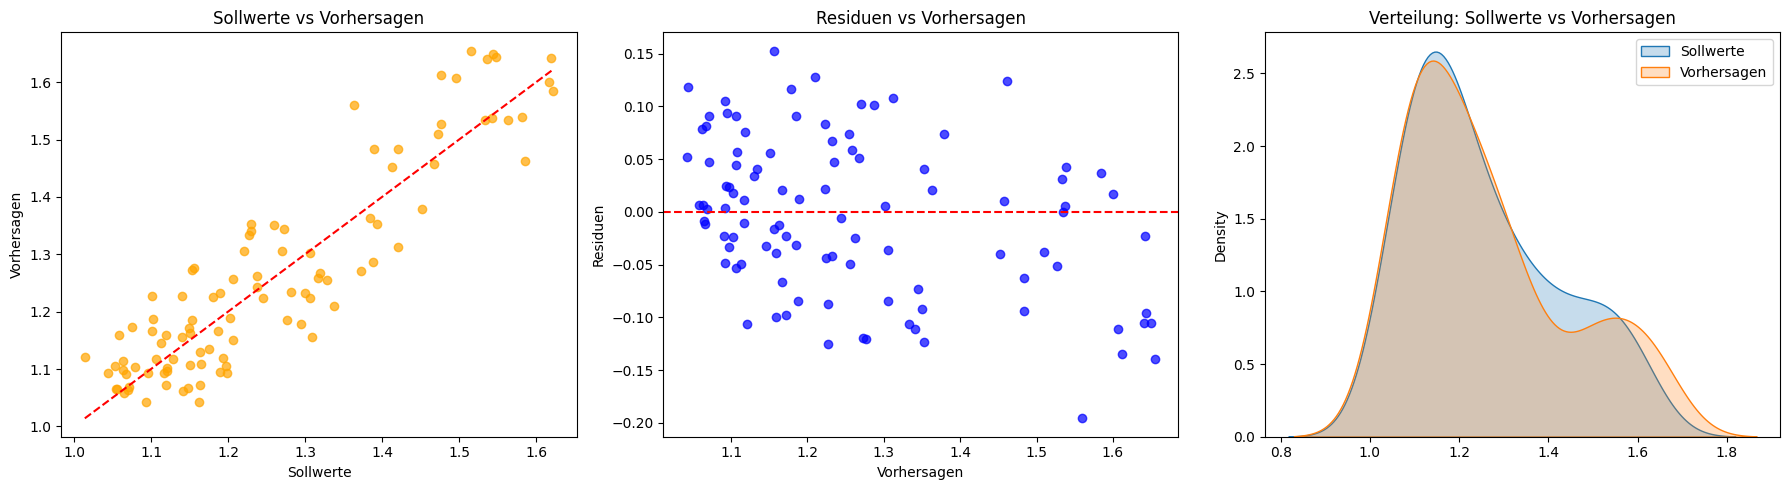

Ergebnis von KNeighborsRegressor: MAE=0.0654, MSE=0.0064


In [69]:

sci_kit_models_1 = [
    SciKitModel("LinearRegression", LinearRegression()),
    SciKitModel(
        "RandomForestRegressor", RandomForestRegressor(max_depth=10, n_estimators=1000)
    ),
    SciKitModel(
        "GradientBoostingRegressor",
        GradientBoostingRegressor(n_estimators=10, learning_rate=0.1),
    ),
    SciKitModel("KNeighborsRegressor", KNeighborsRegressor()),
]

train_and_test_scikit_models(sci_kit_models_1)

GradientBoostingRegressor_10_lr_0.01


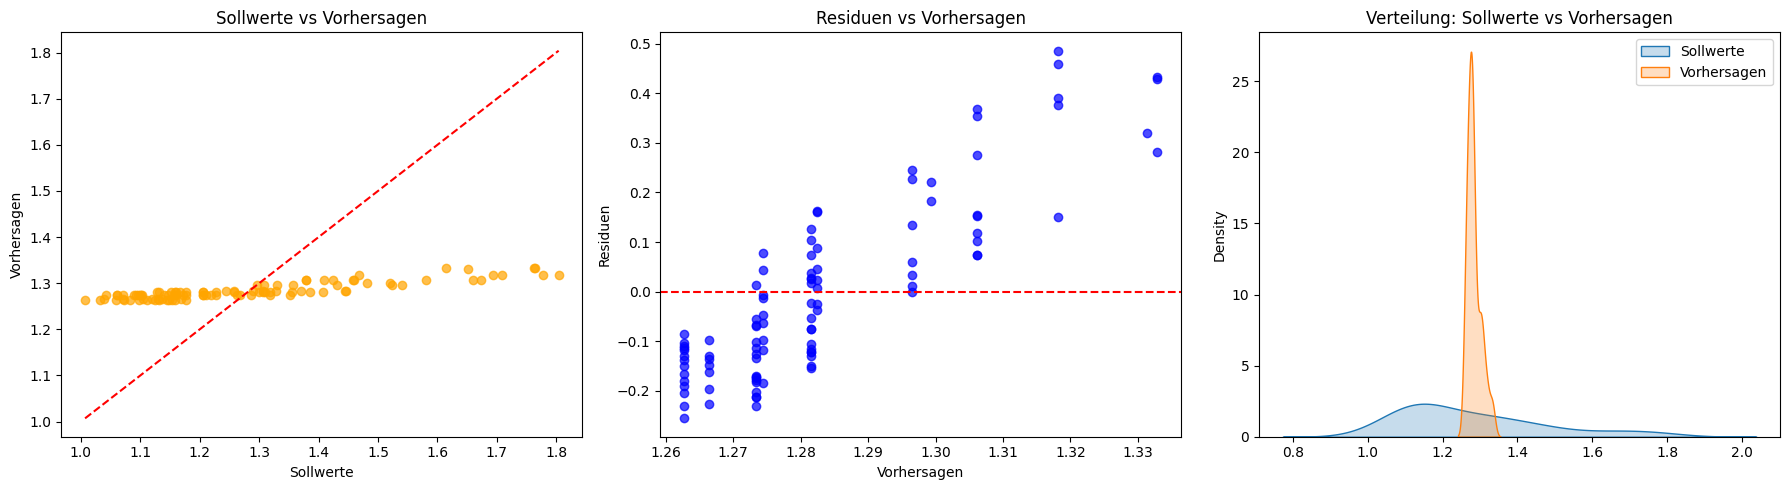

Ergebnis von GradientBoostingRegressor_10_lr_0.01: MAE=0.1535, MSE=0.0370
GradientBoostingRegressor_50_lr_0.001


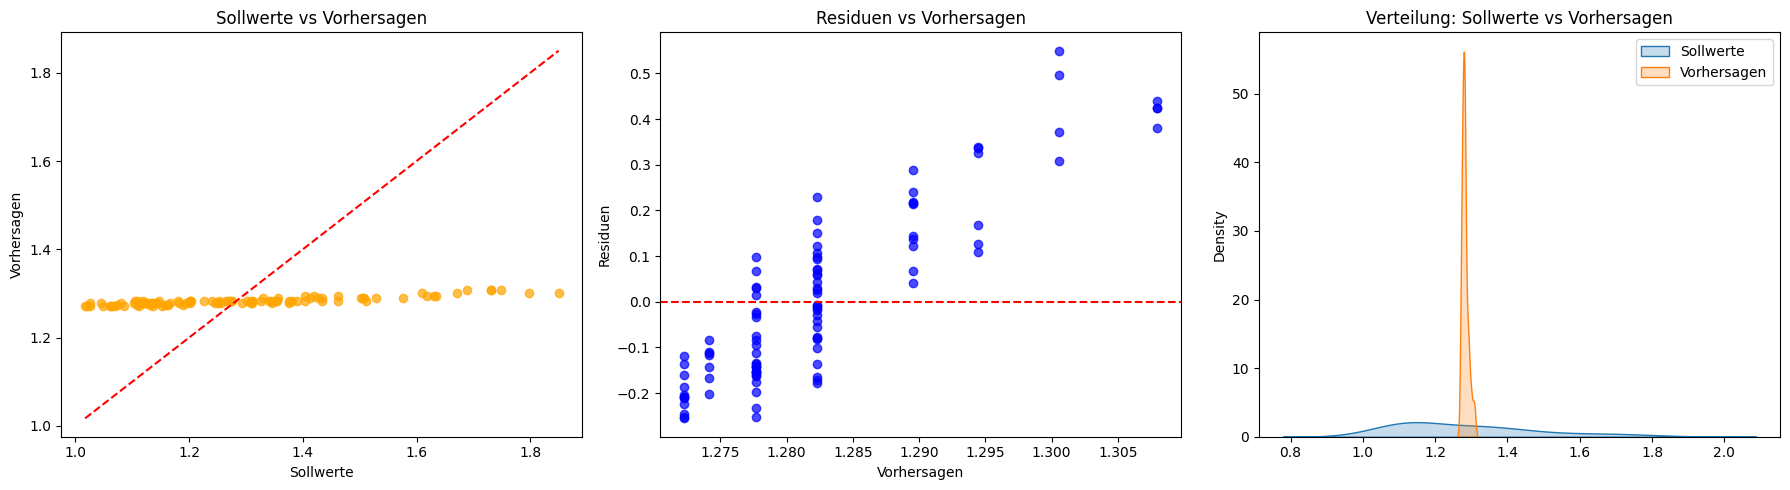

Ergebnis von GradientBoostingRegressor_50_lr_0.001: MAE=0.1599, MSE=0.0402
GradientBoostingRegressor_100_lr_0.001


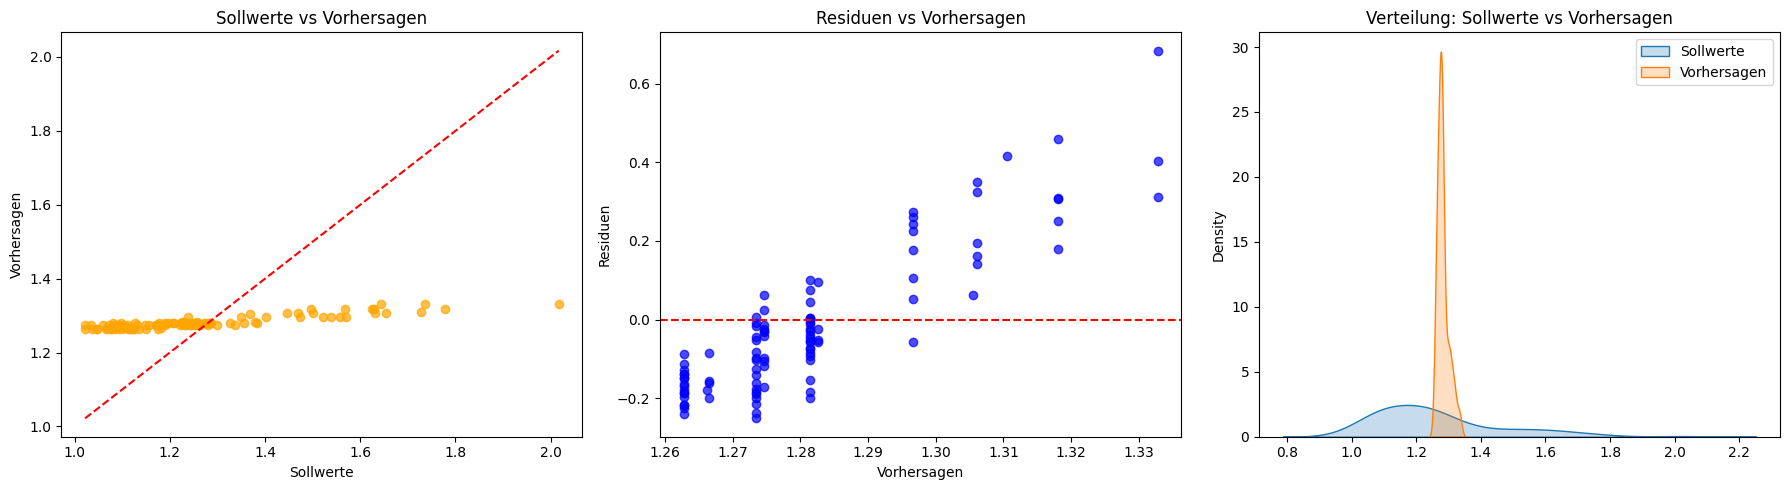

Ergebnis von GradientBoostingRegressor_100_lr_0.001: MAE=0.1536, MSE=0.0370
GradientBoostingRegressor_120_lr_0.01


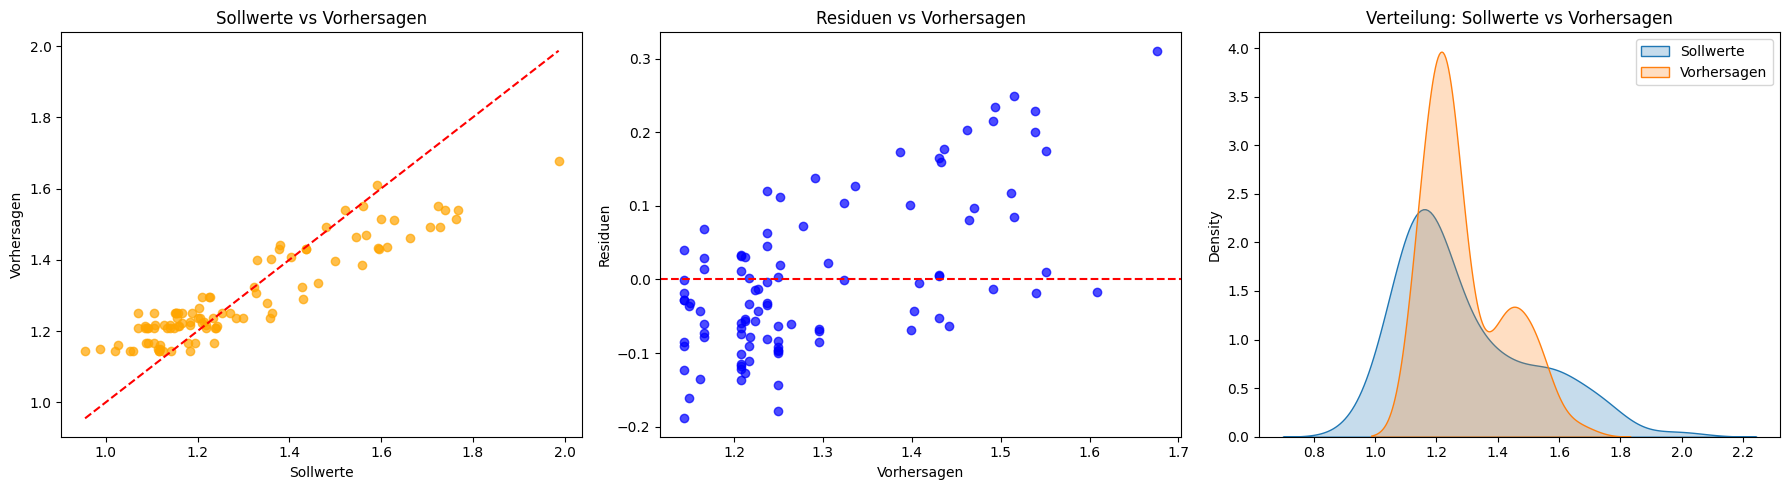

Ergebnis von GradientBoostingRegressor_120_lr_0.01: MAE=0.0777, MSE=0.0096


In [70]:

sci_kit_models_2 = [
    SciKitModel(
        "GradientBoostingRegressor_10_lr_0.01",
        GradientBoostingRegressor(n_estimators=10, learning_rate=0.01),
    ),
    SciKitModel(
        "GradientBoostingRegressor_50_lr_0.001",
        GradientBoostingRegressor(n_estimators=50, learning_rate=0.001),
    ),
    SciKitModel(
        "GradientBoostingRegressor_100_lr_0.001",
        GradientBoostingRegressor(n_estimators=100, learning_rate=0.001),
    ),
    SciKitModel(
        "GradientBoostingRegressor_120_lr_0.01",
        GradientBoostingRegressor(n_estimators=120, learning_rate=0.01),
    ),
]

train_and_test_scikit_models(sci_kit_models_2)

In [75]:
# werte ausserhalb der Wertebereiche simulieren.

# Hierfür werden Werte generiert, die außerhalb der Standardabweichung der vorhandenen Daten liegen, um zu testen, wie das Modell mit solchen Werten umgeht.
x_data_exceeded = []
x_cols = (structure_data.drop(columns=[target_column])).columns

x_data_stats = {}
for col in x_cols:
    x_data_stats[col] = {
        "min": structure_data[col].min(),
        "max": structure_data[col].max(),
        "std": structure_data[col].std()
    }


for i in range(10):
    min_values = []
    max_values = []
    for col in x_cols:
        min_values.append(np.random.uniform(x_data_stats[col]["min"] - x_data_stats[col]["std"], x_data_stats[col]["min"]))
        max_values.append(np.random.uniform(x_data_stats[col]["max"], x_data_stats[col]["max"] + x_data_stats[col]["std"]))

    # p spalte mit 0 befüllen, nachher wird sie 
    # mit den Vorhersagen überschrieben
    min_values.append(0)
    max_values.append(0)

    x_data_exceeded.append(min_values)
    x_data_exceeded.append(max_values)

# in numpy umwandeln
x_data_exceeded = np.array(x_data_exceeded)

# normalisieren
x_data_exceeded_scaled = scaler.transform(x_data_exceeded)

# vorhersagen
y_data_result = optimal_model.predict(x_data_exceeded_scaled[:, 0:4])

x_data_exceeded[:, 4] = y_data_result[:, 0]


# erste 3 Zeilen ausgeben
print(x_data_exceeded[0:3], x_data_exceeded_scaled[0:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


c:\Users\harro\miniconda3\envs\neural_networks\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[[ 3.53603912e+00  1.37521005e-02  7.28151951e+00 -3.89670845e-01
   1.42193556e+00]
 [ 3.04189232e+01  1.34979632e-01  4.01734061e+01  1.18158120e+00
   1.52451789e+00]
 [ 2.69813393e+00  3.94316352e-03  2.19353350e+00 -1.68976059e-01
   1.36255765e+00]] [[-1.13104435 -1.86943607 -2.04570269 -1.77934169 -6.19768109]
 [ 2.46133215  3.28246563  1.75292387  1.36316241 -6.19768109]
 [-1.24301414 -2.28629417 -2.63330531 -1.33795212 -6.19768109]]


In [76]:
np.set_printoptions(suppress=True)
print(x_data_exceeded)

[[ 3.53603912  0.0137521   7.28151951 -0.38967085  1.42193556]
 [30.41892324  0.13497963 40.17340615  1.1815812   1.52451789]
 [ 2.69813393  0.00394316  2.1935335  -0.16897606  1.36255765]
 [30.41940013  0.13771719 40.63162886  1.49399448  1.5619247 ]
 [ 0.78216643  0.00922601  8.29604791 -0.05245535  1.23090053]
 [30.36143849  0.15423142 40.65894009  1.11851319  1.5463587 ]
 [ 0.67954021  0.00240909  5.18032982 -0.19007812  1.32244527]
 [24.55856388  0.13603499 43.09804813  1.0726876   1.35936356]
 [-0.19841434  0.00620725  8.4769284  -0.01542518  1.22771752]
 [30.13846537  0.14801889 47.01155974  1.16128407  1.46956229]
 [-1.74142128  0.00621531  1.92173598 -0.14090758  1.25500453]
 [27.15949805  0.15054658 43.75103587  1.06972583  1.43947601]
 [ 1.96799267 -0.00112309  9.57300886 -0.28715764  1.43944609]
 [26.4300557   0.15260979 41.28263285  1.19045339  1.45847082]
 [ 0.89151992  0.01443201  2.14427261 -0.0369625   1.21225584]
 [29.5102868   0.15302867 44.14969374  1.27770912  1.50

In [77]:
print (x_cols)

Index(['v', 'd', 's', 'r'], dtype='object')
